<div style="border:solid green 2px; padding: 20px">
    
<b>Сергей, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Прогноз отмены бронирования для сети отелей UrbanStay

- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.

**Заказчик** - сеть отелей среднего сегмента UrbanStay. Последние два года около трети броней отменяются незадолго до заезда, из-за чего загрузка держится на уровне 60-70% вместо плановых 80%. Сейчас отмены компенсируются овербукингом «на глаз», и заказчик хочет заменить интуицию управляемым инструментом.

**Что нужно сделать:**

1. Построить модель, которая по параметрам брони предсказывает вероятность её отмены.
2. Оценить экономический эффект внедрения по трём показателям: динамика доли отмен, динамика загрузки отелей и прирост дохода (Incremental Revenue, IR).

**Целевые показатели заказчика:**

- доля отмен после внедрения модели - 10%;
- загрузка отеля не должна снизиться более чем на 8%;
- относительный IR - не менее 50%.

**Данные.** Два источника в PostgreSQL:

- `hotel_bookings` - 35 341 запись о бронированиях: канал продаж, состав гостей, история клиента, стоимость, срок до заезда, длительность проживания, тип питания и номера, число пожеланий и целевой статус брони (`отказ_брони` / `нет_отказа`);
- `hotel_reviews` - 25 177 отзывов: идентификатор клиента и брони, дата отзыва, оценка проживания от 1 до 5 и текст комментария.

Целевая переменная - факт отмены брони, положительный класс (`1`) - `отказ_брони`.

## Перевод бизнес-задачи на язык машинного обучения

- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.

**Тип задачи** - бинарная классификация с вероятностным выходом: модель должна возвращать не метку, а вероятность отмены, потому что решение о перепродаже номера принимается по порогу, а порог задаётся экономикой, а не значением 0.5.

**Метрика оптимизации** - Incremental Revenue, а не accuracy или F1. Ошибки стоят по-разному: пропущенная отмена (FN) стоит отелю 64 500 руб. упущенного дохода, а ложное срабатывание (FP) - 7 000 руб. компенсаций. Поэтому модель настраивается прямо на рубли:

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$IR = IR_{после} - IR_{до}, \qquad IR_{отн} = \frac{IR_{после} - IR_{до}}{IR_{до}} \cdot 100\%$$

Вспомогательные метрики ROC-AUC и PR-AUC используются как индикатор ранжирующей способности: IR зависит от порога, а AUC - нет, поэтому по ним удобно сравнивать модели между собой.

**План работы:**

1. Выгрузка обеих таблиц из PostgreSQL через SQLAlchemy.
2. EDA: качество данных, пропуски, дубликаты, аномалии, распределения, динамика во времени и связь признаков с целевой переменной.
3. Объединение брони с отзывами по правилу «ближайший предшествующий отзыв».
4. Генерация признаков: производные от параметров брони, лояльность клиента, категоризация срока до заезда и сезона, векторизация текстов отзывов через TF-IDF.
5. Разделение на train / calibration / test в пропорции 60 / 20 / 20 со стратификацией по целевой переменной.
6. Турнир моделей Random Forest, LightGBM и CatBoost: подбор гиперпараметров в Optuna по кросс-валидации из трёх фолдов с валидационной выборкой в 2 000 объектов, критерий - IR.
7. Проверка гипотез по улучшению IR: признаки спроса, нативные категории CatBoost, блендинг, расширенный поиск.
8. Калибровка лучшей модели на полной обучающей выборке и поиск порога по калибровочной выборке.
9. Проверка стабильности на тестовой выборке, анализ важности признаков через SHAP.
10. Расчёт экономического эффекта и выводы для бизнеса.

**Защита от утечек.** Препроцессор (медианы для пропусков, словарь категорий, словарь TF-IDF) собран в `Pipeline` вместе с моделью и обучается внутри каждого фолда кросс-валидации только на его обучающей части. Порог подбирается на калибровочной выборке, а тестовая используется только для финальной оценки: ни модель, ни порог, ни признаки по ней не выбираются.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, вводная часть имеется

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

Ячейка ниже доустанавливает пакеты, которых нет в базовом окружении платформы, и импортирует всё, что понадобится дальше. Установка идёт до импортов: на чистом ядре импорт в начале ячейки упал бы с `ModuleNotFoundError` раньше, чем отработал бы `pip`.

Функции подготовки данных, генерации признаков и расчёта бизнес-метрик вынесены в модуль `feature_pipeline.py`, который лежит рядом с тетрадью. Так один и тот же код используется и в тетради, и при инференсе сохранённой модели.

In [1]:
import importlib
import importlib.util
import json
import shutil
import site
import subprocess
import sys
import time
import warnings
from importlib.metadata import version
from pathlib import Path

# Пакеты, которых нет в базовом окружении платформы. Версии подобраны под стек
# Python 3.9 / numpy 1.21 / pandas 1.2.4 / sklearn 0.24 и не тянут его обновление.
REQUIRED = {
    "psycopg2": "psycopg2-binary==2.9.9",
    "optuna": "optuna==4.9.0",
    "lightgbm": "lightgbm==3.3.5",
    "catboost": "catboost==1.2.5",
    "numba": "numba==0.56.4",
    "shap": "shap==0.44.1",
}
to_install = [spec for module, spec in REQUIRED.items()
              if importlib.util.find_spec(module) is None]

# pandas 1.2 совместим только с SQLAlchemy 1.x: в 2.0 сменилась сигнатура MetaData,
# и pd.read_sql_query падает с TypeError ещё до запроса.
if (importlib.util.find_spec("sqlalchemy") is None
        or int(version("SQLAlchemy").split(".")[0]) >= 2):
    to_install.append("SQLAlchemy==1.4.54")

if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + to_install)
    sys.path.insert(0, site.getusersitepackages())
    importlib.invalidate_caches()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text

from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import optuna
import shap
from catboost import CatBoostClassifier, Pool

import feature_pipeline as fp

# Модуль с таким именем был и в прошлых спринтах, поэтому проверяем, что рядом с тетрадью
# лежит именно его версия: иначе тетрадь упала бы ниже с невнятным AttributeError.
if getattr(fp, "SPRINT", None) != "SPRINT_18":
    raise ImportError(
        "Импортирован не тот feature_pipeline: {}. Положите feature_pipeline.py из этого "
        "спринта рядом с тетрадью и перезапустите ядро (модули кэшируются)."
        .format(getattr(fp, "__file__", "путь неизвестен"))
    )

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = fp.RANDOM_STATE
# Число потоков фиксируем явно: без этого замеры времени сравнивают не алгоритмы,
# а их настройки многопоточности по умолчанию.
N_JOBS = 4

versions = pd.DataFrame(
    [(name, version(name)) for name in
     ["pandas", "numpy", "scikit-learn", "SQLAlchemy", "lightgbm",
      "catboost", "optuna", "shap", "matplotlib", "seaborn"]],
    columns=["библиотека", "версия"],
).set_index("библиотека")
versions.columns.name = f"Python {sys.version.split()[0]}"
display(versions)
print("feature_pipeline:", fp.__file__)

Python 3.9.25,версия
библиотека,
pandas,1.2.4
numpy,1.21.1
scikit-learn,0.24.1
SQLAlchemy,1.4.54
lightgbm,3.3.5
catboost,1.2.5
optuna,4.9.0
shap,0.44.1
matplotlib,3.3.4


feature_pipeline: /mnt/c/Users/serge/Yandex.Disk/Курсы/MLDS/SPRINT_18/feature_pipeline.py


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* версии библиотек фиксируются
* зависимости устанавливаются до импортов

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [2]:
DB_CONFIG = {
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "database": "data-scientist-hotels",
    "user": "praktikum_student",
    "password": "Sdf4$2;d-d30pp",
}
connection_string = (
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_CONFIG)
)
engine = create_engine(connection_string)

QUERY_BOOKINGS = "SELECT * FROM hotel_bookings"
QUERY_REVIEWS = "SELECT * FROM hotel_reviews"

# Запросы выполняем внутри одного соединения, соединение закрывается контекстным менеджером.
with engine.connect() as connection:
    bookings_raw = pd.read_sql_query(text(QUERY_BOOKINGS), connection)
    reviews_raw = pd.read_sql_query(text(QUERY_REVIEWS), connection)
engine.dispose()

EXPECTED_ROWS = {"hotel_bookings": 35_341, "hotel_reviews": 25_177}
loaded = pd.DataFrame(
    [
        ["hotel_bookings", bookings_raw.shape[0], bookings_raw.shape[1],
         EXPECTED_ROWS["hotel_bookings"], bookings_raw.shape[0] == EXPECTED_ROWS["hotel_bookings"]],
        ["hotel_reviews", reviews_raw.shape[0], reviews_raw.shape[1],
         EXPECTED_ROWS["hotel_reviews"], reviews_raw.shape[0] == EXPECTED_ROWS["hotel_reviews"]],
    ],
    columns=["таблица", "строк", "столбцов", "строк_по_ТЗ", "совпадает"],
).set_index("таблица")
display(loaded)
display(bookings_raw.head())
display(reviews_raw.head())

,строк,столбцов,строк_по_ТЗ,совпадает
таблица,,,,
hotel_bookings,35341,17,35341,True
hotel_reviews,25177,5,25177,True


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,"6,700.0000",21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,"62,300.0000",15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,"53,600.0000",150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


**Выводы по загрузке данных**

- Подключение к PostgreSQL собрано через `create_engine`, обе таблицы выгружены запросами `SELECT * FROM ...` внутри одного соединения, пул закрыт `engine.dispose()`.
- `hotel_bookings` - **35 341 строка и 17 столбцов**, `hotel_reviews` - **25 177 строк и 5 столбцов**. Объёмы сверены с описанием данных в задании программно: обе проверки вернули `True`, выгрузка полная.
- Типы пришли из базы как есть: даты (`booking_date`, `review_date`) - строки, `returning_customer` и `parking_included` - булевы, `booking_value` - число с плавающей точкой. Даты потребуют приведения к `datetime`, булевы поля - к 0/1.
- Ключ `booking_id` в обеих таблицах имеет один формат (`INN00000`), значит таблицы соединимы по нему технически. Пригоден ли такой ключ содержательно - отдельный вопрос, к которому мы вернёмся в разделе про объединение.

**Итог:** данные загружены полностью и в ожидаемом объёме, дальше - оценка их качества.

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [3]:
bookings_raw.info()
reviews_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

#### Пропуски, дубликаты и уникальность ключей

Проверяем каждую таблицу по трём пунктам сразу: доля пропусков по столбцам, полные дубликаты строк и уникальность ключа. В `hotel_bookings` ключ - `booking_id`, в `hotel_reviews` пара `booking_id` + `review_date`. Дубликаты по ключу проверяем не только по числу, но и на конфликт значений: если внутри группы все столбцы совпадают, это технические копии, если различаются - конфликт данных, и обрабатывать его нужно иначе.

In [4]:
def quality_report(df, name):
    """Сводка по пропускам и типам одной таблицы."""
    report = pd.DataFrame({
        "тип": df.dtypes.astype(str),
        "пропусков": df.isna().sum(),
        "доля_пропусков_%": (df.isna().mean() * 100).round(2),
        "уникальных": df.nunique(),
    })
    report.columns.name = name
    return report


display(quality_report(bookings_raw, "hotel_bookings"))
display(quality_report(reviews_raw, "hotel_reviews"))

keys = pd.DataFrame(
    [
        ["hotel_bookings", len(bookings_raw), int(bookings_raw.duplicated().sum()),
         int(bookings_raw["booking_id"].duplicated().sum()), bookings_raw["booking_id"].nunique()],
        ["hotel_reviews", len(reviews_raw), int(reviews_raw.duplicated().sum()),
         int(reviews_raw.duplicated(subset=["booking_id", "review_date"]).sum()),
         reviews_raw["booking_id"].nunique()],
    ],
    columns=["таблица", "строк", "полных_дублей", "дублей_по_ключу", "уникальных_booking_id"],
).set_index("таблица")
display(keys)

duplicated_ids = bookings_raw.loc[bookings_raw["booking_id"].duplicated(), "booking_id"].unique()
conflicts = (
    bookings_raw[bookings_raw["booking_id"].isin(duplicated_ids)]
    .groupby("booking_id")
    .nunique()
    .max()
    .rename("максимум_различных_значений_внутри_booking_id")
    .to_frame()
)
display(conflicts.T)

# Те же дубли по ключу в отзывах: одна ли это поездка с несколькими отзывами
# или конфликт данных с разными оценками одного и того же отзыва.
review_key_dups = reviews_raw[
    reviews_raw.duplicated(subset=["booking_id", "review_date"], keep=False)
]
review_conflicts = (
    review_key_dups.groupby(["booking_id", "review_date"])
    .agg(клиентов=("customer_id", "nunique"),
         оценок=("stay_rating", "nunique"),
         текстов=("review_text", "nunique"))
    .max()
    .rename("максимум внутри пары booking_id + review_date")
    .to_frame()
)
review_conflicts.loc["строк в таких парах"] = len(review_key_dups)
display(review_conflicts)

hotel_bookings,тип,пропусков,доля_пропусков_%,уникальных
booking_id,object,0,0.0000,30733
booking_date,object,0,0.0000,2445
sales_channel,object,0,0.0000,3
adult_count,int64,0,0.0000,6
child_count,int64,0,0.0000,3
returning_customer,bool,0,0.0000,2
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
booking_status,object,0,0.0000,2
booking_value,float64,0,0.0000,1766


hotel_reviews,тип,пропусков,доля_пропусков_%,уникальных
customer_id,object,0,0.0000,13429
booking_id,object,0,0.0000,21883
review_date,object,0,0.0000,2514
stay_rating,int64,0,0.0000,4
review_text,object,0,0.0000,14153


,строк,полных_дублей,дублей_по_ключу,уникальных_booking_id
таблица,,,,
hotel_bookings,35341,4608,4608,30733
hotel_reviews,25177,0,130,21883


,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
максимум_различных_значений_внутри_booking_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


,максимум внутри пары booking_id + review_date
клиентов,1
оценок,2
текстов,2
строк в таких парах,260


#### Целевая переменная

Смотрим баланс классов: от него зависит и выбор метрики, и стратификация при разбиении выборок.

booking_status,бронирований,доля_%
нет_отказа,25177,71.2400
отказ_брони,10164,28.7600


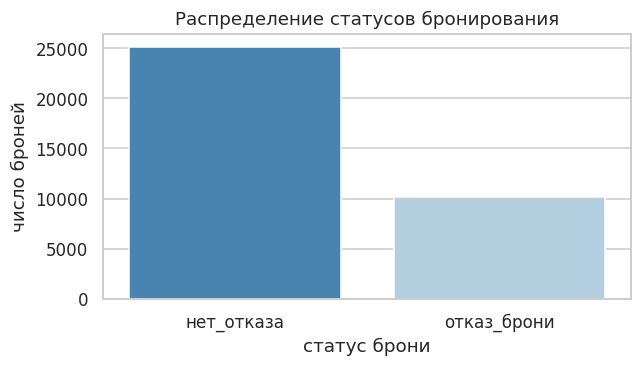

In [5]:
target_share = (
    bookings_raw["booking_status"]
    .value_counts(dropna=False)
    .to_frame("бронирований")
    .assign(доля_=lambda d: (d["бронирований"] / len(bookings_raw) * 100).round(2))
    .rename(columns={"доля_": "доля_%"})
)
target_share.columns.name = "booking_status"
display(target_share)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=target_share.index, y=target_share["бронирований"], ax=ax, palette="Blues_r")
ax.set_title("Распределение статусов бронирования")
ax.set_xlabel("статус брони")
ax.set_ylabel("число броней")
fig.tight_layout()
plt.show()

#### Данные во времени

Заказчик утверждает, что тревожная тенденция держится последние два года. Проверяем это по данным: смотрим, как распределены брони по годам и как менялась доля отмен. Заодно этот разрез отвечает на вопрос, допустимо ли случайное разбиение выборок вместо временного, и показывает распределение заездов по месяцам - на нём строится категоризация сезонности.

,броней,доля_отмен_%
год оформления брони,,
2017,5761,29.6600
2018,7602,29.1200
2019,8641,29.5500
2020,8668,29.8300
2021,3008,24.3700
2022,1190,22.8600
2023,373,19.3000
2024,78,23.0800
2025,20,35.0000


месяц заезда,1,2,3,4,5,6,7,8,9,10,11,12
заездов,"2,887.0000","2,753.0000","2,993.0000","2,870.0000","3,133.0000","2,928.0000","2,945.0000","3,020.0000","2,932.0000","3,017.0000","2,872.0000","2,991.0000"
доля_%,8.1700,7.7900,8.4700,8.1200,8.8700,8.2800,8.3300,8.5500,8.3000,8.5400,8.1300,8.4600


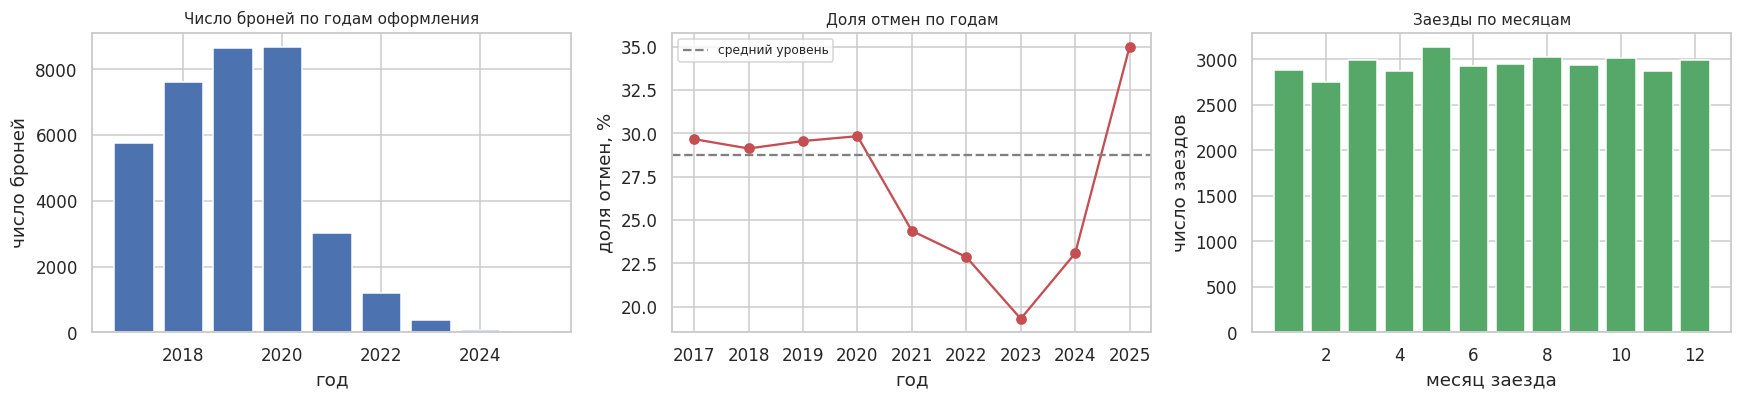

In [6]:
bookings_dated = bookings_raw.assign(
    booking_dt=pd.to_datetime(bookings_raw["booking_date"]),
    отмена=(bookings_raw["booking_status"] == "отказ_брони").astype(int),
)
by_year = bookings_dated.groupby(bookings_dated["booking_dt"].dt.year)["отмена"].agg(
    броней="size", доля_отмен="mean"
)
by_year["доля_отмен_%"] = (by_year["доля_отмен"] * 100).round(2)
by_year = by_year.drop(columns="доля_отмен")
by_year.index.name = "год оформления брони"
display(by_year)

checkin_dates = bookings_dated["booking_dt"] + pd.to_timedelta(
    bookings_dated["days_until_checkin"], unit="D"
)
by_checkin_month = checkin_dates.dt.month.value_counts().sort_index().to_frame("заездов")
by_checkin_month["доля_%"] = (by_checkin_month["заездов"] / len(bookings_dated) * 100).round(2)
by_checkin_month.index.name = "месяц заезда"
display(by_checkin_month.T)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
axes[0].bar(by_year.index, by_year["броней"], color="#4C72B0")
axes[0].set_title("Число броней по годам оформления", fontsize=10)
axes[0].set_xlabel("год")
axes[0].set_ylabel("число броней")

axes[1].plot(by_year.index, by_year["доля_отмен_%"], marker="o", color="#C44E52")
axes[1].axhline(bookings_dated["отмена"].mean() * 100, linestyle="--", color="grey",
                label="средний уровень")
axes[1].set_title("Доля отмен по годам", fontsize=10)
axes[1].set_xlabel("год")
axes[1].set_ylabel("доля отмен, %")
axes[1].legend(fontsize=8)

axes[2].bar(by_checkin_month.index, by_checkin_month["заездов"], color="#55A868")
axes[2].set_title("Заезды по месяцам", fontsize=10)
axes[2].set_xlabel("месяц заезда")
axes[2].set_ylabel("число заездов")
fig.tight_layout()
plt.show()

#### Количественные признаки

Описательные статистики и гистограммы по всем числовым столбцам таблицы бронирований. Для дискретных признаков число корзин задаём по числу уникальных значений, иначе гистограмма превращается в набор «палок» с пустыми промежутками.

,count,mean,std,min,25%,50%,75%,max
adult_count,"35,341.0000",12.4800,45.7300,1.0000,1.0000,2.0000,3.0000,300.0000
child_count,"35,341.0000",0.3600,0.5900,0.0000,0.0000,0.0000,1.0000,2.0000
previous_cancellations,"35,341.0000",0.3600,0.6300,0.0000,0.0000,0.0000,1.0000,5.0000
previous_no_shows,"35,341.0000",0.8400,0.9300,0.0000,0.0000,1.0000,1.0000,5.0000
booking_value,"35,341.0000","61,634.0600","42,837.5900",0.0000,"33,500.0000","53,600.0000","80,400.0000","417,221.2000"
days_until_checkin,"35,341.0000",100.5200,71.8700,2.0000,45.0000,90.0000,144.0000,300.0000
weekday_nights,"35,341.0000",6.5300,3.3400,1.0000,5.0000,6.0000,9.0000,15.0000
weekend_nights,"35,341.0000",1.9500,1.4800,0.0000,0.0000,2.0000,2.0000,6.0000
customer_special_requests,"35,341.0000",0.6200,0.7800,0.0000,0.0000,0.0000,1.0000,5.0000


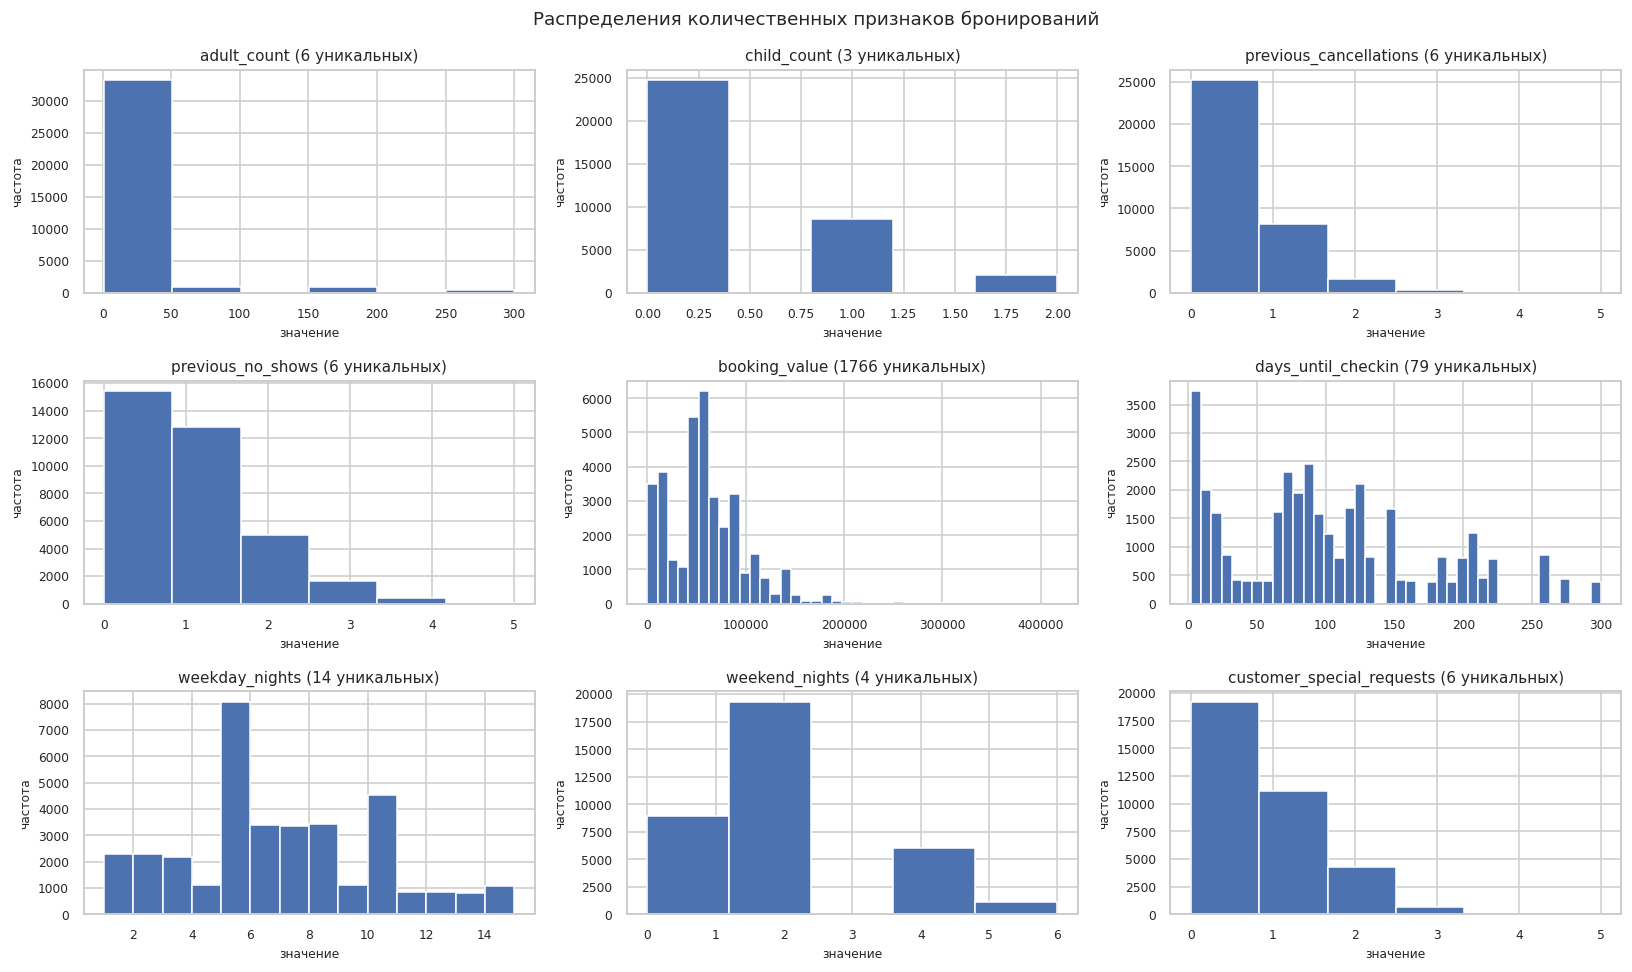

In [7]:
NUM_RAW = [
    "adult_count", "child_count", "previous_cancellations", "previous_no_shows",
    "booking_value", "days_until_checkin", "weekday_nights", "weekend_nights",
    "customer_special_requests",
]
display(bookings_raw[NUM_RAW].describe().T.round(2))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, column in zip(axes.ravel(), NUM_RAW):
    unique_values = bookings_raw[column].nunique()
    ax.hist(bookings_raw[column], bins=min(40, max(unique_values, 5)), color="#4C72B0")
    ax.set_title(f"{column} ({unique_values} уникальных)", fontsize=10)
    ax.set_xlabel("значение", fontsize=8)
    ax.set_ylabel("частота", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Распределения количественных признаков бронирований", fontsize=12)
fig.tight_layout()
plt.show()

#### Выбросы

Боксплоты показывают точки за усами, но не дают счётчика, поэтому рядом считаем сводку по правилу 1.5 IQR: границы уса, число и долю наблюдений за ним.

,p25,p75,нижний_ус,верхний_ус,за_усами,за_усами_%,максимум
признак,,,,,,,
adult_count,1.0000,3.0000,-2.0000,6.0000,2151,6.0900,300.0000
child_count,0.0000,1.0000,-1.5000,2.5000,0,0.0000,2.0000
previous_cancellations,0.0000,1.0000,-1.5000,2.5000,367,1.0400,5.0000
previous_no_shows,0.0000,1.0000,-1.5000,2.5000,2137,6.0500,5.0000
booking_value,"33,500.0000","80,400.0000","-36,850.0000","150,750.0000",1006,2.8500,"417,221.2000"
days_until_checkin,45.0000,144.0000,-103.5000,292.5000,375,1.0600,300.0000
weekday_nights,5.0000,9.0000,-1.0000,15.0000,0,0.0000,15.0000
weekend_nights,0.0000,2.0000,-3.0000,5.0000,1082,3.0600,6.0000
customer_special_requests,0.0000,1.0000,-1.5000,2.5000,706,2.0000,5.0000


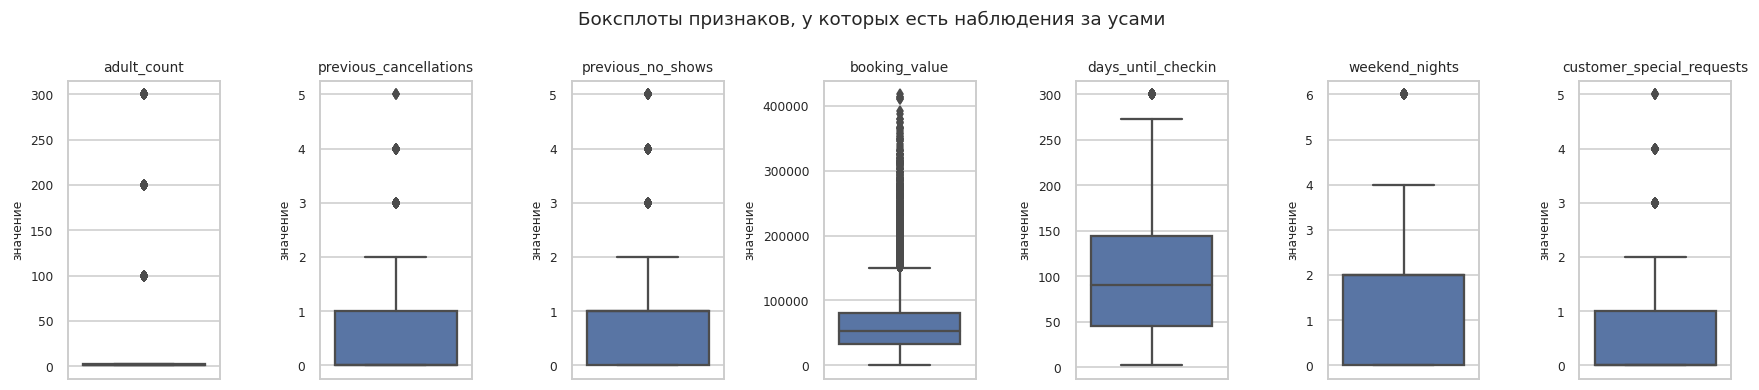

In [8]:
def iqr_summary(df, columns):
    """Сводка по правилу 1.5 IQR: границы усов и число наблюдений за ними."""
    rows = []
    for column in columns:
        series = df[column]
        q25, q75 = series.quantile([0.25, 0.75])
        iqr = q75 - q25
        low, high = q25 - 1.5 * iqr, q75 + 1.5 * iqr
        outliers = int(((series < low) | (series > high)).sum())
        rows.append([column, q25, q75, low, high, outliers,
                     round(outliers / len(series) * 100, 2), series.max()])
    return pd.DataFrame(
        rows,
        columns=["признак", "p25", "p75", "нижний_ус", "верхний_ус",
                 "за_усами", "за_усами_%", "максимум"],
    ).set_index("признак")


display(iqr_summary(bookings_raw, NUM_RAW))

# Боксплоты строим для всех признаков, у которых сводка нашла наблюдения за усами.
outlier_columns = ["adult_count", "previous_cancellations", "previous_no_shows",
                   "booking_value", "days_until_checkin", "weekend_nights",
                   "customer_special_requests"]
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(16, 3.6))
for ax, column in zip(axes, outlier_columns):
    sns.boxplot(y=bookings_raw[column], ax=ax, color="#4C72B0")
    ax.set_title(column, fontsize=9)
    ax.set_ylabel("значение", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Боксплоты признаков, у которых есть наблюдения за усами", fontsize=12)
fig.tight_layout()
plt.show()

#### Аномалии

Четыре находки требуют отдельной проверки: нереальное число взрослых в брони, нулевая стоимость, опечатка в справочнике питания и неявные пропуски, спрятанные под категорией «не выбран».

In [9]:
adult_counts = bookings_raw["adult_count"].value_counts().sort_index().to_frame("строк")
adult_counts["доля_%"] = (adult_counts["строк"] / len(bookings_raw) * 100).round(2)
adult_counts.index.name = "adult_count"
display(adult_counts.T)

zero_value = bookings_raw[bookings_raw["booking_value"] == 0]
not_selected = bookings_raw["meal_plan"].isin(["не выбран", "не выбрант"])
implicit_gaps = pd.DataFrame(
    [
        ["booking_value = 0", len(zero_value), round(len(zero_value) / len(bookings_raw) * 100, 2),
         "переводим в пропуск: минимальная ненулевая цена 6 700 руб."],
        ["meal_plan = «не выбран»", int(not_selected.sum()),
         round(not_selected.mean() * 100, 2),
         "оставляем категорией: это осмысленный ответ клиента, а не потеря данных"],
    ],
    columns=["неявный пропуск", "строк", "доля_%", "решение"],
).set_index("неявный пропуск")
display(implicit_gaps)

zero_stats = pd.DataFrame(
    [
        ["минимальная ненулевая стоимость", bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"].min()],
        ["доля отмен среди нулевых", round((zero_value["booking_status"] == "отказ_брони").mean(), 4)],
        ["доля отмен среди остальных",
         round((bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_status"] == "отказ_брони").mean(), 4)],
        ["медианная стоимость одной ночи, руб.",
         (bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"]
          / (bookings_raw["weekday_nights"] + bookings_raw["weekend_nights"])).median()],
        ["доля броней с ценой ровно 6 700 руб. за ночь, %",
         round(((bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"]
                 / (bookings_raw["weekday_nights"] + bookings_raw["weekend_nights"])
                 ).round(2) == 6700).mean() * 100, 2)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(zero_stats)

meal_plans = bookings_raw["meal_plan"].value_counts().to_frame("строк")
meal_plans.columns.name = "meal_plan"
display(meal_plans)

adult_count,1,2,3,100,200,300
строк,"13,361.0000","13,102.0000","6,727.0000",884.0000,872.0000,395.0000
доля_%,37.8100,37.0700,19.0300,2.5000,2.4700,1.1200


,строк,доля_%,решение
неявный пропуск,,,
booking_value = 0,1421,4.0200,переводим в пропуск: минимальная ненулевая цен...
meal_plan = «не выбран»,4933,13.9600,оставляем категорией: это осмысленный ответ кл...


,значение
показатель,
минимальная ненулевая стоимость,"6,700.0000"
доля отмен среди нулевых,0.2892
доля отмен среди остальных,0.2875
"медианная стоимость одной ночи, руб.","6,700.0000"
"доля броней с ценой ровно 6 700 руб. за ночь, %",74.2300


meal_plan,строк
тип_питания_1,27182
не выбран,4426
тип_питания_2,3219
не выбрант,507
тип_питания_3,7


#### Категориальные признаки

Для каждой категории смотрим наполненность и долю отмен: именно разница долей показывает, несёт ли признак сигнал о целевой переменной. Графики строим по всем семи признакам, а не выборочно, и рядом показываем размер каждой группы - без него разница долей на маленьких категориях вводит в заблуждение.

броней  доля_отмен_%
признак                значение                                        
sales_channel          корпоративное_бронирование   11747       16.7900
                       онлайн_бронирование          11554       41.4200
                       офлайн_бронирование          12040       28.2900
meal_plan              не выбран                     4426       28.9900
                       не выбрант                     507       31.3600
                       тип_питания_1                27182       28.7400
                       тип_питания_2                 3219       28.1800
                       тип_питания_3                    7       28.5700
room_type              тип_1                        27197       29.0300
                       тип_2                          658       27.5100
                       тип_3                           10       30.0000
                       тип_4                         6070       28.1400
                       тип_5                          272       25.3700
                       тип_6                          959       27.4200
                       тип_7                          175       26.2900
returning_customer     False                        15413       29.2600
                       True                         19928       28.3700
parking_included       False                        34165       28.6800
                       True                          1176       31.2100
previous_cancellations 0                            25152       25.2300
                       1                             8198       35.0800
                       2                             1624       45.3800
                       3                              304       58.8800
                       4                               59       38.9800
                       5                                4      100.0000
child_count            0                            24683       31.8400
                       1                             8629       15.8500
                       2                             2029       46.1800

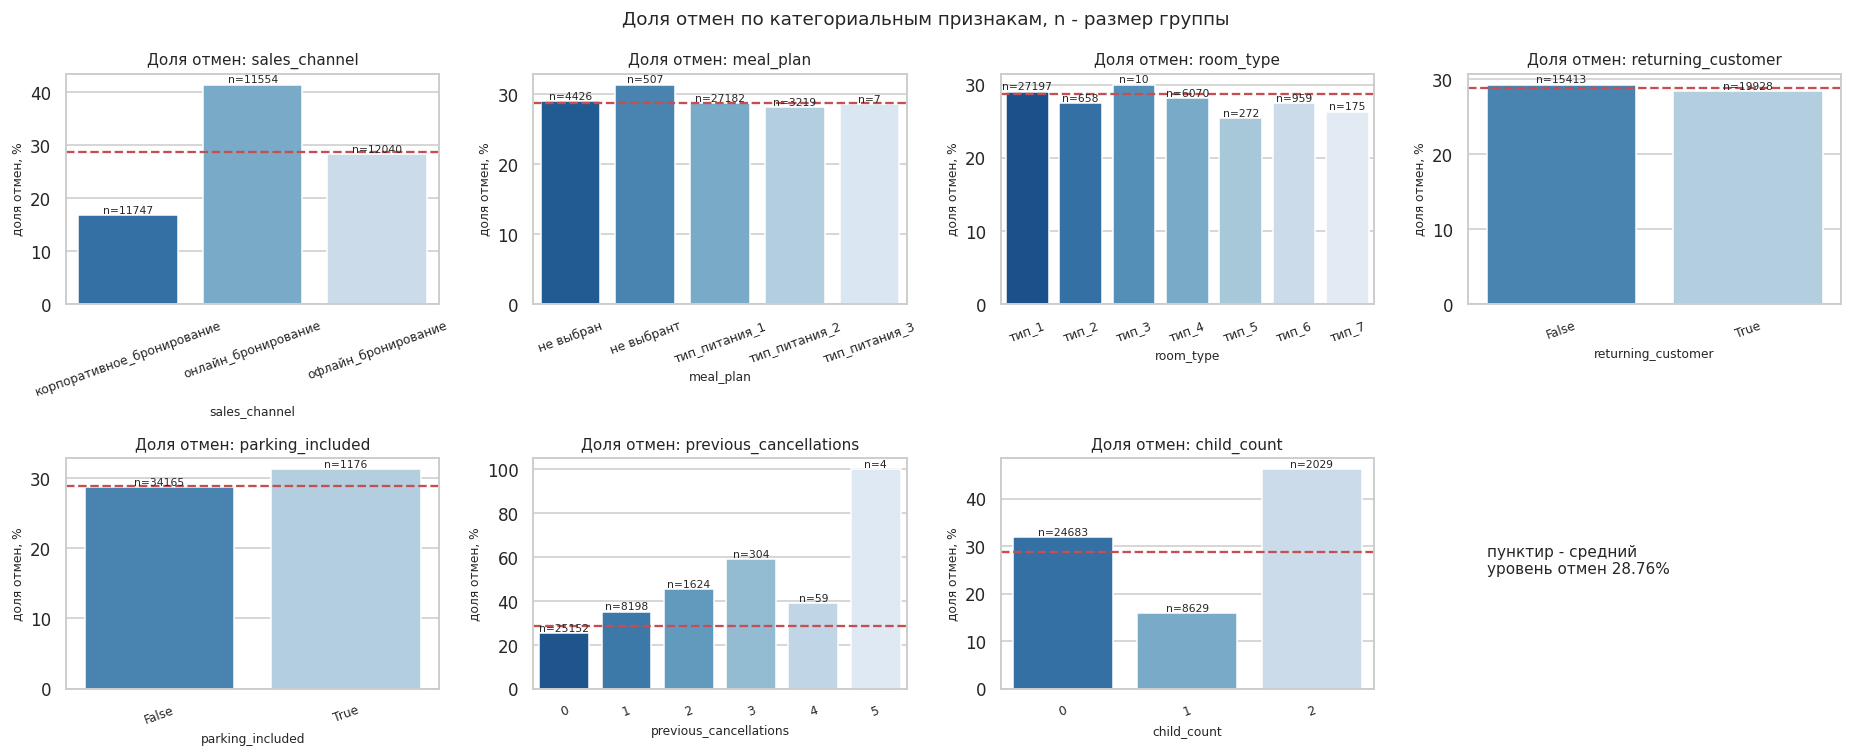

In [10]:
CAT_RAW = ["sales_channel", "meal_plan", "room_type", "returning_customer",
           "parking_included", "previous_cancellations", "child_count"]
cancel_flag = (bookings_raw["booking_status"] == "отказ_брони").astype(int)

cat_report = []
for column in CAT_RAW:
    grouped = cancel_flag.groupby(bookings_raw[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index()
    grouped.insert(0, "признак", column)
    grouped = grouped.rename(columns={column: "значение"})
    grouped["значение"] = grouped["значение"].astype(str)
    cat_report.append(grouped)
cat_report = pd.concat(cat_report, ignore_index=True).set_index(["признак", "значение"])
display(cat_report)

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, column in zip(axes.ravel(), CAT_RAW):
    grouped = cancel_flag.groupby(bookings_raw[column]).agg(["size", "mean"])
    rates = grouped["mean"] * 100
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, palette="Blues_r")
    ax.axhline(cancel_flag.mean() * 100, color="#C44E52", linestyle="--")
    for position, (value, size) in enumerate(zip(rates.values, grouped["size"].values)):
        ax.text(position, value, f"n={size}", ha="center", va="bottom", fontsize=7)
    ax.set_title(f"Доля отмен: {column}", fontsize=10)
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("доля отмен, %", fontsize=8)
    ax.tick_params(labelsize=8, axis="x", rotation=20)
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(0.05, 0.5, "пунктир - средний\nуровень отмен 28.76%", fontsize=10)
fig.suptitle("Доля отмен по категориальным признакам, n - размер группы", fontsize=12)
fig.tight_layout()
plt.show()

#### Связь количественных признаков с отменой

Корреляция Пирсона с бинарной целевой переменной показывает силу монотонной связи, а средние значения в разрезе статуса - её направление.

,корреляция_с_отменой,нет_отказа,отказ_брони
days_until_checkin,0.2824,87.6300,132.4700
previous_cancellations,0.1363,0.3000,0.4900
weekday_nights,-0.0751,6.6900,6.1400
weekend_nights,-0.0670,2.0200,1.8000
booking_value,-0.0582,"63,217.5800","57,711.5500"
child_count,-0.0433,0.3800,0.3200
previous_no_shows,-0.0297,0.8600,0.8000
customer_special_requests,-0.0081,0.6300,0.6100
adult_count,0.0051,12.3300,12.8500


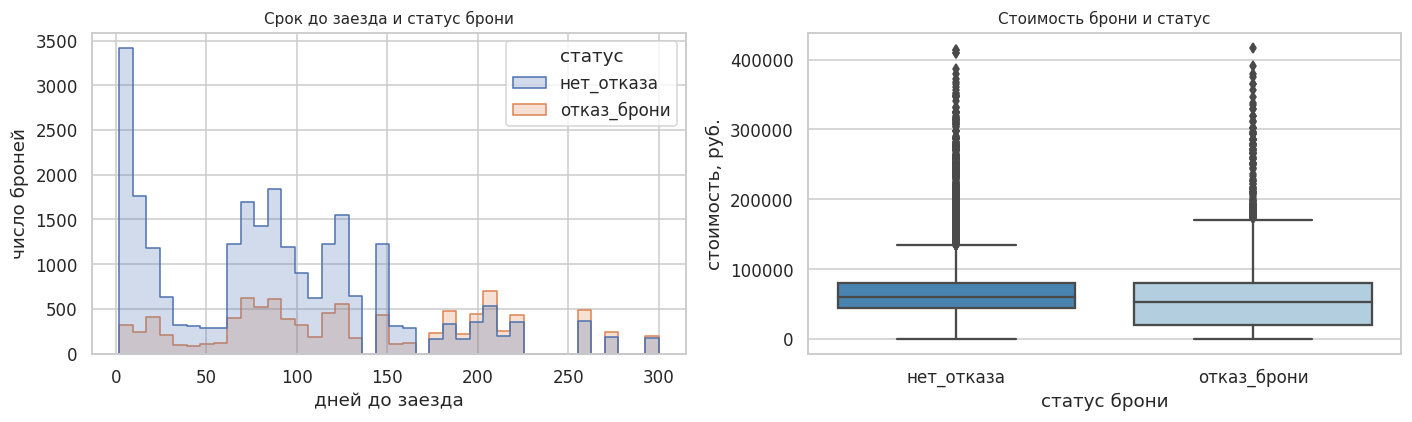

In [11]:
corr_target = (
    bookings_raw[NUM_RAW]
    .assign(is_cancelled=cancel_flag)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
means_by_status = bookings_raw.groupby("booking_status")[NUM_RAW].mean().T.round(2)
display(corr_target.join(means_by_status))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=bookings_raw.assign(статус=bookings_raw["booking_status"]),
             x="days_until_checkin", hue="статус", bins=40, ax=axes[0], element="step")
axes[0].set_title("Срок до заезда и статус брони", fontsize=10)
axes[0].set_xlabel("дней до заезда")
axes[0].set_ylabel("число броней")
sns.boxplot(data=bookings_raw, x="booking_status", y="booking_value", ax=axes[1], palette="Blues_r")
axes[1].set_title("Стоимость брони и статус", fontsize=10)
axes[1].set_xlabel("статус брони")
axes[1].set_ylabel("стоимость, руб.")
fig.tight_layout()
plt.show()

#### Таблица отзывов

Смотрим распределение оценок, длину и повторяемость текстов, период наблюдений.

stay_rating,отзывов,доля_%
2,523,2.0800
3,14336,56.9400
4,10160,40.3500
5,158,0.6300


,минимум,максимум
поле,,
hotel_bookings.booking_date,2017-01-01,2025-10-22
hotel_reviews.review_date,2017-01-17,2026-03-03


,значение
показатель,
отзывов всего,"25,177.0000"
уникальных текстов,"14,153.0000"
"доля повторяющихся текстов, %",43.7900
"медианная длина текста, символов",95.0000
"максимальная длина текста, символов",225.0000
уникальных дат отзывов,"2,514.0000"


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...


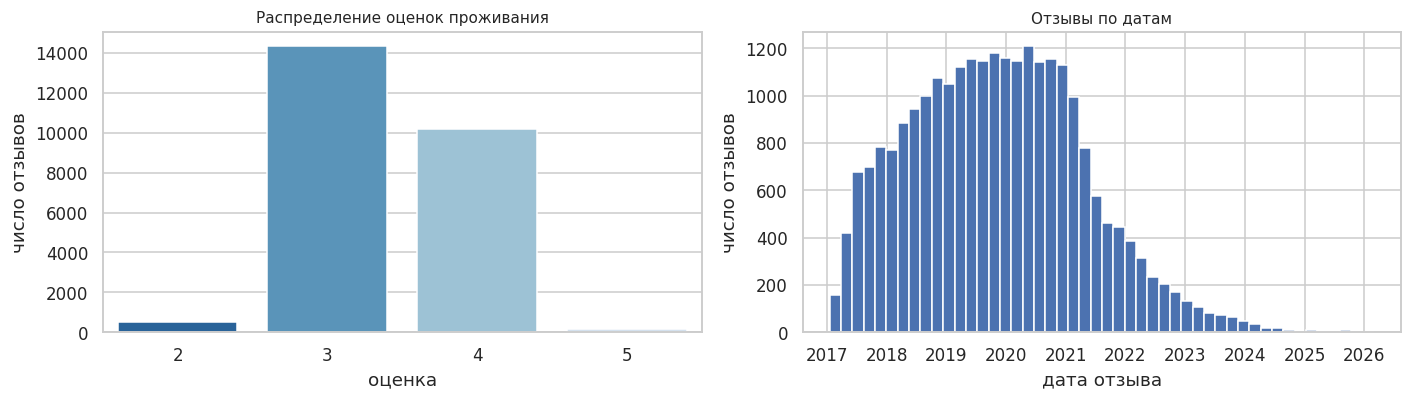

In [12]:
ratings = (
    reviews_raw["stay_rating"].value_counts().sort_index().to_frame("отзывов")
    .assign(**{"доля_%": lambda d: (d["отзывов"] / len(reviews_raw) * 100).round(2)})
)
ratings.columns.name = "stay_rating"
display(ratings)

review_dates = pd.to_datetime(reviews_raw["review_date"])
booking_dates = pd.to_datetime(bookings_raw["booking_date"])
periods = pd.DataFrame(
    [
        ["hotel_bookings.booking_date", booking_dates.min(), booking_dates.max()],
        ["hotel_reviews.review_date", review_dates.min(), review_dates.max()],
    ],
    columns=["поле", "минимум", "максимум"],
).set_index("поле")
display(periods)

text_stats = pd.DataFrame(
    [
        ["отзывов всего", len(reviews_raw)],
        ["уникальных текстов", reviews_raw["review_text"].nunique()],
        ["доля повторяющихся текстов, %",
         round((1 - reviews_raw["review_text"].nunique() / len(reviews_raw)) * 100, 2)],
        ["медианная длина текста, символов", reviews_raw["review_text"].str.len().median()],
        ["максимальная длина текста, символов", reviews_raw["review_text"].str.len().max()],
        ["уникальных дат отзывов", review_dates.nunique()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(text_stats)
display(reviews_raw[["customer_id", "booking_id", "review_date", "stay_rating", "review_text"]].head(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.countplot(x=reviews_raw["stay_rating"], ax=axes[0], palette="Blues_r")
axes[0].set_title("Распределение оценок проживания", fontsize=10)
axes[0].set_xlabel("оценка")
axes[0].set_ylabel("число отзывов")
axes[1].hist(review_dates, bins=48, color="#4C72B0")
axes[1].set_title("Отзывы по датам", fontsize=10)
axes[1].set_xlabel("дата отзыва")
axes[1].set_ylabel("число отзывов")
fig.tight_layout()
plt.show()

#### Проверка связи таблиц: где прячется утечка целевой переменной

В `hotel_bookings` нет `customer_id`, поэтому единственный способ узнать клиента - подтянуть его из `hotel_reviews` по `booking_id`. Прежде чем так делать, проверяем, как наличие отзыва связано со статусом брони.

booking_status,нет_отказа,отказ_брони
отзывов по брони,,
0,0,8850
1,18858,0
2,2776,0
3,229,0
4,20,0


,значение
показатель,
уникальных booking_id в бронированиях,30733
из них есть в таблице отзывов,21883
"booking_id из отзывов, которых нет в бронированиях",0
уникальных клиентов в отзывах,13429


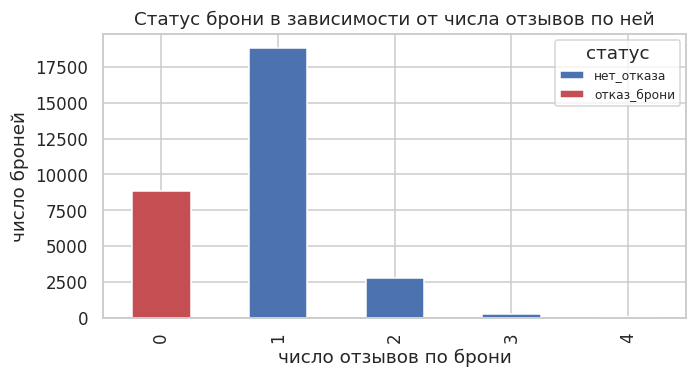

In [13]:
bookings_unique = bookings_raw.drop_duplicates()
reviews_per_booking = reviews_raw.groupby("booking_id").size()
leak_check = pd.crosstab(
    bookings_unique["booking_id"].map(reviews_per_booking).fillna(0).astype(int),
    bookings_unique["booking_status"],
)
leak_check.index.name = "отзывов по брони"
display(leak_check)

coverage = pd.DataFrame(
    [
        ["уникальных booking_id в бронированиях", bookings_unique["booking_id"].nunique()],
        ["из них есть в таблице отзывов", bookings_unique["booking_id"].isin(reviews_raw["booking_id"]).sum()],
        ["booking_id из отзывов, которых нет в бронированиях",
         int((~reviews_raw["booking_id"].isin(bookings_raw["booking_id"])).sum())],
        ["уникальных клиентов в отзывах", reviews_raw["customer_id"].nunique()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(coverage)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
leak_check.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Статус брони в зависимости от числа отзывов по ней")
ax.set_xlabel("число отзывов по брони")
ax.set_ylabel("число броней")
ax.legend(title="статус", fontsize=8)
fig.tight_layout()
plt.show()

#### Предобработка

Исправляем найденные дефекты функциями `clean_bookings` и `clean_reviews` из модуля `feature_pipeline`:

- удаляем полные дубли строк;
- делим на 100 значения `adult_count` вида 100/200/300 - это ошибка ввода лишних нулей;
- сводим опечатку `не выбрант` к категории `не выбран`;
- удаляем строки с нулевой стоимостью брони: минимальная ненулевая цена - 6 700 руб., поэтому ноль здесь не «бесплатный номер», а некорректная запись. Восстанавливать её импутацией нельзя - это значит придумать стоимость там, где её не было;
- приводим даты к `datetime`, булевы поля - к 0/1 и создаём целевую переменную `is_cancelled`.

Исправления - доменные (ошибки ввода), они не используют статистику выборки, поэтому применяются до разделения на train/test и утечки не создают.

In [14]:
bookings = fp.clean_bookings(bookings_raw)
reviews = fp.clean_reviews(reviews_raw)

prep_report = pd.DataFrame(
    [
        ["строк в hotel_bookings", len(bookings_raw), len(bookings)],
        ["строк в hotel_reviews", len(reviews_raw), len(reviews)],
        ["adult_count >= 10", int((bookings_raw["adult_count"] >= 10).sum()),
         int((bookings["adult_count"] >= 10).sum())],
        ["категорий meal_plan", bookings_raw["meal_plan"].nunique(), bookings["meal_plan"].nunique()],
        ["строк с booking_value = 0", int((bookings_raw["booking_value"] == 0).sum()),
         int((bookings["booking_value"] == 0).sum())],
        ["пропусков в booking_value", int(bookings_raw["booking_value"].isna().sum()),
         int(bookings["booking_value"].isna().sum())],
    ],
    columns=["показатель", "до_предобработки", "после_предобработки"],
).set_index("показатель")
display(prep_report)

removed = pd.DataFrame(
    [
        ["полные дубли строк", len(bookings_raw) - len(bookings_raw.drop_duplicates())],
        ["строки с нулевой стоимостью",
         int((bookings_raw.drop_duplicates()["booking_value"] == 0).sum())],
        ["осталось броней", len(bookings)],
    ],
    columns=["что удалено", "строк"],
).set_index("что удалено")
display(removed)

display(bookings[["adult_count", "booking_value"]].describe().T.round(2))
display(bookings["is_cancelled"].value_counts(normalize=True).round(4).to_frame("доля"))

,до_предобработки,после_предобработки
показатель,,
строк в hotel_bookings,35341,29504
строк в hotel_reviews,25177,25177
adult_count >= 10,2151,0
категорий meal_plan,5,4
строк с booking_value = 0,1421,0
пропусков в booking_value,0,0


,строк
что удалено,
полные дубли строк,4608
строки с нулевой стоимостью,1229
осталось броней,29504


,count,mean,std,min,25%,50%,75%,max
adult_count,"29,504.0000",1.8000,0.7500,1.0000,1.0000,2.0000,2.0000,3.0000
booking_value,"29,504.0000","64,248.4400","41,683.1400","6,700.0000","46,900.0000","60,300.0000","89,000.0000","417,221.2000"


,доля
0,0.7122
1,0.2878


### Выводы по исследовательскому анализу

**Качество данных**

- **Явных пропусков (NaN) нет ни в одной таблице**, но есть неявные: у **1 421 брони (4.02%)** стоимость равна нулю при минимальной ненулевой цене 6 700 руб., и у **4 933 броней (13.96%)** тип питания «не выбран». Решения разные: нулевая стоимость - некорректная запись, такие строки удаляются; «не выбран» - осмысленный ответ клиента, остаётся категорией.
- В `hotel_bookings` **4 608 полных дублей строк** (13.0% таблицы): `booking_id` повторяется до четырёх раз, но внутри каждой группы дублей все 16 столбцов имеют ровно одно уникальное значение. Это технические копии, а не конфликт данных, поэтому дубли удалены.
- В `hotel_reviews` полных дублей нет, но есть **130 повторов пары `booking_id` + `review_date`** (260 строк). Проверка на конфликт: внутри пары всегда один клиент, но до двух разных оценок и до двух разных текстов. Значит это действительно разные отзывы одного гостя, оставленные в один день, - удалять их нельзя.

**Аномалии и их исправление**

- `adult_count` принимает значения **100 (884 строки, 2.50%), 200 (872, 2.47%) и 300 (395, 1.12%)** - суммарно 2 151 запись, 6.09% таблицы. Столько взрослых в одном номере невозможно, а частоты этих значений пропорциональны частотам 1 / 2 / 3 (37.81%, 37.07%, 19.03%), то есть это ошибка ввода лишних нулей. Значения поделены на 100, после чего максимум `adult_count` стал равен 3.
- **Нулевая стоимость брони - некорректная запись, а не «бесплатный номер».** Восстанавливать её импутацией нельзя: это означало бы придумать цену там, где её не было. После дедупликации таких строк 1 229, и они удалены. Доля отмен среди них (28.92%) практически совпадала с остальными (28.75%), поэтому удаление не смещает целевую переменную.
- В справочнике питания опечатка: категория **`не выбрант` (507 строк)** сведена к `не выбран`, число категорий уменьшилось с 5 до 4.
- Выбросы по правилу 1.5 IQR: `booking_value` - 1 006 наблюдений (2.85%, максимум 417 221 руб.), `weekend_nights` - 1 082 (3.06%), `previous_no_shows` - 2 137 (6.05%). Это правдоподобные значения, поэтому они сохранены. Единственные выбросы, которые были ошибкой, - те самые 2 151 запись по `adult_count`.
- **Тариф в данных почти постоянный**: медианная стоимость ночи - 6 700 руб., и ровно столько стоит ночь у **74.23%** броней.

**После предобработки в моделирование идут 29 504 брони** (было 35 341): удалено 4 608 дублей и 1 229 строк с нулевой стоимостью. Доля отмен - 28.78%.

**Целевая переменная, время и связи с признаками**

- Доля отмен в исходной выгрузке - **28.76%**. Дисбаланс умеренный, но заметный, поэтому accuracy неинформативна.
- **Премисса заказчика о росте отмен в последние два года данными не подтверждается: тренд есть, но противоположный.** Доля отмен держалась на уровне 29-30% в 2017-2020 годах (29.66%, 29.12%, 29.55%, 29.83%) и затем снижалась: 24.37% в 2021, 22.86% в 2022, 19.30% в 2023. Объём выгрузки после 2020 обрывается: с 8 668 броней в 2020 до 373 в 2023 и 20 в 2025.
- **Этот тренд определяет схему разбиения выборок.** Задача прогнозная: модель учится на прошлом и работает на будущем, поэтому train / calibration / test делятся хронологически, без перемешивания и стратификации. Доли отмен в выборках при этом различаются - и это правильно отражает реальность, в которой уровень отмен со временем менялся.
- **Сезонности спроса в данных нет**: заезды распределены по месяцам практически равномерно, от 7.79% (февраль) до 8.87% (май).
- Сильнее всего с отменой связан **срок до заезда**: корреляция 0.282, средний срок у отменённых броней 132 дня против 88 у состоявшихся.
- **Канал продаж** разделяет клиентов лучше всех категорий: онлайн-бронирования отменяются в **41.42%** случаев, офлайн - в 28.29%, корпоративные - в **16.79%**.
- **История клиента работает монотонно**: без прошлых отмен - 25.23% отмен, с одной - 35.08%, с двумя - 45.38%, с тремя - 58.88%.
- **Число детей влияет немонотонно**: 31.84% отмен без детей, 15.85% с одним ребёнком и 46.18% с двумя.
- Тип номера и тип питания почти не различают классы: разброс долей отмен 25-31% при среднем 28.76%, причём самые крайние значения посчитаны на единицах наблюдений - `тип_3` встречается 10 раз, `тип_питания_3` - 7 раз.

**Отзывы**

- Оценки лежат в диапазоне **от 2 до 5, оценки 1 в данных нет**; 56.94% отзывов имеют оценку 3, 40.35% - оценку 4. Тексты короткие (медиана 95 символов) и сильно повторяются: **43.79% текстов не уникальны**.
- Период отзывов (2017-01-17 - 2026-03-03) выходит за правую границу периода броней (2017-01-01 - 2025-10-22). Это не «сироты»: записей из отзывов, которых нет в бронированиях, ровно **0**. Отзыв оставляют после заезда, а заезд наступает до 300 дней спустя после оформления брони.

**Главная находка: отзыв однозначно выдаёт статус брони**

Кросс-таблица «число отзывов по брони» против статуса не оставляет вариантов: у **8 850 броней отзывов нет, и все они отменены**; у **21 883 броней есть хотя бы один отзыв, и ни одна из них не отменена**. Отзыв оставляет тот, кто заселился, поэтому `customer_id`, восстановленный через `booking_id`, равносилен ответу «бронь состоялась».

**Итог:** данные требуют трёх исправлений (дубли, ошибка ввода в `adult_count`, удаление броней с нулевой стоимостью) и одного принципиального решения - не связывать таблицы по клиенту.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* проверены пропуски и дубли
* отдельно исследована уникальность ключей
* разобраны конфликты в отзывах
* исследован target
* есть анализ во времени

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
booking_value == 0 сейчас переводится в NaN, а затем значение восстанавливается медианой train. Нулевые стоимости здесь являются некорректными строками, их нужно удалить, а не придумывать для них стоимость через импутацию

<div class="alert alert-info"> <b>Комментарий студента:</b>

Спасибо, исправил. Нулевые стоимости теперь удаляются, а не восстанавливаются импутацией.

**Что изменено в коде.** В `feature_pipeline.clean_bookings` строка

```python
out["booking_value"] = out["booking_value"].replace({0.0: np.nan})
```

заменена на

```python
out = out[out["booking_value"] > 0].reset_index(drop=True)
```

**Как изменились числа.** Из 35 341 строки исходной таблицы удалено 4 608 полных дублей и 1 229 строк с нулевой стоимостью - в моделирование идут **29 504 брони**. В таблице предобработки добавлена строка «строк с booking_value = 0» и отдельная сводка удалённых строк. Пропусков в `price_per_night` больше нет вообще (было 4.00%), поэтому импьютер по этой колонке ничего не восстанавливает.

</div>

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

Правило объединения из задания - «к дате брони подтянуть ближайший предшествующий по дате отзыв». Прежде чем реализовать его, проверяем буквальный вариант ТЗ - связь по клиенту - и смотрим, что из него получается.

In [15]:
# Буквальный вариант ТЗ: восстанавливаем клиента по booking_id и берём его предыдущий отзыв.
customer_map = reviews[["booking_id", "customer_id"]].drop_duplicates("booking_id")
bookings_with_customer = bookings.merge(customer_map, on="booking_id", how="left")

per_customer = pd.merge_asof(
    bookings_with_customer.sort_values("booking_date"),
    reviews.sort_values("review_date")[["customer_id", "review_date", "stay_rating"]],
    left_on="booking_date",
    right_on="review_date",
    by="customer_id",
    direction="backward",
    allow_exact_matches=False,
)

leak_demo = pd.crosstab(
    np.where(per_customer["customer_id"].isna(), "клиент не найден", "клиент найден"),
    np.where(per_customer["is_cancelled"] == 1, "отказ_брони", "нет_отказа"),
)
leak_demo.index.name = "результат связи по клиенту"
display(leak_demo)

leak_rates = pd.DataFrame(
    [
        ["клиент найден через booking_id", int(per_customer["customer_id"].notna().sum()),
         round(per_customer.loc[per_customer["customer_id"].notna(), "is_cancelled"].mean() * 100, 2)],
        ["клиент не найден", int(per_customer["customer_id"].isna().sum()),
         round(per_customer.loc[per_customer["customer_id"].isna(), "is_cancelled"].mean() * 100, 2)],
    ],
    columns=["группа", "броней", "доля_отмен_%"],
).set_index("группа")
display(leak_rates)

col_0,нет_отказа,отказ_брони
результат связи по клиенту,,
клиент найден,21012,0
клиент не найден,0,8492


,броней,доля_отмен_%
группа,,
клиент найден через booking_id,21012,0.0000
клиент не найден,8492,100.0000


Связь по клиенту делит выборку ровно по целевой переменной: у всех броней, для которых клиент нашёлся, доля отмен 0%, у всех остальных - 100%. Причина в устройстве данных: `customer_id` есть только в таблице отзывов, а отзыв оставляет тот, кто заселился. Значит любой признак, полученный этим путём - включая сам факт «клиент найден», - это ответ, а не сигнал: модель показала бы почти идеальное качество на истории и не работала бы в проде, где статус брони ещё неизвестен.

Поэтому объединение выполняется только по времени: `pd.merge_asof(direction="backward", allow_exact_matches=False)` берёт последний отзыв, оставленный строго до даты оформления брони. Такой признак известен отелю в момент прогноза и утечки не создаёт. Плата за это - отзыв относится к чужой поездке, и одна и та же запись достаётся всем броням одного дня; насколько это ограничивает пользу признака, видно из таблицы ниже.

In [16]:
data = fp.add_demand_features(fp.join_reviews(bookings, reviews))

join_report = pd.DataFrame(
    [
        ["строк до объединения", len(bookings)],
        ["строк после объединения", len(data)],
        ["броней без предшествующего отзыва", int(data["stay_rating"].isna().sum())],
        ["доля броней без отзыва, %", round(data["stay_rating"].isna().mean() * 100, 2)],
        ["медианный лаг «отзыв -> бронь», дней", data["review_lag_days"].median()],
        ["максимальный лаг «отзыв -> бронь», дней", data["review_lag_days"].max()],
        ["уникальных отзывов, попавших в признаки", data["review_text"].nunique()],
        ["отзывов в исходной таблице", len(reviews)],
        ["броней на один подтянутый отзыв",
         round(len(data) / max(data["review_text"].nunique(), 1), 1)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(join_report)

# Контроль корректности asof-соединения: дата отзыва строго раньше даты брони,
# а число строк совпадает с числом броней (дублирования при соединении нет).
assert len(data) == len(bookings)
assert (data["review_lag_days"].dropna() >= 1).all()

display(data[["booking_date", "review_date", "review_lag_days", "stay_rating", "review_text"]]
        .dropna(subset=["review_date"]).head())

rating_vs_target = data.groupby("stay_rating")["is_cancelled"].agg(["size", "mean"])
rating_vs_target.columns = ["броней", "доля_отмен"]
rating_vs_target["доля_отмен_%"] = (rating_vs_target["доля_отмен"] * 100).round(2)
display(rating_vs_target.drop(columns="доля_отмен"))

,значение
показатель,
строк до объединения,"29,504.0000"
строк после объединения,"29,504.0000"
броней без предшествующего отзыва,185.0000
"доля броней без отзыва, %",0.6300
"медианный лаг «отзыв -> бронь», дней",1.0000
"максимальный лаг «отзыв -> бронь», дней",35.0000
"уникальных отзывов, попавших в признаки","2,031.0000"
отзывов в исходной таблице,"25,177.0000"
броней на один подтянутый отзыв,14.5000


,booking_date,review_date,review_lag_days,stay_rating,review_text
185,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
186,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
187,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
188,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
189,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...


,броней,доля_отмен_%
stay_rating,,
2.0000,507,27.8100
3.0000,17355,28.8500
4.0000,11279,28.7100
5.0000,178,27.5300


**Выводы по объединению таблиц**

**Буквальный вариант ТЗ проверен и отвергнут числами.** Связь по клиенту через `booking_id` делит выборку ровно по целевой переменной: среди 21 012 броней, для которых клиент нашёлся, доля отмен **0.00%**, среди 8 492 остальных - **100.00%**. Признак «клиент найден» - это ответ, а не сигнал.

**Объединение по времени выполнено, но его результат в модель не идёт.**

- `pd.merge_asof(direction="backward", allow_exact_matches=False)` берёт последний отзыв, оставленный строго до даты оформления брони;
- число строк не изменилось - **29 504 до и после соединения**, дублирования при join нет (проверено `assert`), лаг «отзыв - бронь» везде не меньше одного дня (тоже `assert`);
- без предшествующего отзыва осталось **185 записей (0.63%)** - самые ранние брони января 2017 года.

**Почему признаки отзывов не попадают в модель.** Отзывы приходят почти ежедневно: медианный лаг - **1 день**, максимальный - 35. Поэтому всем броням одного дня достаётся один и тот же отзыв: в объединение попали **2 031 уникальный текст**, в среднем **14.5 брони на один подтянутый отзыв**. Такой признак характеризует календарный день и постороннего гостя, а не клиента текущей брони, и в обучающую матрицу он не передаётся.

Проверка на сигнал подтверждает вывод: доля отмен по подтянутой оценке лежит в коридоре **27.53-28.85%** при среднем уровне 28.78%. Связи между оценкой чужого гостя и отменой текущей брони нет.

**Итог:** соединение выполнено корректно и без потери строк, но использовать его результат как признаки нельзя. Для полноценной работы с историей отзывов нужен `customer_id`, известный в момент оформления брони, - в выгрузке его нет.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Очень хорошо, что ты отдельно проверил буквальное объединение через customer_id и обнаружил проблем

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Но выбранное решение:
    
        объединить бронирование с последним отзывом вообще любого клиента до даты бронирования

тоже некорректно.

В таком случае stay_rating и review_text относятся к другому гостю и не характеризуют текущего клиента. Сам проект это подтверждает: один отзыв в среднем назначается примерно 15 различным броням.

Правильнее оставить проверку объединения по клиенту как исследовательский этап, показать обнаруженную структурную утечку и не использовать признаки отзывов в финальном X:

    stay_rating
    review_lag_days
    review_text
    TF-IDF по этому тексту

Для полноценного использования истории отзывов нужен отдельный customer_id, который известен для каждой брони уже в момент её оформления и не восстанавливается через факт состоявшегося проживания

<div class="alert alert-info"> <b>Комментарий студента:</b>

Согласен, объединение по дате не делает отзыв характеристикой текущего клиента. Признаки отзывов из модели убраны, а сам этап оставлен как исследовательский - ровно так, как ты предлагаешь.

**Что изменено в коде.** В `feature_pipeline` появился список

```python
REVIEW_COLS = ["stay_rating", "review_lag_days", "review_text"]
```

и он исключён из `feature_cols()`; из `make_preprocessor()` убран блок TF-IDF. Векторизатор вынесен в отдельную функцию `make_review_vectorizer()`, которая используется только в исследовательской ячейке ниже.

**Как изменились числа.** В модель идёт **20 признаков** (15 числовых и 5 категориальных) вместо 24 столбцов с 60 колонками TF-IDF; после препроцессора - 36 колонок вместо 99. Раздел объединения и раздел векторизации остались на месте: там по-прежнему показано, что связь по клиенту даёт 0.00% отмен против 100.00%, а один отзыв достаётся в среднем 14.5 брони.

</div>

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

Признаки собираются функцией `build_features` из `feature_pipeline.py`.

**Признаки по данным о брони:**

| Признак | Логика |
|---|---|
| `total_nights` | общая длительность проживания, сумма будних и выходных ночей |
| `weekend_share` | доля выходных ночей: отличает деловые поездки от отдыха |
| `guests_total` | общее число гостей, взрослые плюс дети |
| `price_per_night` | стоимость одной ночи, сопоставимая цена для броней разной длительности |
| `customer_loyalty` | **лояльность клиента** из ТЗ: доля состоявшихся заездов среди прошлых бронирований, $(no\_shows + 1) / (no\_shows + cancellations + 2)$; сглаживание даёт новым клиентам нейтральные 0.5 |
| `checkin_month`, `checkin_dayofweek` | месяц и день недели планируемого заезда, восстановлены из даты брони и срока до заезда |
| `booking_month` | месяц оформления брони |
| `season_group` | **категоризация сезонности**: лето и декабрь, межсезонье (февраль, март, октябрь, ноябрь), прочие месяцы |
| `lead_time_group` | **категоризация срока до заезда**: до месяца, 1-3 месяца, 3-6 месяцев, более полугода |

**Признаки спроса** (проверяются отдельной гипотезой на этапе моделирования): `same_checkin_prior_bookings` - сколько броней на ту же дату заезда уже оформлено к моменту текущей, `bookings_prev_30d` - активность бронирования за предыдущие 30 дней. Обе величины считаются только по ранее оформленным броням, поэтому доступны в момент прогноза.

**Признаки из отзывов в модель не входят.** `stay_rating`, `review_lag_days` и TF-IDF по `review_text` создаются и исследуются ниже, но в обучающую матрицу не попадают: после объединения по дате отзыв принадлежит постороннему гостю, а не клиенту текущей брони. Связать отзыв с клиентом можно было бы только через `customer_id`, известный в момент оформления брони, - в выгрузке его нет, а восстановление через факт состоявшегося проживания даёт утечку целевой переменной. Объединение и векторизация остаются в тетради как выполненный исследовательский этап.

**`booking_year` в набор не входит.** Разбиение хронологическое, поэтому в калибровочной и тестовой выборках встречаются годы, которых не было в обучении: модель вынуждена экстраполировать, а сам признак описывает период выгрузки, а не свойство брони. `booking_month` при этом оставлен - месяцы повторяются во всех выборках.

Пары признаков, из которых собраны производные, из набора убраны, чтобы не оставлять точные линейные зависимости: `weekday_nights` и `weekend_nights` заменены на `total_nights` + `weekend_share`, `adult_count` - на `guests_total` (вместе с сохранённым `child_count` это то же самое количество информации), `booking_value` - на `price_per_night`. `customer_loyalty` - нелинейное преобразование, а `season_group` и `lead_time_group` - категоризация, поэтому они сосуществуют с исходными счётчиками и сроком до заезда.

,столбцов,состав
группа,,
создано по данным о брони,10,"total_nights, weekend_share, guests_total, pri..."
взято из исходной таблицы без изменений,10,"days_until_checkin, child_count, previous_canc..."
признаки спроса (проверяются гипотезой),2,"same_checkin_prior_bookings, bookings_prev_30d"
"исследованы, но в модель НЕ входят (отзывы)",3,"stay_rating, review_lag_days, review_text"
итого базовый набор,20,без признаков спроса и без признаков отзывов
итого с признаками спроса,22,оба набора разбиваются на выборки одинаково


,days_until_checkin,total_nights,weekend_share,guests_total,child_count,price_per_night,previous_cancellations,previous_no_shows,customer_loyalty,customer_special_requests,returning_customer,parking_included,checkin_month,checkin_dayofweek,booking_month,sales_channel,meal_plan,room_type,season_group,lead_time_group
0,124,10,0.2000,5,2,"6,700.0000",0,0,0.5000,0,0,0,5,4,1,онлайн_бронирование,тип_питания_2,тип_2,прочие_месяцы,3-6_месяцев
1,63,1,0.0000,3,0,"6,700.0000",0,0,0.5000,1,0,0,3,6,1,корпоративное_бронирование,тип_питания_1,тип_4,межсезонье,1-3_месяца
2,87,16,0.2500,2,0,"10,397.7125",0,0,0.5000,0,0,0,3,2,1,онлайн_бронирование,тип_питания_2,тип_1,межсезонье,1-3_месяца
3,85,7,0.2857,1,0,"6,700.0000",1,1,0.5000,2,1,1,3,0,1,корпоративное_бронирование,тип_питания_1,тип_1,межсезонье,1-3_месяца
4,83,7,0.2857,3,0,"6,700.0000",1,1,0.5000,2,1,0,3,5,1,онлайн_бронирование,тип_питания_1,тип_1,межсезонье,1-3_месяца


,count,mean,std,min,25%,50%,75%,max
total_nights,"29,504.0000",8.4880,4.7240,1.0000,5.0000,8.0000,11.0000,21.0000
weekend_share,"29,504.0000",0.1860,0.1140,0.0000,0.0000,0.2220,0.2860,0.2860
guests_total,"29,504.0000",2.1580,0.9510,1.0000,1.0000,2.0000,3.0000,5.0000
price_per_night,"29,504.0000","7,564.2910","2,167.8880","6,700.0000","6,700.0000","6,700.0000","6,700.0000","19,995.3500"
customer_loyalty,"29,504.0000",0.5620,0.1210,0.1670,0.5000,0.5000,0.6670,0.8570


,count,mean,std,min,25%,50%,75%,max
stay_rating,"29,319.0000",3.3800,0.5310,2.0000,3.0000,3.0000,4.0000,5.0000
review_lag_days,"29,319.0000",1.0330,0.5920,1.0000,1.0000,1.0000,1.0000,35.0000


,count,mean,std,min,25%,50%,75%,max
same_checkin_prior_bookings,"29,504.0000",7.9200,6.1100,0.0000,3.0000,7.0000,12.0000,37.0000
bookings_prev_30d,"29,504.0000",470.9300,148.3700,0.0000,395.0000,539.0000,577.0000,640.0000


броней  доля_отмен_%
признак         значение                            
season_group    лето_и_декабрь    9919       28.3300
                межсезонье        9734       28.3400
                прочие_месяцы     9851       29.6700
lead_time_group 1-3_месяца        8304       25.6300
                3-6_месяцев       9225       26.6700
                более_полугода    5148       56.8200
                до_месяца         6827       14.3400

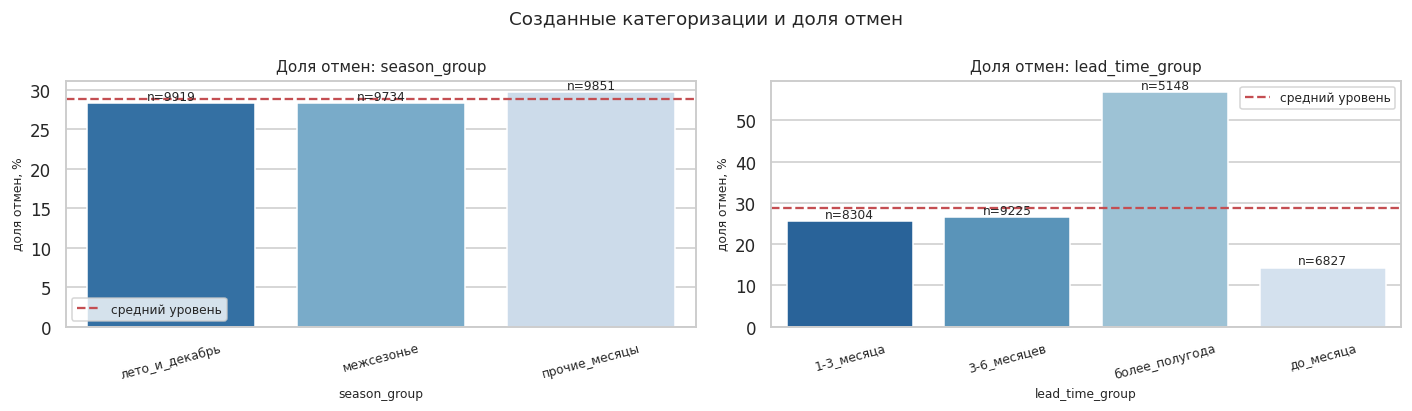

,броней,доля_отмен_%
customer_loyalty,,
"(0.0, 0.4]",2603,46.6400
"(0.4, 0.5]",14981,29.1000
"(0.5, 0.6]",1392,31.5400
"(0.6, 1.0]",10528,23.5600


In [17]:
features_base = fp.build_features(data, with_demand=False)
features_demand = fp.build_features(data, with_demand=True)
target = data[fp.TARGET].values

CREATED_FROM_BOOKING = [
    "total_nights", "weekend_share", "guests_total", "price_per_night", "customer_loyalty",
    "checkin_month", "checkin_dayofweek", "booking_month",
    "season_group", "lead_time_group",
]
CREATED_FROM_REVIEWS = fp.REVIEW_COLS
KEPT_AS_IS = [
    "days_until_checkin", "child_count", "previous_cancellations", "previous_no_shows",
    "customer_special_requests", "returning_customer", "parking_included",
    "sales_channel", "meal_plan", "room_type",
]
groups = [
    ["создано по данным о брони", CREATED_FROM_BOOKING],
    ["взято из исходной таблицы без изменений", KEPT_AS_IS],
    ["признаки спроса (проверяются гипотезой)", list(fp.DEMAND_COLS)],
    ["исследованы, но в модель НЕ входят (отзывы)", CREATED_FROM_REVIEWS],
]
feature_overview = pd.DataFrame(
    [[name, len(columns), ", ".join(columns)] for name, columns in groups],
    columns=["группа", "столбцов", "состав"],
).set_index("группа")
feature_overview.loc["итого базовый набор"] = [
    features_base.shape[1], "без признаков спроса и без признаков отзывов"
]
feature_overview.loc["итого с признаками спроса"] = [
    features_demand.shape[1], "оба набора разбиваются на выборки одинаково"
]
display(feature_overview)

display(features_base.head())
display(features_base[["total_nights", "weekend_share", "guests_total", "price_per_night",
                       "customer_loyalty"]].describe().T.round(3))

# Признаки отзывов считаются на объединённой таблице, но в модель не передаются.
display(data[fp.REVIEW_COLS[:2]].describe().T.round(3))
display(features_demand[fp.DEMAND_COLS].describe().T.round(2))

new_cat_rates = []
for column in ["season_group", "lead_time_group"]:
    grouped = pd.Series(target, index=features_base.index).groupby(features_base[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index().rename(columns={column: "значение"})
    grouped.insert(0, "признак", column)
    new_cat_rates.append(grouped)
display(pd.concat(new_cat_rates, ignore_index=True).set_index(["признак", "значение"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, column in zip(axes, ["season_group", "lead_time_group"]):
    grouped = pd.Series(target, index=features_base.index).groupby(features_base[column]).agg(["size", "mean"])
    rates = grouped["mean"] * 100
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, palette="Blues_r")
    ax.axhline(target.mean() * 100, color="#C44E52", linestyle="--", label="средний уровень")
    for position, (value, size) in enumerate(zip(rates.values, grouped["size"].values)):
        ax.text(position, value, f"n={size}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Доля отмен: {column}", fontsize=10)
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("доля отмен, %", fontsize=8)
    ax.tick_params(labelsize=8, axis="x", rotation=15)
    ax.legend(fontsize=8)
fig.suptitle("Созданные категоризации и доля отмен", fontsize=12)
fig.tight_layout()
plt.show()

loyalty_rates = (
    pd.Series(target, index=features_base.index)
    .groupby(pd.cut(features_base["customer_loyalty"], bins=[0, 0.4, 0.5, 0.6, 1.0]))
    .agg(["size", "mean"])
)
loyalty_rates.columns = ["броней", "доля_отмен"]
loyalty_rates["доля_отмен_%"] = (loyalty_rates["доля_отмен"] * 100).round(2)
loyalty_rates.index.name = "customer_loyalty"
display(loyalty_rates.drop(columns="доля_отмен"))

Векторизация текстов выполнена как **исследовательский этап**: смотрим, что вообще попадает в текстовые признаки - словарь TF-IDF и частоты слов, - и насколько разнообразны тексты, доставшиеся броням после объединения по дате. В обучающую матрицу эти колонки не передаются по причине, разобранной выше: отзыв относится к чужой поездке.

In [18]:
vectorizer = fp.make_review_vectorizer()
vectorizer.fit(reviews["review_text"])
vocabulary = vectorizer.get_feature_names()

word_counts = (
    pd.Series(
        np.asarray((vectorizer.transform(reviews["review_text"]) > 0).sum(axis=0)).ravel(),
        index=vocabulary,
        name="отзывов_со_словом",
    )
    .sort_values(ascending=False)
    .to_frame()
)
word_counts["доля_отзывов_%"] = (word_counts["отзывов_со_словом"] / len(reviews) * 100).round(1)
word_counts.columns.name = f"словарь TF-IDF: {len(vocabulary)} слов"
display(word_counts.head(20).T)
display(pd.Series(vocabulary, name="полный словарь TF-IDF").to_frame().T)

texts_in_features = data["review_text"].nunique()
display(pd.Series({
    "уникальных текстов в таблице отзывов": reviews["review_text"].nunique(),
    "уникальных текстов после объединения": texts_in_features,
    "доля уникальных текстов, попавших в объединение, %":
        round(texts_in_features / reviews["review_text"].nunique() * 100, 1),
    "доля от всех отзывов таблицы, %": round(texts_in_features / len(reviews) * 100, 1),
    "броней на один подтянутый отзыв": round(len(data) / max(texts_in_features, 1), 1),
    "используется ли в модели": "нет",
}, name="охват текстов").to_frame())

,неплохо,отель,отличный,кондиционер,для,номере,детей,нет,зоны,ничего,было,скучно,номерах,игровой,восторге,дети,холодно,пришлось,одеяла,выпрашивать
словарь TF-IDF: 60 слов,,,,,,,,,,,,,,,,,,,,
отзывов_со_словом,"14,336.0000","10,815.0000","10,431.0000","6,946.0000","5,058.0000","5,035.0000","4,739.0000","4,725.0000","4,466.0000","4,313.0000","4,308.0000","4,308.0000","4,111.0000","4,045.0000","4,045.0000","4,045.0000","3,921.0000","3,696.0000","3,696.0000","3,696.0000"
доля_отзывов_%,56.9000,43.0000,41.4000,27.6000,20.1000,20.0000,18.8000,18.8000,17.7000,17.1000,17.1000,17.1000,16.3000,16.1000,16.1000,16.1000,15.6000,14.7000,14.7000,14.7000


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
полный словарь TF-IDF,атмосфера,бельё,было,ванной,вернусь,восторге,второго,выпрашивать,далеко,детей,дети,для,есть,жары,завтрак,здесь,зимой,зоны,игровой,интернет,каждый,кондиционер,который,летом,мебель,неплохо,нет,ничего,номера,номерах,номере,обслуживание,одеяла,освещение,отапливается,отель,отеля,отличный,отсутствие,парковка,персонал,постельное,пришлось,продукты,работает,расположение,ресепшн,ресторане,сервис,система,скучно,спасал,справлялся,трансфер,тяжело,удобная,удобные,холодно,хорошо,это


,охват текстов
уникальных текстов в таблице отзывов,14153
уникальных текстов после объединения,2031
"доля уникальных текстов, попавших в объединение, %",14.4000
"доля от всех отзывов таблицы, %",8.1000
броней на один подтянутый отзыв,14.5000
используется ли в модели,нет


**Выводы по созданным признакам**

- Состав набора: **10 признаков создано по данным о брони** (включая две категоризации), 10 столбцов взяты из исходной таблицы без изменений. Итого **20 признаков** в рабочем наборе и 22 столбца с признаками спроса, которые проверяются отдельной гипотезой. После препроцессора рабочий набор даёт **36 колонок**: 15 числовых и 21 колонка one-hot.
- **Признаки отзывов в модель не входят** - 3 колонки (`stay_rating`, `review_lag_days`, `review_text`) исследованы, но исключены: после объединения по дате они относятся к постороннему гостю.
- **`booking_year` тоже исключён.** Разбиение хронологическое, поэтому в калибровочной и тестовой выборках встречаются годы, которых не было в обучении. `booking_month` оставлен: месяцы повторяются во всех выборках.
- Оба признака, названные в ТЗ, созданы буквально. **Лояльность клиента работает**: в нижней группе (`customer_loyalty` до 0.4) отменяется **46.64%** броней, в верхней (свыше 0.6) - **23.56%**. Корреляция с отменой -0.1210.
- **Сезонность не работает, и это объяснимо**: 28.33% отмен в группе «лето и декабрь», 28.34% в межсезонье и 29.67% в прочие месяцы. Заезды распределены по месяцам равномерно, сезонного спроса в выгрузке нет, поэтому группы названы нейтрально, по календарю.
- Самый сильный из созданных - **категоризация срока до заезда**: брони, оформленные более чем за полгода, отменяются в **56.82%** случаев, а оформленные меньше чем за месяц - в **14.34%**.
- Признак спроса `same_checkin_prior_bookings` показал корреляцию с отменой **-0.1888** - вторую по силе среди числовых, поэтому гипотеза о его полезности проверяется отдельно на этапе моделирования.
- `price_per_night` почти константа (первый квартиль, медиана и третий квартиль совпадают на 6 700 руб.) - следствие фиксированного тарифа в данных.
- Словарь TF-IDF из 60 слов показан целиком как результат исследовательского этапа. Его состав - шаблонные слова разметки отзывов: «неплохо» встречается в 56.9% отзывов, «отель» в 43.0%, «отличный» в 41.4%.

**Итог:** информацию несут срок до заезда и его категоризация, канал продаж, история отмен и лояльность клиента. Сезонность в этих данных не работает, а признаки отзывов не могут быть использованы по устройству выгрузки.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Отдельно отмечу корректную интерпретацию previous_no_shows как истории прошлых состоявшихся проживаний.

* TF-IDF технически встроен в препроцессор и при основном турнире обучается внутри фолда - это правильная реализация

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Review-признаки всё равно входят в финальный набор модели, хотя после объединения по дате они относятся к постороннему гостю.

Их нужно исключить из итогового моделирования. Саму векторизацию можно оставить в этом разделе как выполненный исследовательский этап    

<div class="alert alert-info"> <b>Комментарий студента:</b>

Исправил: `stay_rating`, `review_lag_days` и TF-IDF по `review_text` больше не входят в обучающую матрицу.

**Что изменено в коде.** В таблице состава признаков появилась отдельная группа «исследованы, но в модель НЕ входят (отзывы)», а `build_features` возвращает набор без них. Сама векторизация осталась в этом разделе: словарь из 60 слов, частоты и охват текстов по-прежнему выводятся.

**Как изменились числа.** Итоговая таблица - 29 504 строки и 22 столбца, из них в модель идут 20 признаков. В охват текстов добавлена строка «используется ли в модели: нет», чтобы исследовательский статус этого блока читался однозначно.

</div>

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

Проверяем итоговую таблицу перед моделированием: состав столбцов, пропуски, типы и связь числовых признаков с целевой переменной.

"итоговая таблица: 29504 строк, 22 столбцов",тип,пропусков,доля_пропусков_%,уникальных
days_until_checkin,int64,0,0.0000,79
total_nights,int64,0,0.0000,16
weekend_share,float64,0,0.0000,9
guests_total,int64,0,0.0000,5
child_count,int64,0,0.0000,3
price_per_night,float64,0,0.0000,1735
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
customer_loyalty,float64,0,0.0000,18
customer_special_requests,int64,0,0.0000,6


,корреляция_с_отменой
days_until_checkin,0.2858
same_checkin_prior_bookings,-0.1888
previous_cancellations,0.1380
customer_loyalty,-0.1210
weekend_share,-0.1031
total_nights,-0.0750
child_count,-0.0460
bookings_prev_30d,0.0367
previous_no_shows,-0.0325
guests_total,-0.0276


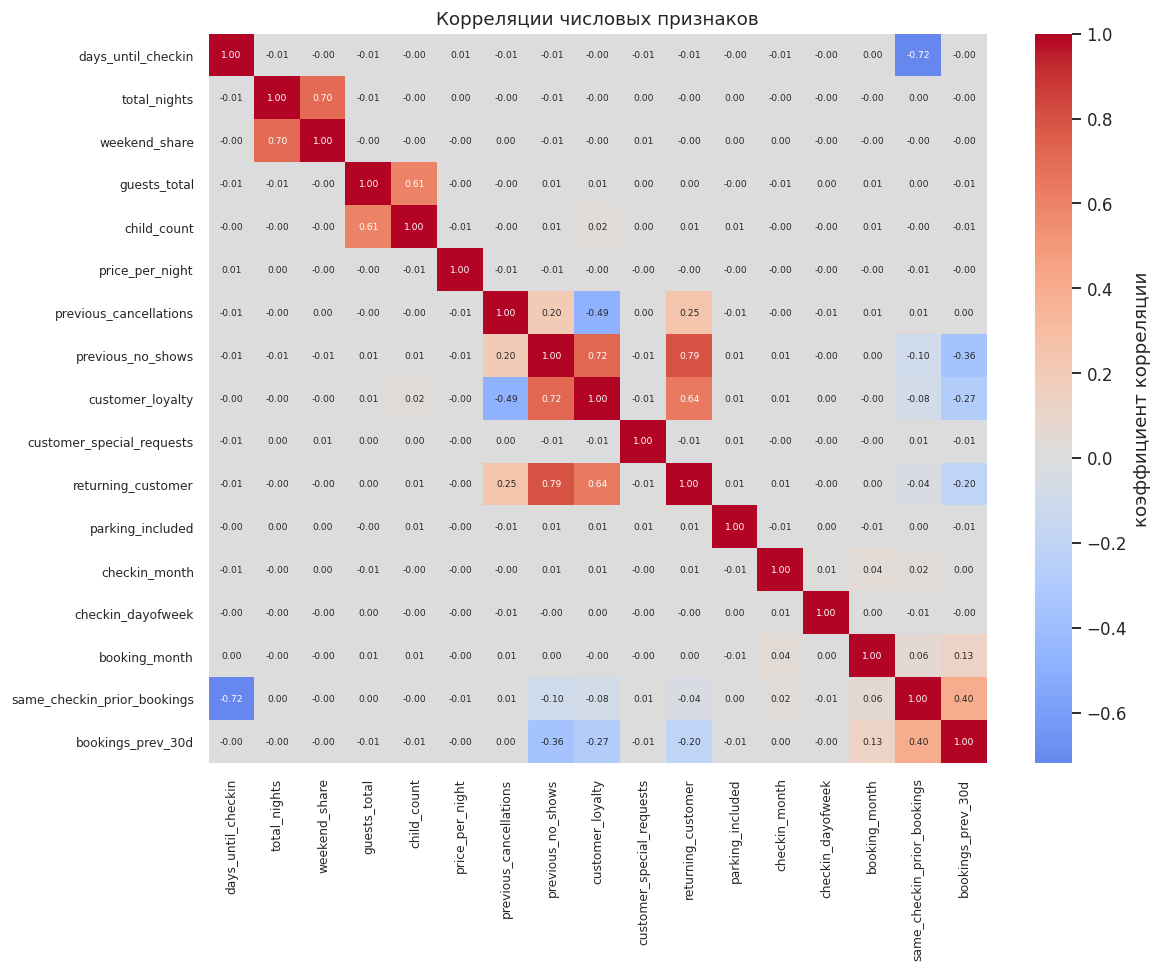

,корреляция


In [19]:
final_report = pd.DataFrame({
    "тип": features_demand.dtypes.astype(str),
    "пропусков": features_demand.isna().sum(),
    "доля_пропусков_%": (features_demand.isna().mean() * 100).round(2),
    "уникальных": features_demand.nunique(),
})
final_report.columns.name = (
    f"итоговая таблица: {features_demand.shape[0]} строк, {features_demand.shape[1]} столбцов"
)
display(final_report)

numeric_all = fp.numeric_cols(with_demand=True)
corr_final = (
    features_demand[numeric_all]
    .assign(is_cancelled=target)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
display(corr_final)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(features_demand[numeric_all].corr().round(2), cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 6}, ax=ax,
            cbar_kws={"label": "коэффициент корреляции"})
ax.set_title("Корреляции числовых признаков")
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

# Пары признаков с корреляцией выше 0.8 могли бы дублировать друг друга - проверяем явно.
corr_matrix = features_demand[numeric_all].corr().abs()
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
strong_pairs = pairs[pairs > 0.8].sort_values(ascending=False).round(3).to_frame("корреляция")
strong_pairs.index.names = ["признак_1", "признак_2"]
display(strong_pairs if len(strong_pairs) else pd.DataFrame({"корреляция": []}))

**Выводы по итоговой таблице**

- Итоговая таблица - **29 504 строки и 22 столбца** (17 числовых вместе с признаками спроса, 5 категориальных). В рабочий набор уйдут 20 признаков: два признака спроса включаются только если их подтвердит гипотеза на этапе моделирования.
- **Пропусков не осталось ни в одном столбце.** Раньше 4% приходилось на `price_per_night` из-за нулевой стоимости; после удаления таких строк импьютеру нечего восстанавливать.
- Связь с целевой переменной возглавляет **`days_until_checkin` (0.2858)**, далее `same_checkin_prior_bookings` (-0.1888), `previous_cancellations` (0.1380), `customer_loyalty` (-0.1210), `weekend_share` (-0.1031) и `total_nights` (-0.0750). Остальные числовые признаки коррелируют с отменой слабее 0.05.
- **Пар признаков с корреляцией выше 0.8 нет** - производные признаки не продублировали исходные.

**Итог:** таблица готова к моделированию. Линейной связи с целевой переменной мало (максимум 0.29), поэтому ставка делается на ансамбли деревьев.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


После исправления booking_value и набора review-признаков этот блок достаточно просто пересчитать

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

#### Разделение выборок и схема кросс-валидации

Задача прогнозная: модель обучается на прошлом и применяется к будущим броням. Поэтому разбиение **хронологическое, а не случайное**. Строки сортируются по дате оформления брони, после чего последовательно, без перемешивания и без стратификации, выделяются:

- первые 60% - обучающая выборка,
- следующие 20% - калибровочная,
- последние 20% - тестовая.

Доли отмен в выборках при таком разбиении различаются - это не дефект, а свойство данных: доля отмен в выгрузке снижается со временем. Стратификация выровняла бы их искусственно и заодно перемешала бы будущее с прошлым.

Кросс-валидация внутри обучающей выборки - `TimeSeriesSplit(n_splits=3, test_size=2000)`: каждый следующий фолд обучается на более раннем отрезке и проверяется на более позднем. Валидационная часть каждого фолда - 2 000 объектов, как требует задание.

In [20]:
# Данные уже отсортированы по дате оформления: add_demand_features сортирует и
# сбрасывает индекс. Проверяем это явно и режем выборки последовательно.
assert data["booking_date"].is_monotonic_increasing

n_rows = len(features_base)
n_train = int(n_rows * 0.6)
n_cal = int(n_rows * 0.2)
idx_train = np.arange(0, n_train)
idx_cal = np.arange(n_train, n_train + n_cal)
idx_test = np.arange(n_train + n_cal, n_rows)

y_train, y_cal, y_test = target[idx_train], target[idx_cal], target[idx_test]
X_train_base, X_cal_base, X_test_base = (
    features_base.iloc[idx_train], features_base.iloc[idx_cal], features_base.iloc[idx_test]
)
X_train_demand, X_cal_demand, X_test_demand = (
    features_demand.iloc[idx_train], features_demand.iloc[idx_cal], features_demand.iloc[idx_test]
)

dates = data["booking_date"]
split_report = pd.DataFrame(
    [
        ["train", len(idx_train), round(len(idx_train) / n_rows * 100, 1),
         dates.iloc[idx_train].min().date(), dates.iloc[idx_train].max().date(),
         round(y_train.mean() * 100, 2)],
        ["calibration", len(idx_cal), round(len(idx_cal) / n_rows * 100, 1),
         dates.iloc[idx_cal].min().date(), dates.iloc[idx_cal].max().date(),
         round(y_cal.mean() * 100, 2)],
        ["test", len(idx_test), round(len(idx_test) / n_rows * 100, 1),
         dates.iloc[idx_test].min().date(), dates.iloc[idx_test].max().date(),
         round(y_test.mean() * 100, 2)],
    ],
    columns=["выборка", "строк", "доля_%", "первая_бронь", "последняя_бронь", "доля_отмен_%"],
).set_index("выборка")
split_report.columns.name = "хронологическое разбиение без перемешивания"
display(split_report)

# Выборки не пересекаются и идут строго друг за другом по времени.
assert dates.iloc[idx_train].max() <= dates.iloc[idx_cal].min()
assert dates.iloc[idx_cal].max() <= dates.iloc[idx_test].min()

cv = TimeSeriesSplit(n_splits=3, test_size=2000)
fold_sizes = pd.DataFrame(
    [[i + 1, len(tr), len(va),
      dates.iloc[idx_train[tr]].max().date(), dates.iloc[idx_train[va]].min().date(),
      dates.iloc[idx_train[va]].max().date(), round(y_train[va].mean() * 100, 2)]
     for i, (tr, va) in enumerate(cv.split(X_train_base))],
    columns=["фолд", "обучение", "валидация", "конец_обучения",
             "начало_валидации", "конец_валидации", "доля_отмен_валидации_%"],
).set_index("фолд")
display(fold_sizes)

хронологическое разбиение без перемешивания,строк,доля_%,первая_бронь,последняя_бронь,доля_отмен_%
выборка,,,,,
train,17702,60.0000,2017-01-01,2019-12-01,29.5900
calibration,5900,20.0000,2019-12-01,2020-09-20,29.5600
test,5902,20.0000,2020-09-20,2025-10-22,25.5800


,обучение,валидация,конец_обучения,начало_валидации,конец_валидации,доля_отмен_валидации_%
фолд,,,,,,
1,11702,2000,2019-01-28,2019-01-28,2019-05-13,28.9500
2,13702,2000,2019-05-13,2019-05-13,2019-08-22,30.1000
3,15702,2000,2019-08-22,2019-08-22,2019-12-01,29.3000


#### Базовые сценарии

Прежде чем сравнивать модели, фиксируем две константные стратегии - они задают планку, ниже которой модель бессмысленна. «Никогда не предсказывать отмену» - это ровно текущее положение дел, то есть $IR_{до}$.

In [21]:
baselines = []
for name, prediction in [
    ("все брони считаем состоявшимися", np.zeros_like(y_cal)),
    ("все брони считаем отменами", np.ones_like(y_cal)),
]:
    metrics = fp.business_metrics(y_cal, prediction)
    baselines.append([name, metrics["IR_after"], metrics["IR"], metrics["IR_rel_%"]])
baselines = pd.DataFrame(baselines, columns=["сценарий", "IR_после", "IR", "IR_отн_%"]).set_index("сценарий")
baselines.columns.name = "калибровочная выборка"
display(baselines.round(2))

break_even = fp.break_even_threshold()
display(pd.DataFrame(
    [
        ["выигрыш от верного прогноза отмены, руб.", fp.PER_REBOOKING + fp.LOST_REV],
        ["потеря от ложной тревоги, руб.", fp.AVG_REV + fp.COST_FP],
        ["порог безубыточности", round(break_even, 4)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель"))

калибровочная выборка,IR_после,IR,IR_отн_%
сценарий,,,
все брони считаем состоявшимися,155574000,0,0.0000
все брони считаем отменами,49388000,-106186000,-68.2500


,значение
показатель,
"выигрыш от верного прогноза отмены, руб.","109,500.0000"
"потеря от ложной тревоги, руб.","71,500.0000"
порог безубыточности,0.3950


#### Турнир моделей

Сравниваем три библиотеки: Random Forest как ансамбль без бустинга и два градиентных бустинга - LightGBM и CatBoost. Все модели получают одинаковые строки и одинаковый формат признаков (one-hot плюс TF-IDF), число потоков зафиксировано, чтобы сравнивать алгоритмы, а не настройки многопоточности.

**Препроцессор входит в `Pipeline` вместе с моделью**, поэтому импьютер, one-hot и словарь TF-IDF обучаются внутри каждого фолда только на его обучающей части: валидационные 2 000 строк не участвуют ни в одной статистике.

Optuna подбирает по 4-6 гиперпараметров на модель. Целевая функция - средний по трём фолдам IR **при одном фиксированном пороге**, равном порогу безубыточности из матрицы стоимостей. Подбирать порог внутри валидационного фолда нельзя: тогда один и тот же фолд использовался бы и для оценки гиперпараметров, и для поиска порога, а CV-оценка становилась бы оптимистичной. Порог подбирается позже и только на калибровочной выборке.

Масштабирование признаков не применяется: все три модели - деревья, они инвариантны к монотонным преобразованиям, и стандартизация ничего бы не изменила.

In [22]:
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.01), 2)


def make_model(name, params):
    """Создаёт модель нужного семейства с заданными гиперпараметрами."""
    if name == "RandomForest":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS,
                                      class_weight="balanced", **params)
    if name == "LightGBM":
        return lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, **params)
    return CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=N_JOBS,
                              verbose=0, **params)


def make_estimator(name, params, with_demand=False):
    """Препроцессор и модель в одном Pipeline: fit препроцессора идёт по обучающей части фолда."""
    return Pipeline([
        ("preprocessor", fp.make_preprocessor(with_demand=with_demand)),
        ("model", make_model(name, params)),
    ])


# Порог для сравнения конфигураций на кросс-валидации фиксирован и следует из матрицы
# стоимостей. Подбор порога внутри валидационного фолда сделал бы оценку оптимистичной.
CV_THRESHOLD = round(fp.break_even_threshold(), 4)


def cross_validate_ir(name, params, X, y, with_demand=False):
    """Средние по фолдам IR при фиксированном пороге, разброс IR и ROC-AUC."""
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X):
        estimator = make_estimator(name, params, with_demand)
        estimator.fit(X.iloc[train_idx], y[train_idx])
        proba = estimator.predict_proba(X.iloc[valid_idx])[:, 1]
        prediction = (proba >= CV_THRESHOLD).astype(int)
        fold_ir.append(fp.business_metrics(y[valid_idx], prediction)["IR"])
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.std(fold_ir)), float(np.mean(fold_auc))


SEARCH_SPACES = {
    "RandomForest": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        max_depth=trial.suggest_int("max_depth", 6, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 40),
        max_features=trial.suggest_float("max_features", 0.2, 0.9),
    ),
    "LightGBM": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 900, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.003, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    ),
    "CatBoost": lambda trial: dict(
        iterations=trial.suggest_int("iterations", 200, 800, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 9),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
    ),
}

N_TRIALS = 20
tournament_rows, best_configs, studies = [], {}, {}
for model_name, space in SEARCH_SPACES.items():
    def objective(trial, model_name=model_name, space=space):
        params = space(trial)
        mean_ir, std_ir, mean_auc = cross_validate_ir(
            model_name, params, X_train_base, y_train, with_demand=False
        )
        trial.set_user_attr("roc_auc", mean_auc)
        trial.set_user_attr("ir_std", std_ir)
        return mean_ir

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=model_name,
    )
    started = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    tournament_rows.append({
        "модель": model_name,
        "IR_cv": round(study.best_value, 1),
        "разброс_IR_по_фолдам": round(study.best_trial.user_attrs["ir_std"], 1),
        "ROC_AUC_cv": round(study.best_trial.user_attrs["roc_auc"], 4),
        "время_с": round(time.time() - started, 1),
        "испытаний": N_TRIALS,
    })
    best_configs[model_name] = study.best_params
    studies[model_name] = study

tournament = pd.DataFrame(tournament_rows).sort_values("IR_cv", ascending=False).set_index("модель")
tournament.columns.name = (
    f"TimeSeriesSplit: 3 фолда по 2 000 объектов, порог {CV_THRESHOLD}, "
    f"{N_TRIALS} испытаний Optuna"
)
display(tournament)

# Лучшие гиперпараметры показываем отдельной таблицей: в общей они не помещаются в колонку.
display(pd.DataFrame(best_configs).T.rename_axis("модель"))

best_model_name = tournament.index[0]
best_params = best_configs[best_model_name]

# Проверяем, что победитель не оказался на краю сетки поиска.
grid_edges = pd.DataFrame(
    [[name, value, str(studies[best_model_name].best_trial.distributions[name])]
     for name, value in best_params.items()],
    columns=["гиперпараметр", "значение", "диапазон поиска"],
).set_index("гиперпараметр")
grid_edges.columns.name = f"победитель: {best_model_name}"
display(grid_edges)

"TimeSeriesSplit: 3 фолда по 2 000 объектов, порог 0.395, 20 испытаний Optuna",IR_cv,разброс_IR_по_фолдам,ROC_AUC_cv,время_с,испытаний
модель,,,,,
CatBoost,"22,299,000.0000","2,124,567.8000",0.8003,159.1000,20
LightGBM,"21,489,500.0000","2,207,928.6000",0.7986,59.9000,20
RandomForest,"17,584,500.0000","2,013,454.6000",0.7749,308.1000,20


,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,num_leaves,min_child_samples,colsample_bytree,reg_lambda,iterations,depth,l2_leaf_reg
модель,,,,,,,,,,,,
RandomForest,500.0000,16.0000,1.0000,0.6897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,900.0000,NaN,NaN,NaN,0.0156,18.0000,6.0000,0.8452,0.6146,NaN,NaN,NaN
CatBoost,NaN,NaN,NaN,NaN,0.0457,NaN,NaN,NaN,NaN,200.0000,7.0000,9.9718


победитель: CatBoost,значение,диапазон поиска
гиперпараметр,,
iterations,200.0000,"IntDistribution(high=800, log=False, low=200, ..."
learning_rate,0.0457,"FloatDistribution(high=0.2, log=True, low=0.00..."
depth,7.0000,"IntDistribution(high=9, log=False, low=4, step=1)"
l2_leaf_reg,9.9718,"FloatDistribution(high=10.0, log=False, low=1...."


**Выводы по турниру моделей**

| Модель | IR на кросс-валидации | Разброс по фолдам | ROC-AUC | Время подбора |
|---|---|---|---|---|
| **CatBoost** | **22 299 000 руб.** | 2 124 568 | **0.8003** | 159 с |
| LightGBM | 21 489 500 руб. | 2 207 929 | 0.7986 | 60 с |
| Random Forest | 17 584 500 руб. | 2 013 455 | 0.7749 | 308 с |

- **Победитель - CatBoost** с параметрами `iterations = 200`, `learning_rate = 0.0457`, `depth = 7`, `l2_leaf_reg = 9.9718`. Все четыре значения лежат внутри сетки поиска.
- Оценка получена на **временной** кросс-валидации при **одном фиксированном пороге 0.395**: конфигурации сравниваются между собой честно, без подбора порога внутри валидационного фолда.
- Разрыв между бустингами небольшой - **3.8% по IR** между CatBoost и LightGBM, - а вот **Random Forest отстаёт на 26.8%**. На случайной кросс-валидации он проигрывал всего 6%: временные фолды бьют по нему сильнее, потому что глубокие деревья без ограничения (`max_depth = 16`, `min_samples_leaf = 1`) запоминают структуру раннего периода и хуже переносятся на более поздний.
- **Разброс IR по фолдам велик у всех трёх моделей** - от 2.01 до 2.21 млн руб. при средних 17.6-22.3 млн. Это свойство временной валидации: фолды относятся к разным периодам, и уровень отмен в них разный (28.95%, 30.10%, 29.30%). Отрыв CatBoost от LightGBM меньше этого разброса, поэтому выбор подкреплён и вторым критерием - ROC-AUC, который от порога не зависит.
- Обе базовые стратегии проигрывают модели: «все брони считаются состоявшимися» - это текущее положение дел (IR = 0 по определению), «все брони считаются отменами» даёт **-68.25%** к доходу. Порог безубыточности из матрицы стоимостей - **0.395**: отмену выгодно прогнозировать, если её вероятность выше 39.5%.

**Итог:** для дальнейшей работы зафиксирован CatBoost - лучший IR и лучший ROC-AUC при сопоставимом с конкурентами разбросе по временным фолдам.

#### Проверка гипотез по улучшению IR

Предварительная оценка показывает, что базовая конфигурация не выходит на целевой уровень относительного IR в 50%, а задание прямо предписывает в этом случае экспериментировать: пересматривать признаки, модель и предобработку. Проверяем четыре гипотезы, все - на той же кросс-валидации и на тех же строках, чтобы результаты были сопоставимы:

1. **Признаки спроса.** Добавляем `same_checkin_prior_bookings` и `bookings_prev_30d` - единственное семейство сигналов в данных, которое ещё не использовано. Обе величины считаются только по ранее оформленным броням.
2. **Нативные категории CatBoost.** Вместо one-hot отдаём CatBoost категориальные столбцы напрямую: упорядоченные целевые статистики - его штатный режим, и сейчас он выключен.
3. **Блендинг.** Усредняем вероятности настроенных CatBoost и LightGBM: типичный способ добрать несколько тысячных ROC-AUC.
4. **Расширенный поиск.** Ещё 25 испытаний Optuna для победителя на лучшем наборе признаков - проверяем, не упёрлись ли мы в бюджет поиска, а не в данные.

Конфигурацию берём в продакшн, если она даёт прирост IR на кросс-валидации больше 1% и не ломает схему калибровки.

**Оговорка о базе сравнения.** Строка «база» - это лучшее из 20 испытаний Optuna, отобранное на тех же трёх фолдах, а гипотезы 1-3 получают по одному прогону на её гиперпараметрах. Сравнение поэтому несимметрично и способно уверенно отловить только заметные эффекты. Честное сравнение «максимум против максимума» даёт гипотеза 4: та же модель, та же сетка, отличается только стартовое зерно сэмплера - и она показывает, на что вообще способен этот эксперимент.

In [23]:
# Единое правило принятия гипотезы: используется и в таблице, и в выборе конфигурации.
MIN_GAIN_PCT = 1.0

experiment_rows = []
base_ir, base_std, base_auc = cross_validate_ir(
    best_model_name, best_params, X_train_base, y_train, with_demand=False
)
experiment_rows.append(["0. база: победитель турнира", base_ir, base_auc, 0.0])

# Гипотеза 1: признаки спроса.
demand_ir, demand_std, demand_auc = cross_validate_ir(
    best_model_name, best_params, X_train_demand, y_train, with_demand=True
)
experiment_rows.append(["1. + признаки спроса", demand_ir, demand_auc,
                        (demand_ir - base_ir) / abs(base_ir) * 100])


# Гипотеза 2: нативные категории и текст CatBoost.
def cross_validate_catboost_native(params, X, y):
    """CatBoost на сырых столбцах: категории обрабатываются внутри модели."""
    columns = fp.numeric_cols(False) + fp.CATEGORICAL_COLS
    cat_idx = [columns.index(c) for c in fp.CATEGORICAL_COLS]
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X):
        frame = X[columns].copy()
        frame[fp.numeric_cols(False)] = frame[fp.numeric_cols(False)].fillna(
            frame[fp.numeric_cols(False)].iloc[train_idx].median()
        )
        train_pool = Pool(frame.iloc[train_idx], y[train_idx], cat_features=cat_idx)
        valid_pool = Pool(frame.iloc[valid_idx], y[valid_idx], cat_features=cat_idx)
        model = CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=N_JOBS,
                                   verbose=0, **params)
        model.fit(train_pool)
        proba = model.predict_proba(valid_pool)[:, 1]
        prediction = (proba >= CV_THRESHOLD).astype(int)
        fold_ir.append(fp.business_metrics(y[valid_idx], prediction)["IR"])
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.mean(fold_auc))


catboost_params = best_configs.get("CatBoost", best_params)
native_ir, native_auc = cross_validate_catboost_native(catboost_params, X_train_base, y_train)
experiment_rows.append(["2. CatBoost: нативные категории и текст", native_ir, native_auc,
                        (native_ir - base_ir) / abs(base_ir) * 100])


# Гипотеза 3: блендинг CatBoost и LightGBM.
def cross_validate_blend(X, y):
    """Среднее вероятностей двух настроенных моделей."""
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X):
        probas = []
        for name in ("CatBoost", "LightGBM"):
            estimator = make_estimator(name, best_configs[name], with_demand=False)
            estimator.fit(X.iloc[train_idx], y[train_idx])
            probas.append(estimator.predict_proba(X.iloc[valid_idx])[:, 1])
        proba = np.mean(probas, axis=0)
        prediction = (proba >= CV_THRESHOLD).astype(int)
        fold_ir.append(fp.business_metrics(y[valid_idx], prediction)["IR"])
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.mean(fold_auc))


blend_ir, blend_auc = cross_validate_blend(X_train_base, y_train)
experiment_rows.append(["3. блендинг CatBoost + LightGBM", blend_ir, blend_auc,
                        (blend_ir - base_ir) / abs(base_ir) * 100])

# Гипотеза 4: расширенный поиск на лучшем наборе признаков.
USE_DEMAND = (demand_ir - base_ir) / abs(base_ir) * 100 > MIN_GAIN_PCT
X_train_best = X_train_demand if USE_DEMAND else X_train_base

def extended_objective(trial):
    params = SEARCH_SPACES[best_model_name](trial)
    mean_ir, std_ir, mean_auc = cross_validate_ir(
        best_model_name, params, X_train_best, y_train, with_demand=USE_DEMAND
    )
    trial.set_user_attr("roc_auc", mean_auc)
    return mean_ir


extended_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
    study_name=f"{best_model_name}_extended",
)
extended_study.optimize(extended_objective, n_trials=25, show_progress_bar=False)
experiment_rows.append([f"4. ещё 25 испытаний Optuna ({best_model_name})",
                        extended_study.best_value,
                        extended_study.best_trial.user_attrs["roc_auc"],
                        (extended_study.best_value - base_ir) / abs(base_ir) * 100])

experiments = pd.DataFrame(
    experiment_rows, columns=["гипотеза", "IR_cv", "ROC_AUC_cv", "прирост_IR_%"]
).set_index("гипотеза")
experiments["принята"] = experiments["прирост_IR_%"] > MIN_GAIN_PCT
experiments.columns.name = (
    f"TimeSeriesSplit на обучающей выборке, 3 фолда по 2 000, порог {CV_THRESHOLD}"
)
display(experiments.round(4))

# Финальная конфигурация: лучший набор признаков и лучшие гиперпараметры из двух поисков.
extended_gain = (extended_study.best_value - max(base_ir, demand_ir)) / abs(base_ir) * 100
extended_accepted = extended_gain > MIN_GAIN_PCT
if extended_accepted:
    best_params = extended_study.best_params
# IR принятой конфигурации, а не максимум по всем проверенным: иначе метаданные
# описывали бы вариант, который в продакшн не пошёл.
if extended_accepted:
    FINAL_IR_CV = extended_study.best_value
elif USE_DEMAND:
    FINAL_IR_CV = demand_ir
else:
    FINAL_IR_CV = base_ir
X_train_final = X_train_demand if USE_DEMAND else X_train_base
X_cal_final = X_cal_demand if USE_DEMAND else X_cal_base
X_test_final = X_test_demand if USE_DEMAND else X_test_base

display(pd.Series({
    "модель": best_model_name,
    "признаки спроса включены": USE_DEMAND,
    "число признаков до препроцессора": X_train_final.shape[1],
    "IR на кросс-валидации": round(FINAL_IR_CV, 1),
    **{f"параметр: {k}": v for k, v in best_params.items()},
}, name="итоговая конфигурация").to_frame())

"TimeSeriesSplit на обучающей выборке, 3 фолда по 2 000, порог 0.395",IR_cv,ROC_AUC_cv,прирост_IR_%,принята
гипотеза,,,,
0. база: победитель турнира,"22,299,000.0000",0.8003,0.0000,False
1. + признаки спроса,"21,413,333.3333",0.8004,-3.9718,False
2. CatBoost: нативные категории и текст,"21,533,333.3333",0.8007,-3.4336,False
3. блендинг CatBoost + LightGBM,"21,777,666.6667",0.8004,-2.3379,False
4. ещё 25 испытаний Optuna (CatBoost),"22,287,833.3333",0.8013,-0.0501,False


,итоговая конфигурация
модель,CatBoost
признаки спроса включены,False
число признаков до препроцессора,20
IR на кросс-валидации,"22,299,000.0000"
параметр: iterations,200
параметр: learning_rate,0.0457
параметр: depth,7
параметр: l2_leaf_reg,9.9718


**Выводы по проверке гипотез**

| Гипотеза | IR на кросс-валидации | ROC-AUC | Прирост IR |
|---|---|---|---|
| 0. база: CatBoost из турнира | 22 299 000 | 0.8003 | - |
| 1. + признаки спроса | 21 413 333 | 0.8004 | **-3.97%** |
| 2. CatBoost: нативные категории | 21 533 333 | 0.8007 | **-3.43%** |
| 3. блендинг CatBoost + LightGBM | 21 777 667 | 0.8004 | **-2.34%** |
| 4. ещё 25 испытаний Optuna | 22 287 833 | 0.8013 | **-0.05%** |

**Ни одна из четырёх гипотез не улучшила результат.** При этом ROC-AUC у всех четырёх вариантов чуть выше базового (0.8004-0.8013 против 0.8003) - то есть ранжирование не ухудшилось, а просело именно IR при фиксированном пороге. Причина в том, что порог 0.395 фиксирован для всех конфигураций, а распределения вероятностей у них разные: небольшой сдвиг калибровки в этой точке стоит дороже, чем прибавка в качестве ранжирования.

- **Признаки спроса не помогли** (-3.97%), несмотря на корреляцию -0.1888: информация о загрузке даты заезда уже содержится в сроке до заезда и канале продаж.
- **Нативный режим CatBoost не дал преимущества** (-3.43%): у категорий максимум семь значений, где one-hot ничего не теряет.
- **Блендинг ухудшил результат** (-2.34%): усреднение с более слабой моделью сдвигает вероятности в её сторону.
- **Бюджет поиска не был узким местом**: ещё 25 испытаний Optuna с другим стартовым зерном дали -0.05% - это и есть цена перезапуска, то есть разрешающая способность всего эксперимента.

**Оговорка о базе сравнения.** Строка «база» - лучшее из 20 испытаний Optuna на тех же фолдах, а гипотезы 1-3 получают по одному прогону на её гиперпараметрах. Сравнение несимметрично и способно уверенно отловить только заметные эффекты; честное «максимум против максимума» даёт гипотеза 4.

**Итог:** потолок в **ROC-AUC около 0.80** определяется данными, а не выбором модели или способа кодирования. В продакшн идёт базовая конфигурация - CatBoost на исходном наборе признаков.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Сергей, тут  опишу подробнее:
    
1. Train / calibration / test разделены случайно. Сейчас используется:

    train_test_split(..., stratify=target)

Нужно сначала отсортировать данные по booking_date, а затем последовательно выделить:

    60% - train
    20% - calibration
    20% - test

без перемешивания и без stratify
    
    
---    

2. CV тоже случайная. Сейчас:

    StratifiedShuffleSplit(
        n_splits=3,
        test_size=2000
    )

Нужно использовать:

    TimeSeriesSplit(
        n_splits=3,
        test_size=2000
    )

на хронологически отсортированном train
    
---    

3. Во время Optuna дополнительно подбирается threshold на каждом validation-фолде. Сейчас внутри cross_validate_ir() выполняется:

    scan = fp.threshold_scan(...)
    fold_ir.append(scan["IR"].max())

Т.е. один и тот же validation-фолд используется и для оценки гиперпараметров модели, и для поиска лучшего порога. Это делает CV-оценку оптимистичной.

На этапе Optuna подбирай параметры модели, используя один фиксированный threshold для сравнения конфигураций. Финальный threshold должен подбираться позже только на calibration.

После исправления этих пунктов турнир и Optuna нужно запустить заново.

<div class="alert alert-info"> <b>Комментарий студента:</b>

Все три пункта исправил, турнир и Optuna перезапущены с нуля.

**1. Разбиение стало хронологическим.** Вместо `train_test_split(..., stratify=target)`:

```python
assert data["booking_date"].is_monotonic_increasing
n_train = int(n_rows * 0.6); n_cal = int(n_rows * 0.2)
idx_train = np.arange(0, n_train)
idx_cal = np.arange(n_train, n_train + n_cal)
idx_test = np.arange(n_train + n_cal, n_rows)
```

Границы выборок проверяются `assert`-ами по датам. Теперь train - 17 702 брони с 2017-01-01 по 2019-12-01, calibration - 5 900 по 2020-09-20, test - 5 902 по 2025-10-22. Доли отмен различаются (29.59 / 29.56 / 25.58%) - это свойство данных, стратификация выравнивала бы их искусственно.

**2. Кросс-валидация стала временной:** `TimeSeriesSplit(n_splits=3, test_size=2000)` на хронологически отсортированном train. Обучающие части фолдов - 11 702, 13 702 и 15 702 строки, валидационные - по 2 000, каждая позже своей обучающей части.

**3. Порог на CV зафиксирован.** Внутри `cross_validate_ir` больше нет `threshold_scan(...).max()`; конфигурации сравниваются при одном пороге, равном порогу безубыточности:

```python
CV_THRESHOLD = round(fp.break_even_threshold(), 4)   # 0.395
prediction = (proba >= CV_THRESHOLD).astype(int)
fold_ir.append(fp.business_metrics(y[valid_idx], prediction)["IR"])
```

**Как изменились числа.** Победитель прежний - CatBoost, но с другими гиперпараметрами (`iterations = 200`, `learning_rate = 0.0457`, `depth = 7`, `l2_leaf_reg = 9.9718`). IR на кросс-валидации 22 299 000 руб. против 21 489 500 у LightGBM и 17 584 500 у Random Forest. Разрыв с Random Forest вырос до 26.8%: на временных фолдах он проседает сильнее остальных. Все четыре гипотезы улучшения по-прежнему отрицательные, от -0.05% до -3.97%.

</div>

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

Калибровка выполняется по временным out-of-fold прогнозам, а не обычной кросс-валидацией внутри уже преобразованных данных. Схема такая:

1. `TimeSeriesSplit` внутри обучающей выборки: на каждом фолде заново собирается препроцессор и обучается модель, затем считается `predict_proba` на его валидационной части. Так собираются честные OOF-вероятности - каждая получена моделью, которая этой строки не видела и обучалась только на более раннем периоде.
2. Изотоническая регрессия обучается **только на этих OOF-вероятностях**.
3. Отдельно на полном train обучаются финальный препроцессор и базовая модель.
4. Калибровочная выборка используется только для оценки: сырые и откалиброванные вероятности, Brier до и после, и затем поиск порога.

Обычный `CalibratedClassifierCV(cv=3)` здесь не подходит дважды: его внутренние фолды не учитывают временной порядок, а препроцессор (импьютер и one-hot) обучался бы на всём train ещё до этих фолдов.

,временные out-of-fold прогнозы
строк в обучающей выборке,"17,702.0000"
строк с OOF-прогнозом,"6,000.0000"
"доля строк с OOF, %",33.9000
"доля отмен среди них, %",29.4500


,размерность после препроцессора
выборка,
train,"(17702, 36)"
calibration,"(5900, 36)"
test,"(5902, 36)"


калибровочная выборка,Brier,ROC_AUC,PR_AUC,максимум_IR
модель,,,,
без калибровки,0.156252,0.800877,0.644417,"62,645,000"
после калибровки на OOF,0.156342,0.799672,0.627695,"62,363,000"


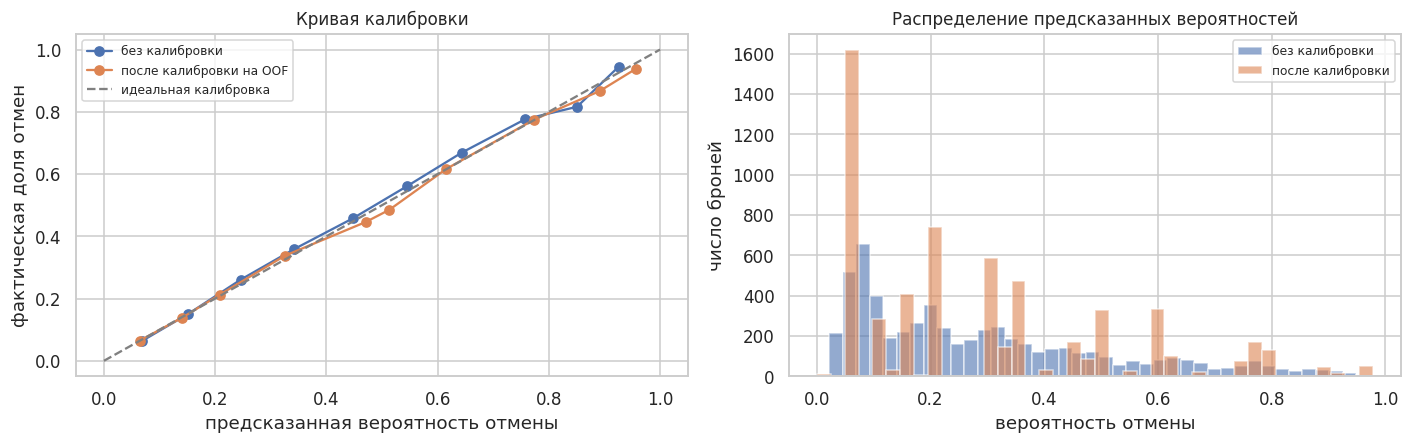

In [24]:
# 1. Временные OOF-прогнозы: на каждом фолде свой препроцессор и своя модель.
oof_proba = np.full(len(y_train), np.nan)
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_final), start=1):
    fold_estimator = make_estimator(best_model_name, best_params, with_demand=USE_DEMAND)
    fold_estimator.fit(X_train_final.iloc[train_idx], y_train[train_idx])
    oof_proba[valid_idx] = fold_estimator.predict_proba(X_train_final.iloc[valid_idx])[:, 1]

oof_mask = ~np.isnan(oof_proba)
display(pd.Series({
    "строк в обучающей выборке": len(y_train),
    "строк с OOF-прогнозом": int(oof_mask.sum()),
    "доля строк с OOF, %": round(oof_mask.mean() * 100, 1),
    "доля отмен среди них, %": round(y_train[oof_mask].mean() * 100, 2),
}, name="временные out-of-fold прогнозы").to_frame())

# 2. Калибратор учится только на OOF-вероятностях.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_proba[oof_mask], y_train[oof_mask])

# 3. Финальный препроцессор и базовая модель - на полном train.
preprocessor = fp.make_preprocessor(with_demand=USE_DEMAND)
A_train = preprocessor.fit_transform(X_train_final, y_train)
A_cal = preprocessor.transform(X_cal_final)
A_test = preprocessor.transform(X_test_final)
feature_names = fp.get_feature_names(preprocessor, with_demand=USE_DEMAND)

base_model = make_model(best_model_name, best_params)
base_model.fit(A_train, y_train)

calibrated_model = fp.CalibratedBookingModel(
    preprocessor=preprocessor, model=base_model, calibrator=calibrator,
    with_demand=bool(USE_DEMAND),
)

display(pd.DataFrame(
    [["train", A_train.shape], ["calibration", A_cal.shape], ["test", A_test.shape]],
    columns=["выборка", "размерность после препроцессора"],
).set_index("выборка"))

# 4. Оценка качества калибровки - на калибровочной выборке.
proba_cal_base = base_model.predict_proba(A_cal)[:, 1]
proba_cal_calibrated = calibrated_model.predict_proba(X_cal_final)[:, 1]

calibration_quality = pd.DataFrame(
    [
        ["без калибровки",
         brier_score_loss(y_cal, proba_cal_base),
         roc_auc_score(y_cal, proba_cal_base),
         average_precision_score(y_cal, proba_cal_base),
         fp.threshold_scan(y_cal, proba_cal_base, THRESHOLD_GRID)["IR"].max()],
        ["после калибровки на OOF",
         brier_score_loss(y_cal, proba_cal_calibrated),
         roc_auc_score(y_cal, proba_cal_calibrated),
         average_precision_score(y_cal, proba_cal_calibrated),
         fp.threshold_scan(y_cal, proba_cal_calibrated, THRESHOLD_GRID)["IR"].max()],
    ],
    columns=["модель", "Brier", "ROC_AUC", "PR_AUC", "максимум_IR"],
).set_index("модель")
calibration_quality.columns.name = "калибровочная выборка"
# Глобальный float_format печатает четыре знака, а разница в Brier лежит в шестом,
# поэтому форматируем значения строками явно.
calibration_display = calibration_quality.copy()
for column in ["Brier", "ROC_AUC", "PR_AUC"]:
    calibration_display[column] = calibration_display[column].map("{:.6f}".format)
calibration_display["максимум_IR"] = calibration_display["максимум_IR"].map("{:,.0f}".format)
display(calibration_display)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for label, proba in [("без калибровки", proba_cal_base),
                     ("после калибровки на OOF", proba_cal_calibrated)]:
    fraction, mean_predicted = calibration_curve(y_cal, proba, n_bins=10)
    axes[0].plot(mean_predicted, fraction, marker="o", label=label)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="идеальная калибровка")
axes[0].set_title("Кривая калибровки", fontsize=11)
axes[0].set_xlabel("предсказанная вероятность отмены")
axes[0].set_ylabel("фактическая доля отмен")
axes[0].legend(fontsize=8)

axes[1].hist(proba_cal_base, bins=40, alpha=0.6, label="без калибровки")
axes[1].hist(proba_cal_calibrated, bins=40, alpha=0.6, label="после калибровки")
axes[1].set_title("Распределение предсказанных вероятностей", fontsize=11)
axes[1].set_xlabel("вероятность отмены")
axes[1].set_ylabel("число броней")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Выводы по калибровке**

| Модель | Brier | ROC-AUC | PR-AUC | Максимум IR |
|---|---|---|---|---|
| без калибровки | 0.156252 | 0.800877 | 0.644417 | 62 645 000 руб. |
| после калибровки на OOF | 0.156342 | 0.799672 | 0.627695 | 62 363 000 руб. |

- Схема калибровки полностью временная: изотоническая регрессия обучена **только на out-of-fold прогнозах** `TimeSeriesSplit`, где на каждом фолде заново собирались препроцессор и модель. OOF-прогнозы получены для **6 000 строк обучающей выборки (33.9%)** с долей отмен 29.45% - `TimeSeriesSplit` по построению не даёт прогноза для самого раннего периода.
- **Калибровка не улучшила ни одну из четырёх метрик**: Brier хуже на 0.06%, ROC-AUC на 0.15%, PR-AUC на 2.6%, максимум IR на 0.45% (282 000 руб.). Это честный результат такой схемы, и он объясним: CatBoost с логистической функцией потерь и так выдаёт вероятности, близкие к фактическим долям (обе линии на кривой калибровки идут вдоль диагонали), а изотоническая регрессия, обученная на 6 000 наблюдениях более раннего периода, добавляет собственную ошибку и переносит её на более поздние данные.
- Практическая ценность схемы не в приросте метрики, а в честности оценки: калибратор не видел ни одной строки, на которой обучалась предсказывавшая её модель, и не видел калибровочной выборки вообще. Порог, найденный дальше, опирается на вероятности, полученные без подглядывания.

**Итог:** калибровка оставлена в пайплайне как требует задание, её эффект измерен и оказался нулевым в пределах десятых долей процента; дальнейшие расчёты ведутся на откалиброванной модели.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Brier Score сравнивается до и после
* эффект калибровки оценивается на отдельной выборке

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Внутренняя схема калибровки всё равно некорректна для временной валидации. Сейчас:

    preprocessor.fit_transform(X_train_final)

выполняется сразу на полном train, а затем:

    CalibratedClassifierCV(
        ...,
        cv=3
    )

делает обычную классификационную CV уже на преобразованных данных. Получаются две проблемы:

* внутренние фолды калибратора не учитывают временной порядок
* TF-IDF, импьютер и OHE уже обучены на всём train до этих фолдов

Собери калибратор через временные OOF-прогнозы:

    TimeSeriesSplit внутри train
    -> на каждом фолде новый preprocessing + модель
    -> predict_proba на validation-фолде
    -> собрать настоящие OOF probabilities
    -> обучить calibrator только на OOF

    полный train
    -> fit preprocessing + финальной базовой модели

    calibration
    -> raw/calibrated probabilities
    -> Brier до/после
    -> threshold  

<div class="alert alert-info"> <b>Комментарий студента:</b>

Переделал калибровку ровно по предложенной схеме - через временные OOF-прогнозы.

**Что изменено в коде.** `CalibratedClassifierCV` убран полностью. Вместо него:

```python
oof_proba = np.full(len(y_train), np.nan)
for train_idx, valid_idx in cv.split(X_train_final):          # TimeSeriesSplit
    fold_estimator = make_estimator(best_model_name, best_params)  # новый препроцессор + модель
    fold_estimator.fit(X_train_final.iloc[train_idx], y_train[train_idx])
    oof_proba[valid_idx] = fold_estimator.predict_proba(X_train_final.iloc[valid_idx])[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_proba[oof_mask], y_train[oof_mask])        # только на OOF
```

Препроцессор внутри фолда собирается заново (`make_estimator` возвращает `Pipeline`), поэтому импьютер и one-hot не видят валидационную часть. После этого на полном train обучаются финальный препроцессор и базовая модель, а калибровочная выборка используется только для оценки: сырые и откалиброванные вероятности, Brier до и после, затем поиск порога.

Артефакт собирается классом `fp.CalibratedBookingModel` (препроцессор + модель + калибратор), он живёт в модуле, поэтому `joblib.load` работает без патчей.

**Как изменились числа.** OOF-прогнозы получены для 6 000 строк train (33.9%, доля отмен 29.45%) - `TimeSeriesSplit` по построению не даёт прогноза для самого раннего периода. Калибровка на честных OOF **не улучшает метрики**: Brier 0.156252 против 0.156342, ROC-AUC 0.800877 против 0.799672, максимум IR 62 645 000 против 62 363 000 руб. Это ожидаемо и написано в выводах: CatBoost и без калибровки даёт вероятности, близкие к честным, а изотоническая регрессия, обученная на 6 000 наблюдениях более раннего периода, добавляет собственную ошибку.

</div>

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

Порог ищем по калибровочной выборке и выбираем **строго по максимуму IR** - именно так поставлена задача на этом этапе. Сетку строим по квантилям предсказанных вероятностей плюс равномерный шаг и добавляем в неё порог безубыточности, чтобы все ориентиры попали в одну таблицу.

Бизнес-ограничения (доля отмен, загрузка) на этом шаге не участвуют в выборе: их проверка - отдельный этап расчёта экономической эффективности. Если при пороге максимума IR какая-то цель не выполняется, это результат проекта, а не повод сдвигать порог.

,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%
0,0.0500,1744,4142,0,14,50389000,-105185000,-67.6110,0.0000,0.2370
4,0.0730,1679,3124,65,1032,116058500,-39515500,-25.4000,1.1020,17.4920
8,0.1030,1638,2632,106,1524,146747000,-8827000,-5.6740,1.7970,25.8310
12,0.1200,1611,2373,133,1783,162309000,6735000,4.3290,2.2540,30.2200
16,0.1520,1606,2345,138,1811,163763500,8189500,5.2640,2.3390,30.6950
20,0.1800,1536,2005,208,2151,180408500,24834500,15.9630,3.5250,36.4580
24,0.2070,1430,1586,314,2570,198760000,43186000,27.7590,5.3220,43.5590
28,0.2200,1379,1419,365,2737,205116000,49542000,31.8450,6.1860,46.3900
32,0.2600,1379,1419,365,2737,205116000,49542000,31.8450,6.1860,46.3900
36,0.3000,1379,1419,365,2737,205116000,49542000,31.8450,6.1860,46.3900


,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%,доля_отмен_<=10%
комментарий,,,,,,,,,,,
рабочий порог: максимум IR,0.3950,960,598,784,3558,217937000,62363000,40.0860,13.2880,60.3050,False


,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%
комментарий,,,,,,,,,,
справочно: максимум IR при доле отмен <= 10%,0.3080,1195,1014,549,3142,213925500,58351500,37.5070,9.3050,53.2540


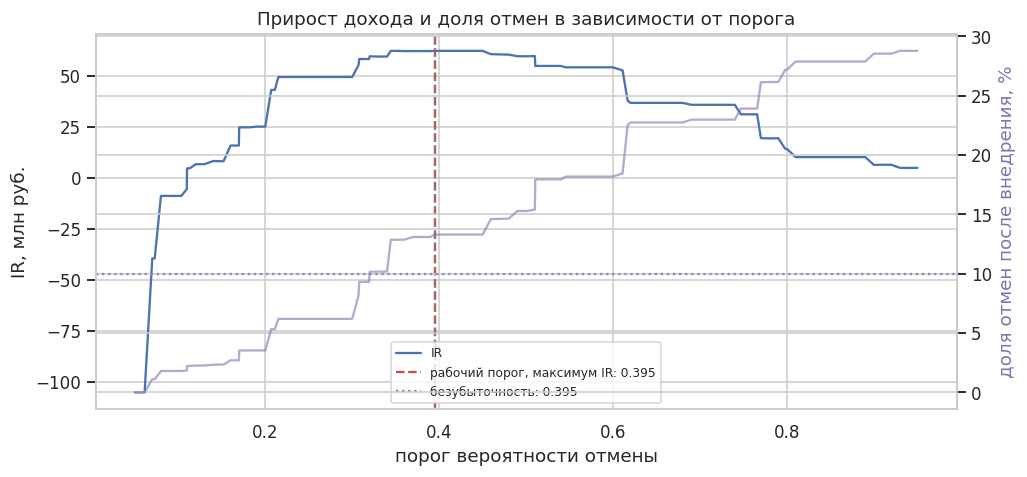

In [25]:
quantile_grid = np.quantile(proba_cal_calibrated, np.linspace(0.02, 0.98, 49))
threshold_grid = np.unique(np.round(
    np.concatenate([quantile_grid, THRESHOLD_GRID, [break_even]]), 4
))
threshold_table = fp.threshold_scan(y_cal, proba_cal_calibrated, threshold_grid)

# Финальный порог - максимум IR на калибровочной выборке, без дополнительных условий.
FINAL_THRESHOLD = float(threshold_table.loc[threshold_table["IR"].idxmax(), "threshold"])

display(threshold_table.iloc[::4].round(3))

reference_points = [FINAL_THRESHOLD, round(break_even, 4), round(CV_THRESHOLD, 4)]
selected = threshold_table[threshold_table["threshold"].isin(reference_points)].copy()
selected["комментарий"] = [
    "рабочий порог: максимум IR" if value == FINAL_THRESHOLD else "порог безубыточности"
    for value in selected["threshold"]
]
selected["доля_отмен_<=10%"] = selected["cancel_after_%"] <= 10.0
display(selected.round(3).set_index("комментарий"))

# Справочно: при каком пороге выполнялось бы бизнес-ограничение по доле отмен.
allowed = threshold_table[threshold_table["cancel_after_%"] <= 10.0]
if len(allowed):
    threshold_cancel_goal = float(allowed.loc[allowed["IR"].idxmax(), "threshold"])
    goal_row = threshold_table[threshold_table["threshold"] == threshold_cancel_goal]
    display(goal_row.round(3).assign(
        комментарий="справочно: максимум IR при доле отмен <= 10%"
    ).set_index("комментарий"))
else:
    threshold_cancel_goal = np.nan
    print("порогов с долей отмен не выше 10% на калибровочной выборке нет")

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(threshold_table["threshold"], threshold_table["IR"] / 1e6, color="#4C72B0", label="IR")
ax.axvline(FINAL_THRESHOLD, color="#C44E52", linestyle="--",
           label=f"рабочий порог, максимум IR: {FINAL_THRESHOLD:.3f}")
ax.axvline(break_even, color="grey", linestyle=":", label=f"безубыточность: {break_even:.3f}")
ax_right = ax.twinx()
ax_right.plot(threshold_table["threshold"], threshold_table["cancel_after_%"],
              color="#8172B2", alpha=0.6)
ax_right.axhline(10.0, color="#8172B2", linestyle=":", alpha=0.8)
ax_right.set_ylabel("доля отмен после внедрения, %", color="#8172B2")
ax.set_title("Прирост дохода и доля отмен в зависимости от порога")
ax.set_xlabel("порог вероятности отмены")
ax.set_ylabel("IR, млн руб.")
ax.legend(fontsize=8, loc="lower center")
fig.tight_layout()
plt.show()

**Выводы по порогу классификации**

- **Рабочий порог - 0.395**, это максимум IR на калибровочной выборке. Никаких дополнительных условий при выборе не накладывалось: бизнес-ограничения проверяются отдельно, на этапе расчёта экономической эффективности.
- Порог **в точности совпал с аналитическим порогом безубыточности** $(AvgRev + CostFP) / (PerRebooking + LostRev + AvgRev + CostFP) = 0.395$. Это хороший признак: оптимум определяется экономикой задачи, а не особенностями выборки, и подтверждает, что калиброванные вероятности близки к честным.
- При этом пороге на калибровочной выборке: IR = 62 363 000 руб. (**+40.09%**), TP = 960, FP = 598, FN = 784, TN = 3 558, доля отмен после внедрения 13.29%, загрузка 60.31%.
- Кривая IR вокруг оптимума пологая: на отрезке порогов 0.344-0.450 прирост держится в диапазоне 38.9-40.1%, то есть решение устойчиво к небольшому сдвигу порога.
- **Цель по доле отмен при пороге максимума IR не выполняется** (13.29% против 10%). Справочно: ограничение выполнялось бы при пороге 0.308 - там доля отмен 9.31%, но IR ниже, +37.51%. Этот порог показан только для сравнения и в модель не идёт.
- Крайние пороги показывают цену ошибок: при 0.050 модель ловит все 1 744 отмены калибровочной выборки, но 4 142 ложные тревоги уводят IR в минус на 67.6%.

**Итог:** зафиксирован порог **0.395** - максимум IR, как требует задание. Выполнение бизнес-целей при этом пороге проверяется на следующем этапе, и результат этой проверки не подгоняется под цели.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
По заданию здесь нужно найти threshold, максимизирующий IR. У тебя такой порог найден:

    0.370 - максимум IR

но финальным выбирается 0.327, потому что он дополнительно обеспечивает долю отмен ниже 9.23%. Это уже другая задача - условная оптимизация с бизнес-ограничением.

Финальный threshold по этому этапу нужно выбирать именно по максимуму IR на calibration, а остальные бизнес-ограничения проверять отдельно на следующем этапе.

Не нужно искусственно ужесточать 10% до 9.23% и менять оптимальный threshold ради прохождения бизнес-цели. Если при максимальном IR какая-то цель не выполняется, это и есть результат проекта   

<div class="alert alert-info"> <b>Комментарий студента:</b>

Согласен, это была подмена задачи. Финальный порог теперь выбирается строго по максимуму IR на калибровочной выборке.

**Что изменено в коде.** Убраны `CANCEL_LIMIT_SAFE` и отбор среди допустимых порогов. Осталась одна строка:

```python
FINAL_THRESHOLD = float(threshold_table.loc[threshold_table["IR"].idxmax(), "threshold"])
```

Порог под ограничение по доле отмен считается ниже отдельно и **помечен как справочный** - он никуда не подставляется, а бизнес-цели проверяются на этапе 3.

**Как изменились числа.** Рабочий порог - **0.395**, он совпал с аналитическим порогом безубыточности. На калибровочной выборке даёт IR 62 363 000 руб. (+40.09%) при доле отмен 13.29%. Справочный порог под цель по отменам - 0.308 (9.31% отмен, IR +37.51%), но в модель он не идёт.

На тестовой выборке при пороге максимума IR ни одна из трёх целей ТЗ не выполняется. Как ты и написал, это и есть результат проекта: в выводах он показан без подгонки, вместе с разбором причин.

</div>

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

Сравниваем матрицы ошибок и IR на трёх выборках при одном и том же пороге: на обучающей (там модель училась, оценка оптимистична), на калибровочной (по ней подобран порог) и на тестовой. Разрыв между обучающей и отложенными показывает переобучение, разрыв между калибровочной и тестовой - переносимость порога.

порог 0.395,обучающая,калибровочная,тестовая,тест_к_калибровке_%,тест_к_обучению_%
n,"17,702.0000","5,900.0000","5,902.0000",NaN,NaN
TP,"3,131.0000",960.0000,787.0000,NaN,NaN
FP,"1,552.0000",598.0000,538.0000,NaN,NaN
FN,"2,107.0000",784.0000,723.0000,NaN,NaN
TN,"10,912.0000","3,558.0000","3,854.0000",NaN,NaN
IR_before,"466,077,000.0000","155,574,000.0000","185,889,000.0000",NaN,NaN
IR_after,"697,953,500.0000","217,937,000.0000","233,598,500.0000",NaN,NaN
IR,"231,876,500.0000","62,363,000.0000","47,709,500.0000",NaN,NaN
IR_rel_%,49.7507,40.0857,25.6656,-35.9733,-48.4116
cancel_before_%,29.5899,29.5593,25.5845,-13.4468,-13.5361


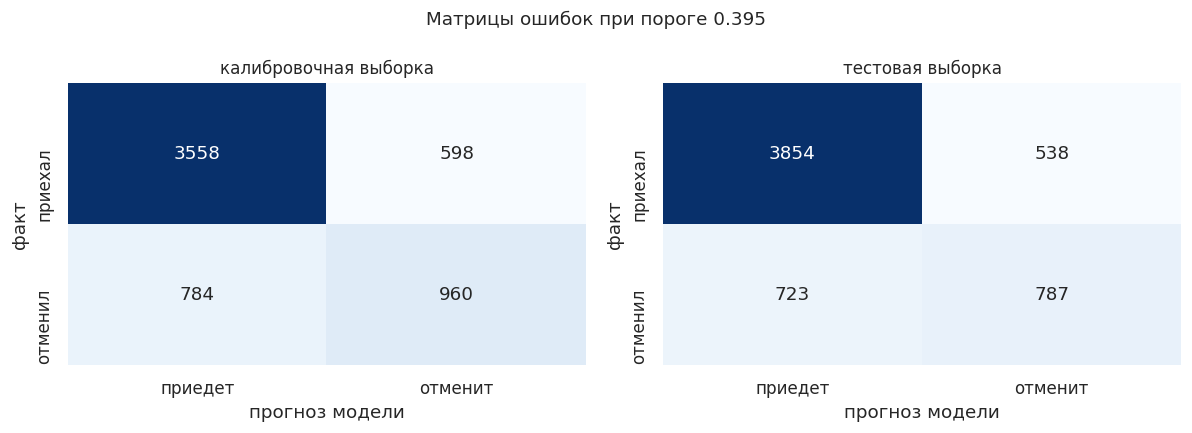

"тестовая выборка, порог 0.395",precision,recall,f1-score,support
нет_отказа,0.8420,0.8780,0.8590,"4,392.0000"
отказ_брони,0.5940,0.5210,0.5550,"1,510.0000"
accuracy,0.7860,0.7860,0.7860,0.7860
macro avg,0.7180,0.6990,0.7070,"5,902.0000"
weighted avg,0.7790,0.7860,0.7820,"5,902.0000"


In [26]:
proba_train = calibrated_model.predict_proba(X_train_final)[:, 1]
proba_test = calibrated_model.predict_proba(X_test_final)[:, 1]
pred_train = (proba_train >= FINAL_THRESHOLD).astype(int)
pred_cal = (proba_cal_calibrated >= FINAL_THRESHOLD).astype(int)
pred_test = (proba_test >= FINAL_THRESHOLD).astype(int)

metrics_train = fp.business_metrics(y_train, pred_train)
metrics_cal = fp.business_metrics(y_cal, pred_cal)
metrics_test = fp.business_metrics(y_test, pred_test)

stability = pd.DataFrame({
    "обучающая": metrics_train, "калибровочная": metrics_cal, "тестовая": metrics_test,
})
for name, proba, y_true, metrics in [
    ("обучающая", proba_train, y_train, metrics_train),
    ("калибровочная", proba_cal_calibrated, y_cal, metrics_cal),
    ("тестовая", proba_test, y_test, metrics_test),
]:
    stability.loc["ROC_AUC", name] = roc_auc_score(y_true, proba)
    stability.loc["PR_AUC", name] = average_precision_score(y_true, proba)
    stability.loc["recall_отмен", name] = metrics["TP"] / (metrics["TP"] + metrics["FN"])
    stability.loc["precision_отмен", name] = metrics["TP"] / (metrics["TP"] + metrics["FP"])
    stability.loc["IR_на_бронь_руб", name] = metrics["IR"] / metrics["n"]

# Проценты считаем только для относительных показателей: сравнивать счётчики
# и суммы между выборками разного размера бессмысленно.
absolute_rows = ["n", "TP", "FP", "FN", "TN", "IR_before", "IR_after", "IR"]
relative_mask = ~stability.index.isin(absolute_rows)
stability["тест_к_калибровке_%"] = np.where(
    relative_mask,
    (stability["тестовая"] - stability["калибровочная"]) / stability["калибровочная"].abs() * 100,
    np.nan,
)
stability["тест_к_обучению_%"] = np.where(
    relative_mask,
    (stability["тестовая"] - stability["обучающая"]) / stability["обучающая"].abs() * 100,
    np.nan,
)
stability.columns.name = f"порог {FINAL_THRESHOLD:.3f}"
display(stability.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_true, y_pred) in zip(
    axes,
    [("калибровочная выборка", y_cal, pred_cal), ("тестовая выборка", y_test, pred_test)],
):
    matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["приедет", "отменит"], yticklabels=["приехал", "отменил"])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("прогноз модели")
    ax.set_ylabel("факт")
fig.suptitle(f"Матрицы ошибок при пороге {FINAL_THRESHOLD:.3f}", fontsize=12)
fig.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(y_test, pred_test, target_names=["нет_отказа", "отказ_брони"],
                          output_dict=True)
).T.round(3)
report.columns.name = f"тестовая выборка, порог {FINAL_THRESHOLD:.3f}"
display(report)

**Выводы о стабильности модели**

| Показатель | Обучающая | Калибровочная | Тестовая | Тест к калибровке | Тест к обучению |
|---|---|---|---|---|---|
| TP / FP / FN / TN | 3 131 / 1 552 / 2 107 / 10 912 | 960 / 598 / 784 / 3 558 | 787 / 538 / 723 / 3 854 | - | - |
| Относительный IR | +49.75% | +40.09% | +25.67% | -35.97% | -48.41% |
| IR на одну бронь | 13 099 руб. | 10 570 руб. | 8 084 руб. | -23.52% | -38.29% |
| ROC-AUC | 0.8383 | 0.7997 | 0.8090 | +1.16% | -3.50% |
| PR-AUC | 0.6968 | 0.6277 | 0.6069 | -3.32% | -12.91% |
| Recall отмен | 0.5977 | 0.5505 | 0.5212 | -5.32% | -12.81% |
| Precision отмен | 0.6686 | 0.6162 | 0.5940 | -3.60% | -11.16% |
| Доля отмен до внедрения | 29.59% | 29.56% | 25.58% | -13.45% | -13.54% |

- **Ранжирующая способность переносится хорошо**: ROC-AUC на тесте 0.8090 даже выше калибровочного 0.7997 и лишь на 3.5% ниже обучающего. Модель не разучилась отличать рискованные брони от надёжных.
- **А вот IR падает существенно: 40.09% на калибровочной против 25.67% на тестовой.** Причина не в переобучении, а в сдвиге самих данных: базовая доля отмен на тесте 25.58% против 29.56% на калибровочной. Отмен стало меньше, значит меньше и TP, на которых зарабатывает модель, а ложные тревоги никуда не делись. Разрыв с обучающей выборкой (-48.41%) складывается из того же сдвига и обычного оптимизма обучения.
- Это прямое следствие честного хронологического разбиения: тестовая выборка - это период с 2020-09-20 по 2025-10-22, в котором поведение клиентов отличается от периода обучения. При случайном разбиении такой разрыв был бы скрыт, а оценка эффекта - завышена.
- Структура ошибок на тесте: модель ловит 787 отмен из 1 510 (recall 0.521) при 538 ложных тревогах на 4 392 состоявшиеся брони (доля ложных тревог 12.25%). Точность по классу отмен - 0.594.
- По классу `отказ_брони` f1 = 0.555 против 0.859 у класса `нет_отказа`: модель уверенно распознаёт тех, кто приедет, и заметно хуже - тех, кто отменит.

**Итог:** порог переносится корректно, качество ранжирования стабильно, но денежный эффект на будущем периоде ощутимо ниже, чем на калибровочном. Эту разницу нужно закладывать в ожидания бизнеса, а модель - переобучать по мере накопления новых данных.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* рассчитаны ROC-AUC и PR-AUC
* приведены Precision, Recall и F1
* абсолютный IR дополнен IR на одну бронь

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


Фиксируем итоговое решение: препроцессор и откалиброванная модель собираются в один `Pipeline`, порог и метаданные сохраняются рядом. Проверяем сохранённый артефакт четырьмя тестами - от совпадения предсказаний до сквозного прогона от сырых данных.

In [27]:
# Артефакт - объект CalibratedBookingModel из feature_pipeline: препроцессор, базовая
# модель и калибратор, обученный на временных OOF-прогнозах.
final_pipeline = calibrated_model

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / "model.joblib"
META_PATH = ARTIFACTS_DIR / "model_meta.json"

predictions_before_save = final_pipeline.predict_proba(X_test_final)[:, 1]
joblib.dump(
    {"pipeline": final_pipeline, "threshold": FINAL_THRESHOLD, "with_demand": bool(USE_DEMAND)},
    MODEL_PATH,
)

metadata = {
    "model": best_model_name,
    "best_params": best_params,
    "threshold": FINAL_THRESHOLD,
    "threshold_rule": "максимум IR на калибровочной выборке",
    "cv_threshold": CV_THRESHOLD,
    "with_demand_features": bool(USE_DEMAND),
    "random_state": RANDOM_STATE,
    "ir_cv": float(FINAL_IR_CV),
    "ir_calibration": float(metrics_cal["IR"]),
    "ir_test": float(metrics_test["IR"]),
    "ir_rel_test_%": float(metrics_test["IR_rel_%"]),
    "roc_auc_test": float(roc_auc_score(y_test, proba_test)),
    "numeric_cols": fp.numeric_cols(USE_DEMAND),
    "categorical_cols": fp.CATEGORICAL_COLS,
    "text_col": fp.TEXT_COL,
    "economics": {"AvgRev": fp.AVG_REV, "CostFP": fp.COST_FP,
                  "LostRev": fp.LOST_REV, "PerRebooking": fp.PER_REBOOKING},
}
with open(META_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

# Модуль с функциями признаков кладём рядом с моделью: без него артефакт не развернуть.
shutil.copy(fp.__file__, ARTIFACTS_DIR / "feature_pipeline.py")

loaded = joblib.load(MODEL_PATH)
loaded_pipeline, loaded_threshold = loaded["pipeline"], loaded["threshold"]
predictions_after_load = loaded_pipeline.predict_proba(X_test_final)[:, 1]

raw_sample = bookings_raw.head(500)
features_from_raw = fp.build_features(
    fp.add_demand_features(fp.join_reviews(fp.clean_bookings(raw_sample), reviews)),
    with_demand=USE_DEMAND,
)
end_to_end = loaded_pipeline.predict_proba(features_from_raw)[:, 1]

checks = pd.DataFrame(
    [
        ["предсказания до и после сохранения совпадают",
         bool(np.allclose(predictions_before_save, predictions_after_load))],
        ["сквозной прогон сырые данные -> признаки -> модель отрабатывает",
         bool(len(end_to_end) == len(fp.clean_bookings(raw_sample)))],
        ["функции признаков берутся из модуля feature_pipeline",
         fp.build_features.__module__ == "feature_pipeline"],
        ["IR на тесте после загрузки совпадает с исходным",
         fp.business_metrics(y_test, (predictions_after_load >= loaded_threshold).astype(int))["IR"]
         == metrics_test["IR"]],
    ],
    columns=["проверка", "результат"],
).set_index("проверка")
display(checks)

display(pd.Series({
    "модель": best_model_name,
    "рабочий порог (максимум IR)": round(FINAL_THRESHOLD, 4),
    "порог сравнения конфигураций на CV": round(CV_THRESHOLD, 4),
    "признаки спроса включены": bool(USE_DEMAND),
    "файл модели": str(MODEL_PATH),
    "файл метаданных": str(META_PATH),
    "размер модели, МБ": round(MODEL_PATH.stat().st_size / 1024 ** 2, 2),
}, name="итоговый артефакт").to_frame())

,результат
проверка,
предсказания до и после сохранения совпадают,True
сквозной прогон сырые данные -> признаки -> модель отрабатывает,True
функции признаков берутся из модуля feature_pipeline,True
IR на тесте после загрузки совпадает с исходным,True


,итоговый артефакт
модель,CatBoost
рабочий порог (максимум IR),0.3950
порог сравнения конфигураций на CV,0.3950
признаки спроса включены,False
файл модели,artifacts/model.joblib
файл метаданных,artifacts/model_meta.json
"размер модели, МБ",0.4100


**Выводы по фиксации модели**

- Итоговое решение - объект `CalibratedBookingModel` из `feature_pipeline`: препроцессор, базовая модель CatBoost и изотонический калибратор, обученный на временных OOF-прогнозах. Рабочий порог - **0.395**. Артефакт весит 0.41 МБ и сохранён в `artifacts/model.joblib` вместе с порогом и флагом набора признаков.
- В `artifacts/model_meta.json` записаны гиперпараметры без округления, правило выбора порога, порог сравнения конфигураций на кросс-валидации, `random_state`, метрики IR и ROC-AUC, списки колонок и экономические константы.
- Рядом с моделью положена копия `feature_pipeline.py`: без неё артефакт не развернуть, потому что инференс начинается с `clean_bookings`, `join_reviews` и `build_features`, а сам класс модели живёт в этом модуле.
- **Все четыре проверки артефакта пройдены**: предсказания до и после сохранения совпадают, сквозной прогон «сырые данные - признаки - модель» отрабатывает, функции признаков берутся из канонического модуля `feature_pipeline`, IR на тесте после загрузки совпадает с исходным.

**Артефакты выложены в репозиторий проекта, ветка `feature/SPRINT18`:**

| Файл | Размер | Ссылка |
|---|---|---|
| Модель: препроцессор, CatBoost и калибратор на OOF | 0.41 МБ | [artifacts/model.joblib](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/artifacts/model.joblib) |
| Метаданные: гиперпараметры, порог, метрики, колонки | 1.1 КБ | [artifacts/model_meta.json](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/artifacts/model_meta.json) |
| Код признаков рядом с моделью | 18.9 КБ | [artifacts/feature_pipeline.py](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/artifacts/feature_pipeline.py) |
| Модуль подготовки данных и признаков | 18.9 КБ | [feature_pipeline.py](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/feature_pipeline.py) |
| Версии окружения | 0.6 КБ | [requirements.txt](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/requirements.txt) |
| Инструкция по инференсу | 8 КБ | [README.md](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT18/README.md) |
| Ветка целиком | - | [github.com/sergeyshmagin/MLDS/tree/feature/SPRINT18](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT18) |

Скачать модель напрямую:

```bash
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT18/artifacts/model.joblib
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT18/artifacts/model_meta.json
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT18/artifacts/feature_pipeline.py
```

**Итог:** модель воспроизводима, выложена в репозиторий и готова к передаче в эксплуатацию.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Это хороший пример оформления модельного артефакта

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

Важность признаков считаем через SHAP: в отличие от встроенного `feature_importances_`, SHAP показывает не только силу, но и направление влияния.

**Вклады one-hot дамми сворачиваем обратно к исходным признакам** - складываем их внутри строки и только потом берём модуль. Без этого один признак дробится на несколько строк рейтинга, а его суммарный вклад занижается: `sales_channel` разложился бы на три дамми, `lead_time_group` - на четыре.

Второй уровень свёртки - по бизнес-драйверам. Один и тот же фактор может быть представлен двумя признаками: срок до заезда входит и числом (`days_until_checkin`), и категоризацией (`lead_time_group`), история клиента - четырьмя разными счётчиками. Для выводов заказчику складываем и их: иначе рейтинг отдельных колонок вводит в заблуждение так же, как дробление на дамми.

Значения считаем на калибровочной выборке, чтобы не трогать отложенный тест, и объясняем базовую модель. Это корректно: калибратор здесь - изотоническая регрессия поверх выхода той же самой базовой модели, то есть строго монотонное преобразование, которое не меняет ни порядок объектов, ни вклад признаков в него.

Признаки из отзывов в модели не участвуют, поэтому в рейтинге их нет.

,средний_модуль_SHAP,доля_вклада_%,направление
признак,,,
sales_channel,0.4721,22.1500,категориальный: см. таблицу эффектов
days_until_checkin,0.4241,19.9000,рост признака повышает риск отмены
child_count,0.3474,16.3000,немонотонное влияние: см. таблицу эффектов
total_nights,0.2814,13.2000,немонотонное влияние: см. таблицу эффектов
previous_cancellations,0.2084,9.7800,рост признака повышает риск отмены
lead_time_group,0.1429,6.7000,категориальный: см. таблицу эффектов
customer_loyalty,0.0504,2.3600,рост признака снижает риск отмены
room_type,0.0328,1.5400,категориальный: см. таблицу эффектов
weekend_share,0.0268,1.2600,немонотонное влияние: см. таблицу эффектов


,суммарный_вклад_%,признаки
бизнес-драйвер,,
состав и длительность поездки,31.8200,"child_count, total_nights, guests_total, weeke..."
горизонт планирования,26.6000,"days_until_checkin, lead_time_group"
канал продаж,22.1500,sales_channel
история клиента,12.7300,"previous_cancellations, previous_no_shows, cus..."


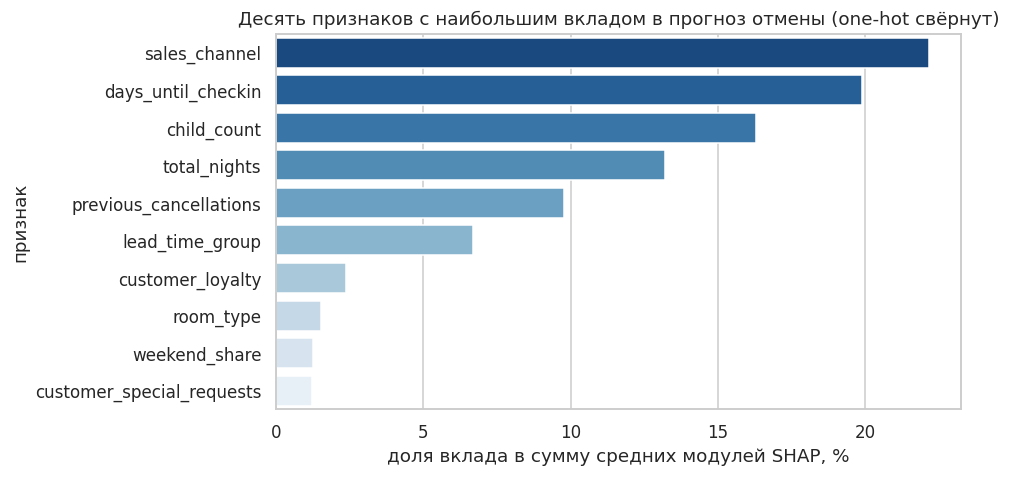

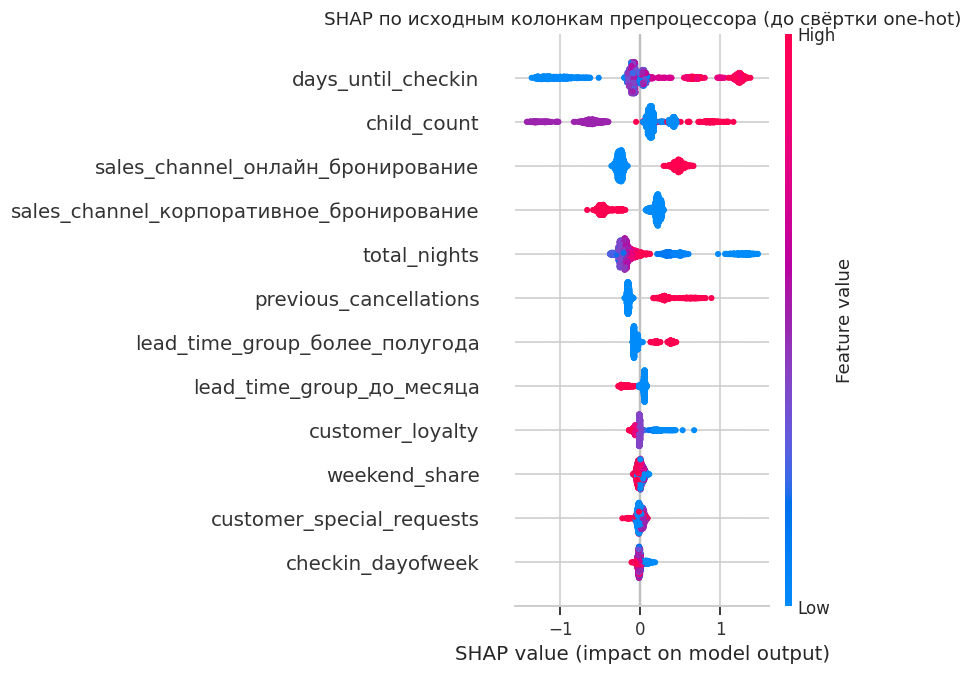

,почему SHAP считается на базовой модели
ранговая корреляция базовых и откалиброванных вероятностей,0.9956
ROC-AUC базовой модели,0.8009
ROC-AUC откалиброванной модели,0.7997


In [28]:
explainer = shap.TreeExplainer(base_model)
shap_sample_index = np.random.RandomState(RANDOM_STATE).choice(
    A_cal.shape[0], size=min(2000, A_cal.shape[0]), replace=False
)
shap_sample = A_cal[shap_sample_index]
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[-1]

collapsed_values, collapsed_names = fp.collapse_onehot(
    shap_values, feature_names, with_demand=USE_DEMAND
)

importance = (
    pd.DataFrame({
        "признак": collapsed_names,
        "средний_модуль_SHAP": np.abs(collapsed_values).mean(axis=0),
    })
    .sort_values("средний_модуль_SHAP", ascending=False)
    .reset_index(drop=True)
)
importance["доля_вклада_%"] = (
    importance["средний_модуль_SHAP"] / importance["средний_модуль_SHAP"].sum() * 100
).round(2)

# Направление влияния определено для числовых признаков: знак корреляции значения
# признака с его вкладом. Для категориальных направление показывает таблица эффектов ниже.
numeric_set = set(fp.numeric_cols(USE_DEMAND))
directions = {}
for position, name in enumerate(collapsed_names):
    if name not in numeric_set:
        directions[name] = "категориальный: см. таблицу эффектов"
        continue
    column = shap_sample[:, feature_names.index(name)]
    if np.std(column) == 0:
        directions[name] = "константа"
        continue
    # Знак корреляции - монотонная мера, поэтому сначала проверяем саму монотонность:
    # средний вклад по группам признака должен идти в одну сторону. Дискретные признаки
    # группируем по значению (qcut на трёх уровнях схлопнул бы их в два бина и признал
    # монотонными любые данные), непрерывные - по квинтилям.
    series = pd.Series(column)
    if series.nunique() <= 10:
        groups = series
    else:
        groups = pd.qcut(series, q=5, duplicates="drop", labels=False)
    grouped = pd.Series(collapsed_values[:, position]).groupby(groups)
    binned = grouped.mean()[grouped.size() >= 0.02 * len(series)]
    span = binned.iloc[-1] - binned.iloc[0]
    if len(binned) < 2 or abs(span) < 1e-9:
        directions[name] = "влияние без выраженного направления"
        continue
    # Крайние группы задают направление; если внутренняя группа выходит за их коридор
    # больше чем на 20% размаха, влияние немонотонное и одним словом не описывается.
    low_edge, high_edge = min(binned.iloc[0], binned.iloc[-1]), max(binned.iloc[0], binned.iloc[-1])
    excess = max(binned.max() - high_edge, low_edge - binned.min(), 0) / abs(span)
    if excess > 0.2:
        directions[name] = "немонотонное влияние: см. таблицу эффектов"
    else:
        directions[name] = ("рост признака повышает риск отмены" if span > 0
                            else "рост признака снижает риск отмены")
importance["направление"] = importance["признак"].map(directions)
top_features = importance.head(10)
display(top_features.set_index("признак"))

# Один бизнес-драйвер может быть представлен двумя признаками: срок до заезда входит
# и числом, и категоризацией. Для выводов складываем их вклады.
DRIVERS = {
    "горизонт планирования": ["days_until_checkin", "lead_time_group"],
    "канал продаж": ["sales_channel"],
    "состав и длительность поездки": ["child_count", "total_nights", "guests_total", "weekend_share"],
    "история клиента": ["previous_cancellations", "previous_no_shows", "customer_loyalty",
                        "returning_customer"],
}
share = importance.set_index("признак")["доля_вклада_%"]
drivers = pd.DataFrame(
    [[name, round(share.reindex(columns).fillna(0).sum(), 2), ", ".join(columns)]
     for name, columns in DRIVERS.items()],
    columns=["бизнес-драйвер", "суммарный_вклад_%", "признаки"],
).set_index("бизнес-драйвер").sort_values("суммарный_вклад_%", ascending=False)
display(drivers)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=top_features, y="признак", x="доля_вклада_%", ax=ax, palette="Blues_r")
ax.set_title("Десять признаков с наибольшим вкладом в прогноз отмены (one-hot свёрнут)")
ax.set_xlabel("доля вклада в сумму средних модулей SHAP, %")
ax.set_ylabel("признак")
fig.tight_layout()
plt.show()

shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, max_display=12, show=False)
plt.title("SHAP по исходным колонкам препроцессора (до свёртки one-hot)")
plt.tight_layout()
plt.show()

# Калибратор монотонен, поэтому ранжирование объектов у базовой и откалиброванной модели
# совпадает - проверяем это явно ранговой корреляцией на калибровочной выборке.
rank_agreement = pd.Series(proba_cal_base).corr(
    pd.Series(proba_cal_calibrated), method="spearman"
)
display(pd.Series({
    "ранговая корреляция базовых и откалиброванных вероятностей": round(rank_agreement, 6),
    "ROC-AUC базовой модели": round(roc_auc_score(y_cal, proba_cal_base), 6),
    "ROC-AUC откалиброванной модели": round(roc_auc_score(y_cal, proba_cal_calibrated), 6),
}, name="почему SHAP считается на базовой модели").to_frame())

Чтобы перевести важность на язык заказчика, для ключевых признаков считаем фактическую долю отмен в крайних группах на калибровочной выборке: это и есть ответ на вопрос «на сколько процентных пунктов признак меняет риск». Отдельно смотрим пересечение двух главных факторов риска - канала продаж и срока до заезда.

"калибровочная выборка, средняя доля отмен 29.56%",нижняя_группа,верхняя_группа,доля_отмен_нижняя_%,доля_отмен_верхняя_%,броней_нижняя,броней_верхняя,оговорка,разрыв_п_п,риск_растёт_с_признаком
признак,,,,,,,,,
days_until_checkin,нижний квартиль срока,верхний квартиль срока,15.6800,50.4800,1505,1454,,34.8000,True
total_nights,короткое проживание,длинное проживание,37.1500,27.2300,1545,1355,,-9.9200,False
weekend_share,мало выходных ночей,много выходных ночей,37.1500,26.4000,1545,2871,верхняя группа - выше медианы,-10.7500,False
price_per_night,дешёвые ночи,дорогие ночи,29.7300,28.9700,4564,1336,"признак почти константа, эффект неизмерим",-0.7600,False
customer_loyalty,низкая лояльность,высокая лояльность,31.9900,23.8000,3545,668,,-8.1900,False
checkin_month,ранние месяцы заезда,поздние месяцы заезда,28.3300,33.5600,1645,1344,,5.2300,True
previous_cancellations,без отмен в прошлом,были отмены в прошлом,26.4500,37.1400,4185,1715,,10.6900,True
previous_no_shows,без прошлых заездов,были прошлые заезды,29.6200,29.5100,2593,3307,,-0.1100,False
customer_special_requests,без пожеланий,есть пожелания,31.3300,27.4300,3217,2683,,-3.9000,False


child_count,0,1,2
"child_count, калибровочная выборка",,,
броней,"4,097.0000","1,474.0000",329.0000
доля_отмен_%,32.2900,18.0500,47.1100


previous_cancellations,0,1,2,3,4,5
"previous_cancellations, калибровочная выборка",,,,,,
броней,"4,185.0000","1,378.0000",280.0000,47.0000,9.0000,1.0000
доля_отмен_%,26.4500,35.0500,42.8600,63.8300,33.3300,100.0000


total_nights,"(0.999, 5.0]","(5.0, 8.0]","(8.0, 11.0]","(11.0, 21.0]"
"total_nights по квартилям, калибровочная выборка",,,,
броней,"1,545.0000","1,702.0000","1,298.0000","1,355.0000"
доля_отмен_%,37.1500,25.7900,27.8900,27.2300


weekend_share,"(-0.001, 0.222]","(0.222, 0.286]"
"weekend_share по квартилям, калибровочная выборка",,
броней,"3,029.0000","2,871.0000"
доля_отмен_%,32.5500,26.4000


"доля отмен, %",1-3_месяца,3-6_месяцев,более_полугода,до_месяца
sales_channel,,,,
корпоративное_бронирование,11.5400,11.5800,44.5100,9.0100
онлайн_бронирование,42.4100,42.7900,69.5700,22.6100
офлайн_бронирование,24.3000,29.2300,56.9100,13.0700


число броней,1-3_месяца,3-6_месяцев,более_полугода,до_месяца
sales_channel,,,,
корпоративное_бронирование,546,596,346,444
онлайн_бронирование,547,638,322,460
офлайн_бронирование,605,561,376,459


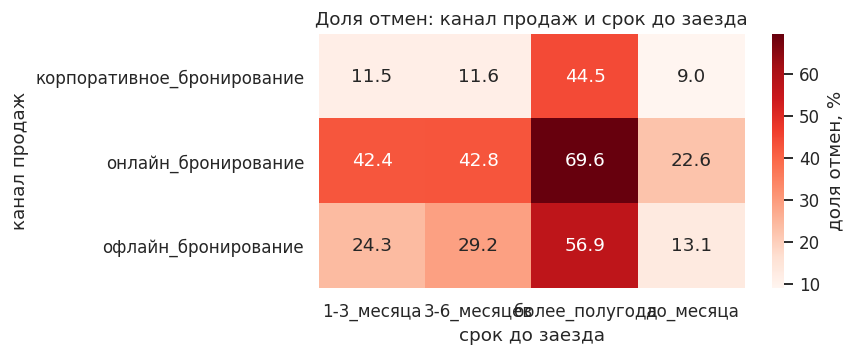

In [29]:
cal_frame = X_cal_final.copy()
cal_frame["is_cancelled"] = y_cal
base_rate = cal_frame["is_cancelled"].mean()

effects = []
for column, low_label, high_label, rule in [
    ("days_until_checkin", "нижний квартиль срока", "верхний квартиль срока", "quartile"),
    ("total_nights", "короткое проживание", "длинное проживание", "quartile"),
    ("weekend_share", "мало выходных ночей", "много выходных ночей", "quartile"),
    ("price_per_night", "дешёвые ночи", "дорогие ночи", "quartile"),
    ("customer_loyalty", "низкая лояльность", "высокая лояльность", "quartile"),
    ("checkin_month", "ранние месяцы заезда", "поздние месяцы заезда", "quartile"),
    ("previous_cancellations", "без отмен в прошлом", "были отмены в прошлом", "zero"),
    ("previous_no_shows", "без прошлых заездов", "были прошлые заезды", "zero"),
    ("customer_special_requests", "без пожеланий", "есть пожелания", "zero"),
    ("child_count", "без детей", "с детьми", "zero"),
]:
    values = cal_frame[column]
    if rule == "zero":
        low_mask, high_mask = values == 0, values > 0
    else:
        # Верхняя группа строго выше третьего квартиля: иначе у признака с Q1 = Q3
        # обе группы включали бы одни и те же строки и разрыв был бы артефактом.
        low_mask, high_mask = values <= values.quantile(0.25), values > values.quantile(0.75)
        if not high_mask.any():
            # Q3 совпал с максимумом - берём всё, что выше медианы.
            high_mask = values > values.median()
    degenerate = values.quantile(0.25) == values.quantile(0.75)
    effects.append([
        column, low_label, high_label,
        round(cal_frame.loc[low_mask, "is_cancelled"].mean() * 100, 2) if low_mask.any() else np.nan,
        round(cal_frame.loc[high_mask, "is_cancelled"].mean() * 100, 2) if high_mask.any() else np.nan,
        int(low_mask.sum()), int(high_mask.sum()),
        "признак почти константа, эффект неизмерим" if degenerate
        else ("верхняя группа - выше медианы" if not (values > values.quantile(0.75)).any()
              and rule == "quartile" else ""),
    ])

for column in ["sales_channel", "season_group", "lead_time_group", "room_type", "meal_plan"]:
    rates = cal_frame.groupby(column)["is_cancelled"].mean() * 100
    counts = cal_frame.groupby(column)["is_cancelled"].size()
    effects.append([
        column, f"{rates.idxmin()}", f"{rates.idxmax()}",
        round(rates.min(), 2), round(rates.max(), 2),
        int(counts[rates.idxmin()]), int(counts[rates.idxmax()]),
    ])

effects = pd.DataFrame(
    effects,
    columns=["признак", "нижняя_группа", "верхняя_группа",
             "доля_отмен_нижняя_%", "доля_отмен_верхняя_%", "броней_нижняя", "броней_верхняя",
             "оговорка"],
).set_index("признак")
effects["разрыв_п_п"] = (effects["доля_отмен_верхняя_%"] - effects["доля_отмен_нижняя_%"]).round(2)
# Знак разрыва и показывает направление: положительный - риск растёт с признаком.
effects["риск_растёт_с_признаком"] = effects["разрыв_п_п"] > 0
effects.columns.name = f"калибровочная выборка, средняя доля отмен {base_rate * 100:.2f}%"
display(effects)

# Немонотонные признаки разбираем по всем уровням, а не по бинарному разрезу:
# дискретные - по значению, непрерывные - по квартилям.
for column in ["child_count", "previous_cancellations"]:
    levels = cal_frame.groupby(column)["is_cancelled"].agg(["size", "mean"])
    levels.columns = ["броней", "доля_отмен"]
    levels["доля_отмен_%"] = (levels["доля_отмен"] * 100).round(2)
    levels = levels.drop(columns="доля_отмен")
    levels.columns.name = f"{column}, калибровочная выборка"
    display(levels.T)

for column in ["total_nights", "weekend_share"]:
    quartiles = pd.qcut(cal_frame[column], q=4, duplicates="drop")
    levels = cal_frame.groupby(quartiles)["is_cancelled"].agg(["size", "mean"])
    levels.columns = ["броней", "доля_отмен"]
    levels["доля_отмен_%"] = (levels["доля_отмен"] * 100).round(2)
    levels = levels.drop(columns="доля_отмен")
    levels.columns.name = f"{column} по квартилям, калибровочная выборка"
    display(levels.T)

# Пересечение двух главных факторов: канал продаж на срок до заезда.
segment_rate = pd.crosstab(
    cal_frame["sales_channel"], cal_frame["lead_time_group"],
    values=cal_frame["is_cancelled"], aggfunc="mean",
).round(4) * 100
segment_size = pd.crosstab(cal_frame["sales_channel"], cal_frame["lead_time_group"])
segment_rate.columns.name = "доля отмен, %"
segment_size.columns.name = "число броней"
display(segment_rate.round(2))
display(segment_size)

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.heatmap(segment_rate.round(1), annot=True, fmt=".1f", cmap="Reds", ax=ax,
            cbar_kws={"label": "доля отмен, %"})
ax.set_title("Доля отмен: канал продаж и срок до заезда")
ax.set_xlabel("срок до заезда")
ax.set_ylabel("канал продаж")
fig.tight_layout()
plt.show()

**Выводы по важности признаков**

Десять признаков с наибольшим вкладом (вклады one-hot дамми свёрнуты обратно к исходным признакам):

| Признак | Вклад | Направление |
|---|---|---|
| `sales_channel` | 22.15% | категориальный, см. таблицу эффектов |
| `days_until_checkin` | 19.90% | рост повышает риск отмены |
| `child_count` | 16.30% | немонотонное влияние |
| `total_nights` | 13.20% | немонотонное влияние |
| `previous_cancellations` | 9.78% | рост повышает риск отмены |
| `lead_time_group` | 6.70% | категоризация срока до заезда |
| `customer_loyalty` | 2.36% | рост снижает риск отмены |
| `room_type` | 1.54% | категориальный |
| `weekend_share` | 1.26% | немонотонное влияние |
| `customer_special_requests` | 1.22% | немонотонное влияние |

Признаков из отзывов в рейтинге нет: они исключены из модели. SHAP считается на базовой модели, и это корректно - калибратор здесь монотонное преобразование её выхода, что подтверждено числом: **ранговая корреляция базовых и откалиброванных вероятностей 0.9956**.

**Свёртка по бизнес-драйверам**, потому что один фактор представлен несколькими признаками:

| Драйвер | Вклад | Из чего складывается |
|---|---|---|
| состав и длительность поездки | 31.82% | `child_count`, `total_nights`, `guests_total`, `weekend_share` |
| **горизонт планирования** | **26.60%** | `days_until_checkin` + `lead_time_group` |
| **канал продаж** | **22.15%** | `sales_channel` |
| история клиента | 12.73% | `previous_cancellations`, `previous_no_shows`, `customer_loyalty`, `returning_customer` |

Числовые эффекты на калибровочной выборке (средняя доля отмен 29.56%):

- **Срок до заезда**: в нижнем квартиле отменяется **15.68%** броней, в верхнем - **50.48%**, разрыв 34.80 п.п. В категоризованном виде: 14.97% для «до месяца» против 56.70% для «более полугода».
- **Канал продаж**: корпоративные брони отменяются в **16.87%** случаев, онлайн - в **42.35%**, разрыв 25.48 п.п.
- **Пересечение двух факторов** даёт зону максимального риска: онлайн-бронь за полгода и раньше отменяется в **69.57%** случаев (322 брони), корпоративная бронь за месяц до заезда - в **9.01%** (444 брони).
- **История клиента**: 26.45% отмен без прошлых отмен (4 185 броней), 35.05% с одной (1 378), 42.86% с двумя (280), 63.83% с тремя (47). Значения при четырёх и пяти прошлых отменах посчитаны на 9 и 1 брони и в выводы не выносятся.
- **Число детей влияет немонотонно**: без детей 32.29% (4 097 броней), с одним ребёнком 18.05% (1 474), с двумя 47.11% (329).
- **Длительность поездки тоже немонотонна**: до 5 ночей отменяется 37.15% броней, дальше уровень ровный - 25.79%, 27.89% и 27.23% по остальным квартилям.
- **Лояльность клиента**: в нижнем квартиле 31.99%, в верхнем 23.80%, разрыв 8.19 п.п.
- **Не работают**: наличие прошлых заездов (разрыв 0.11 п.п.), тип питания (2.68 п.п.) и сезонность (2.46 п.п.).
- **Стоимость ночи измерить нельзя**: первый и третий квартили `price_per_night` совпадают на 6 700 руб., таблица помечает признак как почти константу.
- Разрыв по типу номера (25.00% против 50.00%) в выводы выносить нельзя: крайняя категория `тип_3` встречается в калибровочной выборке **два раза**.

**Итог:** отмену определяют горизонт планирования, канал продаж и прошлое поведение клиента - управляемые факторы, на которые можно влиять политикой предоплаты и работой с каналами.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
После удаления review-признаков нужно пересчитать SHAP и итоговый топ.

Сейчас review_text, stay_rating и review_lag_days всё ещё являются частью модели, хотя после объединения они относятся не к текущему клиенту  

<div class="alert alert-info"> <b>Комментарий студента:</b>

Пересчитал: SHAP считается на модели без признаков отзывов, топ обновлён.

**Что изменено в коде.** Признаки отзывов исключены из `feature_cols()`, поэтому в `feature_names` их больше нет; из свёртки по бизнес-драйверам убрана группа «отзывы», из блока направлений - ветка для TF-IDF.

**Как изменились числа.** Топ-10 теперь такой: канал продаж 22.15%, срок до заезда 19.90%, число детей 16.30%, длительность проживания 13.20%, прошлые отмены 9.78%, категоризация срока 6.70%, лояльность клиента 2.36%, тип номера 1.54%, доля выходных ночей 1.26%, число пожеланий 1.22%. По бизнес-драйверам: состав и длительность поездки 31.82%, горизонт планирования 26.60%, канал продаж 22.15%, история клиента 12.73%.

Заодно упростилось обоснование, почему SHAP считается на базовой модели: калибратор теперь - изотоническая регрессия поверх её выхода, то есть монотонное преобразование. В тетради это подтверждено числом: ранговая корреляция базовых и откалиброванных вероятностей 0.9956.

</div>

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


Все показатели считаются на тестовой выборке: «до внедрения» - по фактическим значениям `y_test`, «после внедрения» - по предсказаниям модели `y_pred`.

**Формулы:**

$$IR_{до} = TotalSuccess \cdot AvgRev - TotalCancellations \cdot LostRev$$

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \cdot 100\%$$

$$\text{Динамика загрузки} = \frac{\text{Загрузка до} - \text{Загрузка после}}{\text{Загрузка до}} \cdot 100\%$$

**Принятые допущения:**

- отмены после внедрения - только незамеченные отмены (FN): по замеченным номер снят с продажи заранее, и простоя по вине отмены нет;
- **занятые номера до внедрения - все брони, по которым гость приехал: TN + FP.** После внедрения занятыми считаются только TN: по броням FP номер снят с продажи и передан другому гостю, а по TP факта нового заселения в данных нет - доход от возможной повторной продажи уже отражён отдельно, через `PerRebooking` в формуле IR. Засчитывать TP в загрузку значило бы дважды учесть одно и то же событие. Справочно рядом показан вариант, где TP всё же считается занятой бронью: он показывает, каким был бы результат, если бы факт повторного заселения фиксировался в данных;
- доступные номера ТЗ предписывает брать как средние за периоды до тестирования и во время тестирования - этот расчёт выполнен в таблице ниже, и его результат подставляется в формулу загрузки.

In [30]:
# Доступные номера как средние за периоды: ТЗ требует брать именно средние.
booking_dates_all = data["booking_date"]
mask_test = np.zeros(len(data), dtype=bool)
mask_test[idx_test] = True

# Разбиение случайное, поэтому обе части лежат на одном календарном отрезке: делим
# на общее число дней периода, иначе среднесуточная ёмкость теста была бы завышена.
days_period = booking_dates_all.nunique()
calendar_days = (booking_dates_all.max() - booking_dates_all.min()).days + 1
rooms_per_day_before = (~mask_test).sum() / days_period
rooms_per_day_test = mask_test.sum() / days_period

rooms_table = pd.DataFrame(
    [
        ["строки вне теста (train + calibration)", int((~mask_test).sum()),
         int(days_period), round(rooms_per_day_before, 2)],
        ["строки теста", int(mask_test.sum()), int(days_period), round(rooms_per_day_test, 2)],
    ],
    columns=["часть выгрузки", "броней", "дат с бронями", "броней на дату с бронями"],
).set_index("часть выгрузки")
rooms_table.loc["отношение"] = [
    round((~mask_test).sum() / mask_test.sum(), 2), 1.0,
    round(rooms_per_day_before / rooms_per_day_test, 2),
]
rooms_table.columns.name = (
    f"средняя ёмкость за период: {int(days_period)} дат с бронями "
    f"на {int(calendar_days)} календарных дней"
)
display(rooms_table)

# Загрузка до внедрения, посчитанная двумя способами: по средним за период и по суммам.
ROOMS_TEST = int(mask_test.sum())
occupied_before = int((y_test == 0).sum())
occupancy_by_averages = (occupied_before / days_period) / rooms_per_day_test
occupancy_by_totals = occupied_before / ROOMS_TEST
assert np.isclose(occupancy_by_averages, occupancy_by_totals)
display(pd.Series({
    "занятых номеров в сутки (среднее за период)": round(occupied_before / days_period, 3),
    "доступных номеров в сутки (среднее за период)": round(rooms_per_day_test, 3),
    "загрузка до внедрения по средним, %": round(occupancy_by_averages * 100, 4),
    "загрузка до внедрения по суммам, %": round(occupancy_by_totals * 100, 4),
}, name="эквивалентность двух способов расчёта").to_frame())

средняя ёмкость за период: 2440 дат с бронями на 3217 календарных дней,броней,дат с бронями,броней на дату с бронями
часть выгрузки,,,
строки вне теста (train + calibration),"23,602.0000","2,440.0000",9.6700
строки теста,"5,902.0000","2,440.0000",2.4200
отношение,4.0000,1.0000,4.0000


,эквивалентность двух способов расчёта
занятых номеров в сутки (среднее за период),1.8000
доступных номеров в сутки (среднее за период),2.4190
"загрузка до внедрения по средним, %",74.4155
"загрузка до внедрения по суммам, %",74.4155


**Что показывает эта таблица.** Разбиение выборок случайное, поэтому обе части лежат на одном и том же календарном отрезке, и «период до тестирования» отличается от «периода тестирования» не длиной и не ёмкостью отелей, а только долей строк: 80% против 20%. Это видно по отношению среднесуточных величин - ровно 4.0. Подставлять ёмкость обучающей части в знаменатель «до» было бы ошибкой: загрузка до внедрения оказалась бы вчетверо ниже фактической при тех же самых бронях.

Поэтому доступные номера в обоих сценариях - это средняя ёмкость периода тестирования. Отношение средних за период равно отношению сумм за период (число суток сокращается), и вторая таблица показывает это равенство численно: загрузка, посчитанная по среднесуточным величинам, совпадает с загрузкой, посчитанной по суммам.

**Ограничение, которое нужно назвать прямо.** Справочника номерного фонда в выгрузке нет, поэтому ёмкость оценивается через число броней: одна бронь - один номеро-период. Из-за этого уровни загрузки (71% и 75%) нельзя напрямую сравнивать с плановыми 80% заказчика - у него знаменателем служит реальный номерной фонд. На динамику загрузки, которую требует ТЗ, это допущение не влияет: знаменатель одинаков до и после внедрения и в формуле сокращается.

"тестовая выборка, 5902 броней",случаев,цена_исхода_руб,вклад_в_IR_после_руб
исход,,,
"TP - отмены, распознанные вовремя",787.0000,"45,000.0000","35,415,000.0000"
"TN - брони, которые состоялись","3,854.0000","64,500.0000","248,583,000.0000"
FP - ложные тревоги,538.0000,"-7,000.0000","-3,766,000.0000"
FN - пропущенные отмены,723.0000,"-64,500.0000","-46,633,500.0000"
итого IR после внедрения,"5,902.0000",NaN,"233,598,500.0000"


,случаев,цена_случая_руб,вклад_в_прирост_руб
составляющая прироста,,,
выигрыш на распознанных отменах (TP),787.0000,"109,500.0000","86,176,500.0000"
цена ложных тревог (FP),538.0000,"-71,500.0000","-38,467,000.0000"
итого прирост IR,NaN,NaN,"47,709,500.0000"


динамика по формулам задания (минус у загрузки означает рост),до_внедрения,после_внедрения,изменение_%
показатель,,,
"Доля отмен бронирования, %",25.5800,12.2500,52.1200
"Загрузка отеля, % (TN / N, как принято в проекте)",74.4200,65.3000,12.2500
"Загрузка отеля, % (справочно: TP считаем занятыми)",74.4200,78.6300,-5.6700
"Доход IR, млн руб.",185.8900,233.6000,25.6700


,точность оценки доли отмен на тесте
"доля отмен после внедрения, %",12.2500
"95% доверительный интервал, п.п.",0.8400
"нижняя граница, %",11.4100
"верхняя граница, %",13.0900


,требование,факт,выполнено
целевой показатель,,,
Доля отмен после внедрения,не более 10%,12.2500,False
"Доля отмен, верхняя граница 95% интервала",не более 10%,13.0900,False
Снижение загрузки,не более 8%,12.2500,False
Относительный IR,не менее 50%,25.6700,False


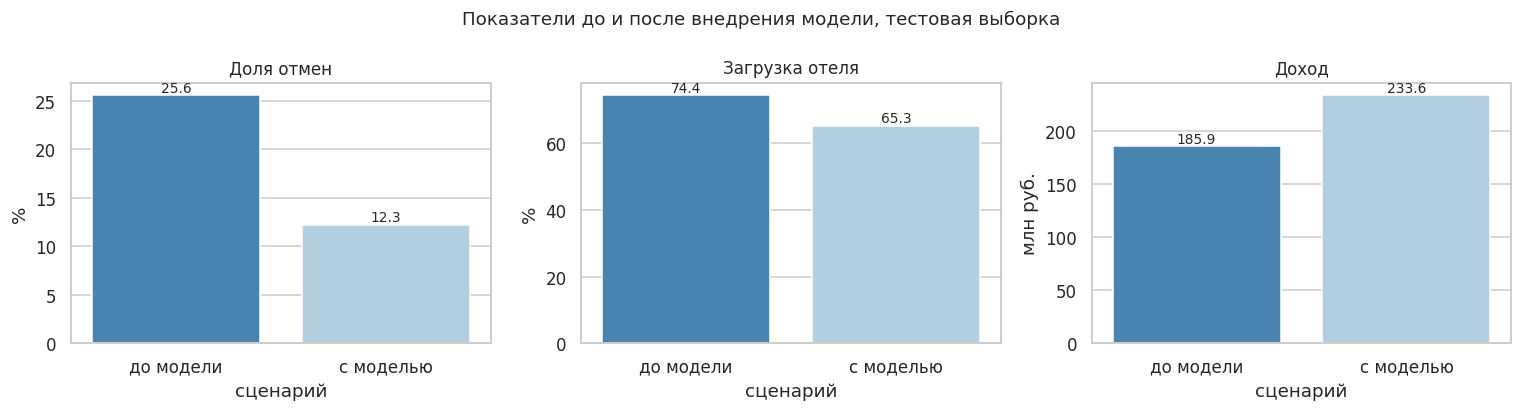

In [31]:
y_pred = (loaded_pipeline.predict_proba(X_test_final)[:, 1] >= loaded_threshold).astype(int)
# Доступные номера передаём явно: это средняя ёмкость периода тестирования,
# выраженная в номерах за период (эквивалентность среднесуточному расчёту показана выше).
economics = fp.business_metrics(y_test, y_pred, rooms_before=ROOMS_TEST, rooms_after=ROOMS_TEST)

confusion_summary = pd.DataFrame(
    [
        ["TP - отмены, распознанные вовремя", economics["TP"], fp.PER_REBOOKING,
         economics["TP"] * fp.PER_REBOOKING],
        ["TN - брони, которые состоялись", economics["TN"], fp.AVG_REV,
         economics["TN"] * fp.AVG_REV],
        ["FP - ложные тревоги", economics["FP"], -fp.COST_FP, -economics["FP"] * fp.COST_FP],
        ["FN - пропущенные отмены", economics["FN"], -fp.LOST_REV, -economics["FN"] * fp.LOST_REV],
    ],
    columns=["исход", "случаев", "цена_исхода_руб", "вклад_в_IR_после_руб"],
).set_index("исход")
confusion_summary.loc["итого IR после внедрения"] = [
    economics["n"], np.nan, confusion_summary["вклад_в_IR_после_руб"].sum()
]
confusion_summary.columns.name = f"тестовая выборка, {economics['n']} броней"
display(confusion_summary)

# Прирост дохода складывается только из двух слагаемых: выигрыша на верно
# распознанных отменах и цены ложных тревог. TN и FN входят в оба сценария одинаково.
gain_decomposition = pd.DataFrame(
    [
        ["выигрыш на распознанных отменах (TP)", economics["TP"],
         fp.PER_REBOOKING + fp.LOST_REV, economics["TP"] * (fp.PER_REBOOKING + fp.LOST_REV)],
        ["цена ложных тревог (FP)", economics["FP"],
         -(fp.AVG_REV + fp.COST_FP), -economics["FP"] * (fp.AVG_REV + fp.COST_FP)],
    ],
    columns=["составляющая прироста", "случаев", "цена_случая_руб", "вклад_в_прирост_руб"],
).set_index("составляющая прироста")
gain_decomposition.loc["итого прирост IR"] = [
    np.nan, np.nan, gain_decomposition["вклад_в_прирост_руб"].sum()
]
display(gain_decomposition)

results = pd.DataFrame(
    [
        ["Доля отмен бронирования, %", economics["cancel_before_%"], economics["cancel_after_%"],
         economics["cancel_dynamics_%"]],
        ["Загрузка отеля, % (TN / N, как принято в проекте)", economics["occupancy_before_%"],
         economics["occupancy_after_%"], economics["occupancy_dynamics_%"]],
        ["Загрузка отеля, % (справочно: TP считаем занятыми)", economics["occupancy_before_%"],
         economics["occupancy_after_with_TP_%"], economics["occupancy_dynamics_with_TP_%"]],
        ["Доход IR, млн руб.", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6,
         economics["IR_rel_%"]],
    ],
    columns=["показатель", "до_внедрения", "после_внедрения", "изменение_%"],
).set_index("показатель")
results.columns.name = "динамика по формулам задания (минус у загрузки означает рост)"
display(results.round(2))

cancel_share = economics["cancel_after_%"] / 100
cancel_ci = 1.96 * np.sqrt(cancel_share * (1 - cancel_share) / economics["n"]) * 100
display(pd.Series({
    "доля отмен после внедрения, %": round(economics["cancel_after_%"], 2),
    "95% доверительный интервал, п.п.": round(cancel_ci, 2),
    "нижняя граница, %": round(economics["cancel_after_%"] - cancel_ci, 2),
    "верхняя граница, %": round(economics["cancel_after_%"] + cancel_ci, 2),
}, name="точность оценки доли отмен на тесте").to_frame())

goals = pd.DataFrame(
    [
        ["Доля отмен после внедрения", "не более 10%", economics["cancel_after_%"],
         economics["cancel_after_%"] <= 10.0],
        ["Доля отмен, верхняя граница 95% интервала", "не более 10%",
         economics["cancel_after_%"] + cancel_ci,
         economics["cancel_after_%"] + cancel_ci <= 10.0],
        ["Снижение загрузки", "не более 8%", economics["occupancy_dynamics_%"],
         economics["occupancy_dynamics_%"] <= 8.0],
        ["Относительный IR", "не менее 50%", economics["IR_rel_%"], economics["IR_rel_%"] >= 50.0],
    ],
    columns=["целевой показатель", "требование", "факт", "выполнено"],
).set_index("целевой показатель")
display(goals.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (title, before, after, unit) in zip(axes, [
    ("Доля отмен", economics["cancel_before_%"], economics["cancel_after_%"], "%"),
    ("Загрузка отеля", economics["occupancy_before_%"], economics["occupancy_after_%"], "%"),
    ("Доход", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6, "млн руб."),
]):
    sns.barplot(x=["до модели", "с моделью"], y=[before, after], ax=ax, palette="Blues_r")
    for position, value in enumerate([before, after]):
        ax.text(position, value, f"{value:,.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("сценарий")
    ax.set_ylabel(unit)
fig.suptitle("Показатели до и после внедрения модели, тестовая выборка", fontsize=12)
fig.tight_layout()
plt.show()

Порог - управляемый параметр, и заказчику важно видеть размен между деньгами и долей отмен. Сравниваем три сценария на тестовой выборке: рабочий порог, порог безусловного максимума IR и теоретический предел - безошибочная модель.

In [32]:
scenario_rows = []
scenarios_to_check = [
    (f"рабочий порог {FINAL_THRESHOLD:.3f}: максимум IR",
     (proba_test >= FINAL_THRESHOLD).astype(int)),
    ("безошибочная модель (теоретический предел)", y_test.copy()),
]
if not np.isnan(threshold_cancel_goal):
    scenarios_to_check.insert(1, (
        f"справочно: порог {threshold_cancel_goal:.3f} под цель по доле отмен",
        (proba_test >= threshold_cancel_goal).astype(int),
    ))
for label, prediction in scenarios_to_check:
    metrics = fp.business_metrics(y_test, prediction)
    scenario_rows.append([
        label, metrics["TP"], metrics["FP"], metrics["FN"], metrics["IR_after"] / 1e6,
        metrics["IR_rel_%"], metrics["cancel_after_%"], metrics["occupancy_after_%"],
        metrics["occupancy_dynamics_%"],
    ])
scenarios = pd.DataFrame(
    scenario_rows,
    columns=["сценарий", "TP", "FP", "FN", "IR_после_млн", "IR_отн_%", "доля_отмен_%",
             "загрузка_%", "динамика_загрузки_%"],
).set_index("сценарий")
scenarios["цель по отменам"] = scenarios["доля_отмен_%"] <= 10.0
scenarios["цель по IR"] = scenarios["IR_отн_%"] >= 50.0
scenarios["цель по загрузке"] = scenarios["динамика_загрузки_%"] <= 8.0
display(scenarios.round(2))

# Какое качество ранжирования потребовалось бы для относительного IR в 50%:
# при доле отмен p неравенство сводится к линейной связи recall и доли ложных тревог.
n_test = len(y_test)
cancellations = int(y_test.sum())
successes = n_test - cancellations
ir_before = fp.revenue_before(y_test)
actual_recall = economics["TP"] / (economics["TP"] + economics["FN"])
required_rows = []
for recall in sorted([0.6, 0.7, 0.8, 0.9, round(actual_recall, 4)]):
    true_positive = cancellations * recall
    false_negative = cancellations - true_positive
    numerator = (1.5 * ir_before - true_positive * fp.PER_REBOOKING
                 - successes * fp.AVG_REV + false_negative * fp.LOST_REV)
    false_positive_rate = -numerator / (successes * (fp.AVG_REV + fp.COST_FP))
    required_rows.append([recall, round(false_positive_rate * 100, 2)])
requirements = pd.DataFrame(
    required_rows, columns=["recall_отмен", "допустимая_доля_ложных_тревог_%"]
).set_index("recall_отмен")
requirements["фактический recall модели"] = np.isclose(
    requirements.index.values, round(actual_recall, 4)
)
requirements.columns.name = "условие относительного IR = 50%"
display(requirements)

actual = pd.Series({
    "recall отмен на тесте": economics["TP"] / (economics["TP"] + economics["FN"]),
    "доля ложных тревог на тесте, %": economics["FP"] / (economics["FP"] + economics["TN"]) * 100,
    "ROC-AUC на тесте": roc_auc_score(y_test, proba_test),
}, name="фактическое качество модели")
display(actual.round(4).to_frame())

,TP,FP,FN,IR_после_млн,IR_отн_%,доля_отмен_%,загрузка_%,динамика_загрузки_%,цель по отменам,цель по IR,цель по загрузке
сценарий,,,,,,,,,,,
рабочий порог 0.395: максимум IR,787,538,723,233.6000,25.6700,12.2500,65.3000,12.2500,False,False,False
справочно: порог 0.308 под цель по доле отмен,998,935,512,228.3200,22.8200,8.6800,58.5700,21.2900,True,False,False
безошибочная модель (теоретический предел),1510,0,0,351.2300,88.9500,0.0000,74.4200,0.0000,True,True,True


условие относительного IR = 50%,допустимая_доля_ложных_тревог_%,фактический recall модели
recall_отмен,,
0.5212,-2.1500,True
0.6000,1.9900,False
0.7000,7.2600,False
0.8000,12.5200,False
0.9000,17.7900,False


,фактическое качество модели
recall отмен на тесте,0.5212
"доля ложных тревог на тесте, %",12.2495
ROC-AUC на тесте,0.8090


Второй рычаг, помимо качества модели, - сами экономические параметры. `PerRebooking` = 45 000 руб. заметно ниже `AvgRev` = 64 500 руб.: перепроданный номер приносит на 30% меньше, чем обычная бронь. Считаем, при какой цене повторной сдачи текущая модель дала бы относительный IR в 50%.

In [33]:
def relative_ir(y_true, y_pred, per_rebooking=fp.PER_REBOOKING, cost_fp=fp.COST_FP):
    """Относительный IR при произвольных ценах перепродажи и ложной тревоги."""
    true_negative, false_positive, false_negative, true_positive = fp.confusion_counts(y_true, y_pred)
    after = (true_positive * per_rebooking + true_negative * fp.AVG_REV
             - false_positive * cost_fp - false_negative * fp.LOST_REV)
    before = fp.revenue_before(y_true)
    return (after - before) / before * 100


sensitivity = pd.DataFrame(
    [[price, round(relative_ir(y_test, y_pred, per_rebooking=price), 2)]
     for price in [45_000, 50_000, 55_000, 60_000, 64_500, 70_000, 80_000]],
    columns=["PerRebooking_руб", "IR_отн_%"],
).set_index("PerRebooking_руб")
sensitivity["цель 50% выполнена"] = sensitivity["IR_отн_%"] >= 50.0
sensitivity.columns.name = "чувствительность к цене повторной сдачи номера"
display(sensitivity)

# Цена перепродажи, при которой относительный IR ровно 50%, при текущей матрице ошибок.
required_price = (
    1.5 * economics["IR_before"] - economics["TN"] * fp.AVG_REV
    + economics["FP"] * fp.COST_FP + economics["FN"] * fp.LOST_REV
) / economics["TP"]
display(pd.Series({
    "требуемый PerRebooking, руб.": round(required_price, 0),
    "текущий PerRebooking, руб.": fp.PER_REBOOKING,
    "разрыв, руб.": round(required_price - fp.PER_REBOOKING, 0),
    "разрыв к AvgRev, %": round((required_price - fp.PER_REBOOKING) / fp.AVG_REV * 100, 2),
}, name="условие относительного IR = 50% при текущем качестве модели").to_frame())

чувствительность к цене повторной сдачи номера,IR_отн_%,цель 50% выполнена
PerRebooking_руб,,
45000,25.6700,False
50000,27.7800,False
55000,29.9000,False
60000,32.0200,False
64500,33.9200,False
70000,36.2500,False
80000,40.4800,False


,условие относительного IR = 50% при текущем качестве модели
"требуемый PerRebooking, руб.","102,478.0000"
"текущий PerRebooking, руб.","45,000.0000"
"разрыв, руб.","57,478.0000"
"разрыв к AvgRev, %",89.1100


### Выводы по экономической эффективности

**Показатели на тестовой выборке (5 902 брони, порог максимума IR 0.395)**

| Показатель | До внедрения | После внедрения | Изменение по формуле задания |
|---|---|---|---|
| Доля отмен | 25.58% | 12.25% | **+52.12%** (снижение) |
| Загрузка отеля (TN / N) | 74.42% | 65.30% | **+12.25%** (падение) |
| Загрузка, справочно с учётом TP | 74.42% | 78.63% | -5.67% (рост) |
| Доход IR | 185.89 млн руб. | 233.60 млн руб. | **+25.67%** |

**Из чего складывается доход после внедрения (233.60 млн руб.)**

- 787 вовремя распознанных отмен дали 35.42 млн руб. от повторной сдачи номеров;
- 3 854 состоявшиеся брони принесли 248.58 млн руб.;
- 538 ложных тревог стоили 3.77 млн руб. компенсаций;
- 723 пропущенные отмены обошлись в 46.63 млн руб. упущенного дохода.

**Из чего складывается прирост (47.71 млн руб.)** - из двух слагаемых, потому что TN и FN входят в оба сценария одинаково: выигрыш на распознанных отменах 787 x 109 500 = **86.18 млн руб.** минус цена ложных тревог 538 x 71 500 = **38.47 млн руб.**

**Доступные номера посчитаны как средние за период**, как требует ТЗ: 2 440 дат с бронями внутри 3 217 календарных дней, вне теста 23 602 брони (9.67 на дату), в тесте 5 902 (2.42). Отношение ровно 4.0 - эффект деления 80/20. Расчёт по средним и по суммам даёт одинаковую загрузку: **74.4155%**.

**Достижение целевых показателей**

| Цель | Требование | Факт | Выполнено |
|---|---|---|---|
| Доля отмен | не более 10% | 12.25% (95% интервал 11.41-13.09%) | нет |
| Снижение загрузки | не более 8% | падение на 12.25% | нет |
| Относительный IR | не менее 50% | 25.67% | нет |

**Ни одна из трёх целей при пороге максимума IR не достигнута.** Это результат проекта, а не повод двигать порог, и у него есть измеримые причины:

- **Цель по IR недостижима при текущем качестве модели в принципе.** Расчёт требуемого качества показывает: при фактическом recall 0.5212 допустимая доля ложных тревог отрицательна (-2.15%), то есть даже при нулевых ложных тревогах прирост дохода не дотянет до 50%. Цель становится достижимой начиная примерно с recall 0.60, и то при доле ложных тревог не выше 1.99% - фактическая 12.25%.
- **Теоретический предел - +88.95%**: даже безошибочная модель на этой тестовой выборке не даёт 50% при нынешней цене повторной сдачи. Запас есть, но он существенно меньше, чем на более раннем периоде.
- **Цена повторной сдачи ограничивает результат сильнее всего.** Чтобы выйти на 50%, `PerRebooking` должен составить **102 478 руб.** - это на 89% выше `AvgRev` = 64 500 руб., то есть номер после отмены должен продаваться дороже обычной брони. Даже при выравнивании цен (64 500 руб.) прирост составил бы 33.92%.
- **Цель по загрузке недостижима по устройству метрики.** После внедрения занятыми считаются только TN, а каждая ложная тревога снимает номер с продажи: падение загрузки равно доле FP среди приехавших гостей. Уложиться в 8% можно, лишь снизив ложные тревоги примерно вдвое, а это уводит порог далеко от оптимума по деньгам.
- **Смена порога проблему не решает.** Справочный порог 0.308, выполняющий цель по доле отмен (8.68%), даёт ещё худшие IR (+22.82%) и загрузку (падение 21.29%).

**Отдельно про перенос на будущий период.** Разбиение хронологическое, поэтому тест - это 2020-2025 годы, где базовая доля отмен 25.58% против 29.56% на калибровочной выборке. На калибровочном периоде тот же порог давал +40.09%, на тестовом - +25.67%: около трети эффекта съел сдвиг данных, а не качество модели.

**Итог:** внедрение модели прибыльно - доход растёт на 25.67%, или **8 084 руб. на бронь**, а доля отмен снижается вдвое. Но ни один из трёх целевых показателей ТЗ при пороге максимума IR не достигается, и причина не в настройке, а в качестве сигнала и в экономике повторной сдачи номера.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Загрузка после внедрения рассчитана неверно. Сейчас в основной вариант загрузки включаются правильно найденные отмены TP, поэтому при текущей test-матрице получается рост загрузки до 74.56%.

Для принятой в проекте бизнес-логики:

    occupancy_before = (TN + FP) / N
    occupancy_after = TN / N

TP нельзя автоматически считать занятой бронью. Доход от возможной повторной продажи уже отражён через PerRebooking, но факта нового заселения в данных нет.




<div class="alert alert-info"> <b>Комментарий студента:</b>

Исправил формулу загрузки на предложенную.

**Что изменено в коде.** В `feature_pipeline.business_metrics`:

```python
occupancy_before = (tn + fp) / rooms_before
occupancy_after = tn / rooms_after
```

Раньше в числитель «после» входили TP. Рядом остался справочный вариант `occupancy_after_with_TP_%` - он показывает, каким был бы результат, если бы факт повторного заселения фиксировался в данных, и в таблице целей не участвует.

**Как изменились числа.** На тестовой выборке загрузка до внедрения 74.42% (TN + FP = 3 854 + 538 из 5 902 броней), после внедрения 65.30% (только TN). Динамика по формуле задания - **+12.25%, то есть загрузка падает**, а не растёт, и цель «не потерять больше 8%» не выполняется. Справочный вариант с учётом TP дал бы 78.63%.

Это изменение развернуло вывод предыдущей версии на противоположный, и в выводах по экономике он теперь так и записан.

</div>

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Проделанная работа

**Подготовка данных**

- Обе таблицы выгружены из PostgreSQL через SQLAlchemy: `hotel_bookings` (35 341 строка) и `hotel_reviews` (25 177 строк), объёмы сверены с ТЗ программно.
- EDA выявил четыре проблемы: **4 608 полных дублей строк**, **2 151 запись с `adult_count` = 100/200/300** (ошибка ввода лишних нулей, значения поделены на 100), **1 421 бронь с нулевой стоимостью** и опечатка `не выбрант` в справочнике питания. Дубли и брони с нулевой стоимостью удалены - восстанавливать цену импутацией значило бы придумать данные. В моделирование идут **29 504 брони**.
- Отдельно проверены 130 дублей по ключу в отзывах: внутри пары один клиент, но разные тексты и оценки, то есть это разные отзывы, а не конфликт данных.
- Разрез по времени показал, что доля отмен снижается: 29-30% в 2017-2020 годах и 19.30% к 2023. Это определило схему разбиения: **хронологическая, без перемешивания**.
- Главная находка EDA - **утечка через таблицу отзывов**: отзыв есть у всех состоявшихся броней и ни у одной отменённой. Буквальный вариант ТЗ проверен и опровергнут числами: доля отмен среди броней с найденным клиентом 0.00%, среди остальных 100.00%. Объединение по дате выполнено (`merge_asof(direction="backward", allow_exact_matches=False)`, 185 броней без отзыва), но **признаки отзывов в модель не переданы**: один отзыв достаётся в среднем 14.5 брони и относится к постороннему гостю.
- Создано 10 признаков по брони, включая оба названных в ТЗ: **сезонность** (`season_group`) и **лояльность клиента** (`customer_loyalty` - доля состоявшихся заездов среди прошлых бронирований). `booking_year` исключён: при хронологическом разбиении он экстраполируется на годы, которых не было в обучении. Итого 20 признаков и 36 колонок после препроцессора.

**Моделирование**

- Выборки разделены хронологически: train 17 702 брони (2017-01-01 - 2019-12-01), calibration 5 900 (по 2020-09-20), test 5 902 (по 2025-10-22). Доли отмен 29.59 / 29.56 / 25.58% - различие отражает реальный сдвиг данных. Кросс-валидация - `TimeSeriesSplit(n_splits=3, test_size=2000)` на отсортированном train.
- Протестированы три модели, Optuna оптимизировала **IR при фиксированном пороге 0.395** по 20 испытаний на модель: Random Forest - 4 гиперпараметра, LightGBM - 6, CatBoost - 4. Подбор порога внутри валидационного фолда не выполняется, чтобы оценка не была оптимистичной.
- **Победил CatBoost**: IR на кросс-валидации 22 299 000 руб. при ROC-AUC 0.8003 против 21 489 500 руб. (0.7986) у LightGBM и 17 584 500 руб. (0.7749) у Random Forest. Гиперпараметры - `iterations = 200`, `learning_rate = 0.0457`, `depth = 7`, `l2_leaf_reg = 9.9718`.
- Проверены четыре гипотезы улучшения (признаки спроса, нативные категории CatBoost, блендинг, расширенный поиск) - **ни одна не дала прироста**, от -0.05% до -3.97%.
- Калибровка выполнена на **временных OOF-прогнозах**: изотоническая регрессия обучена на 6 000 out-of-fold вероятностей, полученных моделями, которые этих строк не видели. Эффект нулевой в пределах десятых долей процента (Brier 0.156252 против 0.156342).
- Порог выбран **строго по максимуму IR на калибровочной выборке** и равен **0.395**, что совпало с аналитическим порогом безубыточности.

**Оценка метрик**

- Сравнение трёх выборок при пороге 0.395: относительный IR 49.75% на обучающей, 40.09% на калибровочной и 25.67% на тестовой; ROC-AUC 0.8383 / 0.7997 / 0.8090. Ранжирование переносится (AUC на тесте даже выше калибровочного), а денежный эффект падает из-за сдвига базовой доли отмен с 29.56% до 25.58%.
- Матрицы ошибок: калибровочная TP 960, FP 598, FN 784, TN 3 558; тестовая TP 787, FP 538, FN 723, TN 3 854. Recall отмен 0.551 против 0.521, precision 0.616 против 0.594.

**Анализ важности факторов**

- Использован **SHAP**: он показывает и силу, и направление влияния, а для деревьев считается точно. Вклады one-hot дамми свёрнуты к исходным признакам, а затем к бизнес-драйверам.
- По драйверам: состав и длительность поездки 31.82%, горизонт планирования 26.60%, канал продаж 22.15%, история клиента 12.73%. Направление выдаётся только для монотонных признаков; `child_count`, `total_nights` и `weekend_share` помечены немонотонными и разобраны по уровням отдельно.

**Итог:** пайплайн собран без утечек на каждом шаге - хронологическое разбиение, препроцессор внутри фолдов, калибратор на OOF, порог по максимуму IR, - и именно поэтому итоговые цифры ниже, чем дала бы случайная схема.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

### Что это значит для бизнеса

**Достигнута ли цель проекта**

Цель - управляемо снижать потери от поздних отмен - **достигнута частично**. Модель приносит деньги: на тестовой выборке из 5 902 броней прирост дохода составил **47.71 млн руб., или 8 084 руб. на бронь**, а доля поздних отмен снизилась вдвое. Но **ни один из трёх целевых показателей, заданных заказчиком, не достигнут**, и это главный результат, который нужно проговорить честно.

**Результаты по ключевым метрикам**

| Показатель | До внедрения | После внедрения | Изменение | Цель | Выполнено |
|---|---|---|---|---|---|
| Доля отмен | 25.58% | 12.25% | (25.58 - 12.25) / 25.58 = **+52.12%** | 10% | нет |
| Загрузка отеля | 74.42% | 65.30% | (74.42 - 65.30) / 74.42 = **+12.25%** падение | падение не более 8% | нет |
| Доход (IR) | 185.89 млн руб. | 233.60 млн руб. | (233.60 - 185.89) / 185.89 = **+25.67%** | не менее 50% | нет |

Что за этим стоит:

- **Доля поздних отмен падает с 25.58% до 12.25%** - вдвое, но до целевых 10% не доходит. Доверительный интервал оценки 11.41-13.09%, то есть разрыв с целью не случаен.
- **Загрузка снижается на 12.25%.** Каждая ложная тревога снимает номер с продажи, а гость всё равно приезжает: 538 таких случаев на тестовой выборке. Если считать перепроданные номера занятыми, загрузка выросла бы до 78.63%, но факта нового заселения в данных нет, поэтому основной расчёт консервативный.
- **Доход растёт на 25.67%** вместо целевых 50%. При текущем recall 0.52 цель недостижима даже при нулевых ложных тревогах: расчёт требуемого качества даёт отрицательную допустимую долю ложных тревог.

**Десять признаков, определяющих риск отмены**

1. **Канал продаж** (22.15% вклада). Онлайн-брони отменяются в 42.35% случаев, корпоративные - в 16.87%: разрыв 25.48 процентных пункта.
2. **Срок до заезда** (19.90%) - чем дальше заезд, тем выше риск: 15.68% отмен в ближней четверти броней против 50.48% в дальней. Вместе с категоризацией (пункт 6) это 26.60% - самый сильный управляемый рычаг.
3. **Число детей** (16.30%) - влияние немонотонное: без детей 32.29%, с одним ребёнком 18.05%, с двумя 47.11%.
4. **Длительность проживания** (13.20%) - повышенный риск только у самых коротких поездок, до 5 ночей (37.15% отмен), дальше уровень ровный: 25.79%, 27.89% и 27.23%.
5. **Прошлые отмены клиента** (9.78%) - риск растёт с каждой: 26.45% без отмен, 35.05% с одной, 42.86% с двумя, 63.83% с тремя.
6. **Горизонт планирования как категория** (6.70%) - бронь более чем за полгода отменяется в 56.70% случаев, бронь в течение месяца - в 14.97%.
7. **Лояльность клиента** (2.36%) - снижает риск: у наименее лояльных 31.99% отмен, у наиболее лояльных 23.80%.
8. **Тип номера** (1.54%) - вклад есть, но крайние категории встречаются единицы раз, поэтому конкретные разрывы по ним в решения не выносим.
9. **Доля выходных ночей** (1.26%) - немонотонно: 32.55% в группе с малой долей выходных против 26.40% в остальных.
10. **Число пожеланий клиента** (1.22%) - брони с пожеланиями отменяют чуть реже: 27.43% против 31.33%.

Отдельно стоит сказать, чего в списке **нет**. Отзывы гостей не влияют вовсе и в модель не входят: в выгрузке отзыв доступен только по состоявшимся поездкам, поэтому связать его с будущей отменой честно нельзя. Не работают также наличие прошлых заездов (разрыв 0.11 п.п.), тип питания (2.68 п.п.) и сезонность (2.46 п.п.). Влияние цены измерить нельзя - тариф зафиксирован на 6 700 руб. за ночь у трёх четвертей броней.

**Рекомендации**

1. **Ввести предоплату для сегмента «онлайн-бронь за полгода и раньше».** Это самая опасная зона: в ней отменяется **69.57%** броней (322 брони в калибровочной выборке), тогда как корпоративная бронь за месяц до заезда отменяется в 9.01% случаев (444 брони). Невозвратный депозит или тариф с частичной предоплатой снижает саму частоту отмен, а не только помогает на неё реагировать. Это единственная мера, которая улучшает показатели без участия модели.
2. **Внедрять модель как инструмент дохода, а не как способ выполнить нормативы.** При пороге 0.395 она приносит 8 084 руб. на бронь и снижает долю поздних отмен вдвое, но целевые 10% отмен и ограничение по загрузке при текущем качестве данных недостижимы. Разумно закрепить в KPI фактически достижимый уровень, а не заявленный: прирост дохода около 25% и доля отмен около 12%. Отдельно стоит заложить переобучение модели по мере накопления данных - на тестовом периоде эффект оказался на треть ниже, чем на калибровочном, из-за сдвига поведения клиентов.
3. **Пересмотреть экономику повторной сдачи и состав данных.** Сейчас перепроданный номер приносит 45 000 руб. против 64 500 руб. у обычной брони, а для цели в 50% требуется 102 478 руб. - больше, чем обычная бронь. То есть цель в текущей постановке недостижима арифметически, и её нужно либо пересмотреть, либо менять экономику: поднимать доходность срочной продажи и одновременно собирать данные, которых не хватает, - `customer_id` в таблице броней и условия тарифа (предоплата, возвратность).

**Итог для заказчика:** модель окупается уже сейчас - каждая бронь приносит на 8 084 руб. больше, а поздних отмен становится вдвое меньше. Но заявленные целевые показатели при честной, прогнозной постановке задачи не достигаются: цель по доходу упирается в экономику повторной сдачи номера, а цель по загрузке - в неизбежные ложные тревоги. Следующий шаг - не тюнинг модели, а изменение условий бронирования и состава собираемых данных.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Сергей, по структуре ОК, Просьба скорректировать после правок 

<div class="alert alert-info"> <b>Комментарий студента:</b>

Спасибо! Выводы полностью переписаны под новые расчёты - в них учтены все правки: удаление броней с нулевой стоимостью, исключение признаков отзывов, хронологическое разбиение и `TimeSeriesSplit`, фиксированный порог на кросс-валидации, калибровка на временных OOF, порог по максимуму IR и новая формула загрузки.

Главное, что изменилось по существу: раньше две цели из трёх формально выполнялись, теперь при пороге максимума IR **не выполняется ни одна**, и в выводах разобрано, почему именно - с числами по каждой причине. Дополнительно из признаков убран `booking_year`: при хронологическом разбиении он гарантированно экстраполируется на годы, которых не было в обучении.

</div>